In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#<font face="Georgia" color="#D8B4FE" size="6.9">Dataset Generation</font>

In [ ]:
# @title
# Generate the full invoice dataset into isolated -v2 folders with collision-safe modern headers.
import os,json,hashlib,textwrap,random
from pathlib import Path
from PIL import Image,ImageDraw,ImageFont

BASE_DIR=Path("/content/drive/MyDrive/Invoice_Dataset")
JSON_DIR=BASE_DIR/"json"
UPDATE_DIR=BASE_DIR/"Dataset_Update-v2"
OUTPUT_DIR=UPDATE_DIR/"images_update-v2"
PREVIEW_DIR=UPDATE_DIR/"template_previews_update-v2"
METADATA_FILE=UPDATE_DIR/"template_metadata_update-v2.json"

UPDATE_DIR.mkdir(parents=True,exist_ok=True)
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
PREVIEW_DIR.mkdir(parents=True,exist_ok=True)

LIMIT=10000
TOTAL_TEMPLATES=20
PAGE_W=1200
PAGE_H=1600

FONT_REGULAR_PATH="/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
FONT_BOLD_PATH="/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"

if not os.path.exists(FONT_REGULAR_PATH):
    FONT_REGULAR_PATH="/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf"
if not os.path.exists(FONT_BOLD_PATH):
    FONT_BOLD_PATH="/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf"

font_small=ImageFont.truetype(FONT_REGULAR_PATH,21)
font_normal=ImageFont.truetype(FONT_REGULAR_PATH,23)
font_medium=ImageFont.truetype(FONT_BOLD_PATH,28)
font_bold=ImageFont.truetype(FONT_BOLD_PATH,34)
font_title=ImageFont.truetype(FONT_BOLD_PATH,51)
font_company=ImageFont.truetype(FONT_BOLD_PATH,30)
font_logo=ImageFont.truetype(FONT_BOLD_PATH,35)

COLORS=[
("#1F4E78","#EAF3FA"),
("#2E6B4F","#EDF7F1"),
("#295DA8","#EDF3FC"),
("#A14D50","#FBEFF0"),
("#4E8B3B","#F1F8ED"),
("#222831","#EEF0F2"),
("#9B4D32","#FAF0EB"),
("#007A8A","#EAF8FA"),
("#176B87","#EDF8FB"),
("#3974C6","#EDF4FC"),
("#C94C78","#FCEEF4"),
("#345995","#EEF2F8"),
("#135D66","#EAF5F5"),
("#B5653D","#FAF0E9"),
("#633D46","#F7F0F2"),
("#467A3A","#EFF7ED"),
("#1565C0","#EAF3FC"),
("#006D77","#EAF7F8"),
("#147D92","#ECF8FA"),
("#9A6A24","#FAF4E8")
]

NOTES=[
"Thank you for choosing our store. We hope you have a great day!",
"Thank you for your purchase. We truly appreciate your business.",
"We appreciate your order and look forward to serving you again.",
"Thank you for shopping with us!",
"Your business is greatly appreciated. Have a wonderful day!",
"Thank you for your trust and support.",
"We hope you enjoy your purchase. Thank you!",
"Thank you for choosing us. We look forward to seeing you again."
]

TEMPLATES=[
{"header":"top","info":"two_columns","table":"filled","summary":"horizontal_bar","note":False,"modern":False},
{"header":"modern","info":"modern_bill","table":"cells","summary":"side_left","note":True,"modern":True},
{"header":"merged_left","info":"stack_right","table":"minimal","summary":"card_right","note":False,"modern":False},
{"header":"modern","info":"modern_bill","table":"lines","summary":"horizontal_bar","note":True,"modern":True},
{"header":"minimal_left","info":"three_columns","table":"outline","summary":"full_width","note":False,"modern":False},
{"header":"modern","info":"modern_bill","table":"filled","summary":"shade_left","note":False,"modern":True},
{"header":"vertical_panel","info":"asymmetric","table":"lines","summary":"card_center","note":True,"modern":False},
{"header":"modern","info":"modern_bill","table":"minimal","summary":"side_right","note":False,"modern":True},
{"header":"minimal_left","info":"three_columns","table":"cells","summary":"topbar_left","note":False,"modern":False},
{"header":"modern","info":"modern_bill","table":"filled","summary":"horizontal_bar","note":True,"modern":True},
{"header":"minimal_left","info":"two_columns","table":"minimal","summary":"minimal_center","note":False,"modern":False},
{"header":"modern","info":"modern_bill","table":"outline","summary":"wide_card","note":False,"modern":True},
{"header":"vertical_panel","info":"asymmetric","table":"minimal","summary":"shade_right","note":True,"modern":False},
{"header":"modern","info":"modern_bill","table":"cells","summary":"card_center","note":False,"modern":True},
{"header":"right","info":"wide_two","table":"filled","summary":"shade_left","note":False,"modern":False},
{"header":"modern","info":"modern_bill","table":"outline","summary":"full_width","note":True,"modern":True},
{"header":"right","info":"split","table":"lines","summary":"horizontal_bar","note":False,"modern":False},
{"header":"modern","info":"modern_bill","table":"minimal","summary":"card_right","note":False,"modern":True},
{"header":"minimal_left","info":"safe_three","table":"cells","summary":"side_left","note":True,"modern":False},
{"header":"modern","info":"modern_bill","table":"filled","summary":"horizontal_bar","note":False,"modern":True}
]

TABLE_ORDERS=[
["Qty","Description","Total","Unit Price"],
["Description","Qty","Total","Unit Price"],
["Description","Unit Price","Qty","Total"],
["Unit Price","Description","Qty","Total"],
["Qty","Description","Unit Price","Total"],
["Description","Total","Qty","Unit Price"],
["Description","Qty","Unit Price","Total"],
["Qty","Description","Unit Price","Total"],
["Description","Total","Unit Price","Qty"],
["Qty","Description","Unit Price","Total"],
["Description","Qty","Unit Price","Total"],
["Description","Total","Unit Price","Qty"],
["Unit Price","Description","Qty","Total"],
["Description","Qty","Unit Price","Total"],
["Description","Total","Qty","Unit Price"],
["Qty","Description","Unit Price","Total"],
["Unit Price","Description","Qty","Total"],
["Description","Unit Price","Qty","Total"],
["Description","Qty","Total","Unit Price"],
["Qty","Description","Total","Unit Price"]
]

SUMMARY_ORDERS=[
["Subtotal","Tax Rate","Discount","Tax"],
["Tax","Subtotal","Discount","Tax Rate"],
["Tax Rate","Tax","Subtotal","Discount"],
["Discount","Subtotal","Tax","Tax Rate"],
["Subtotal","Discount","Tax Rate","Tax"],
["Tax","Tax Rate","Subtotal","Discount"],
["Discount","Tax","Subtotal","Tax Rate"],
["Subtotal","Tax Rate","Tax","Discount"],
["Subtotal","Discount","Tax","Tax Rate"],
["Tax Rate","Discount","Subtotal","Tax"],
["Subtotal","Tax","Tax Rate","Discount"],
["Tax Rate","Subtotal","Discount","Tax"],
["Subtotal","Tax Rate","Tax","Discount"],
["Discount","Tax","Subtotal","Tax Rate"],
["Tax","Tax Rate","Subtotal","Discount"],
["Subtotal","Discount","Tax Rate","Tax"],
["Discount","Subtotal","Tax","Tax Rate"],
["Tax Rate","Tax","Subtotal","Discount"],
["Tax","Subtotal","Discount","Tax Rate"],
["Subtotal","Tax Rate","Discount","Tax"]
]

DETAIL_ORDERS=[
["invoice_number","invoice_date","due_date"],
["invoice_number","due_date","invoice_date"],
["due_date","invoice_date","invoice_number"],
["invoice_date","due_date","invoice_number"],
["invoice_number","invoice_date","due_date"],
["due_date","invoice_number","invoice_date"],
["invoice_date","invoice_number","due_date"],
["due_date","invoice_number","invoice_date"],
["invoice_number","due_date","invoice_date"],
["due_date","invoice_date","invoice_number"],
["invoice_date","due_date","invoice_number"],
["invoice_date","invoice_number","due_date"],
["due_date","invoice_number","invoice_date"],
["invoice_number","invoice_date","due_date"],
["due_date","invoice_date","invoice_number"],
["invoice_number","invoice_date","due_date"],
["invoice_date","due_date","invoice_number"],
["due_date","invoice_number","invoice_date"],
["invoice_number","due_date","invoice_date"],
["due_date","invoice_date","invoice_number"]
]

def deterministic_rng(invoice_id):
    seed=int(hashlib.sha256(invoice_id.encode("utf-8")).hexdigest()[:12],16)
    return random.Random(seed)

def safe_text(value):
    return "" if value is None else str(value)

def money(value):
    try:
        if value=="" or value is None:
            return ""
        return f"{float(value):,.2f}"
    except:
        return str(value)

def percent_text(value):
    try:
        if value=="" or value is None:
            return ""
        v=float(value)
        if 0<v<=1:
            v*=100
        if v.is_integer():
            return f"{int(v)}%"
        return f"{v:g}%"
    except:
        return str(value)

def wrap_lines(text,width=38,max_lines=2):
    lines=textwrap.wrap(safe_text(text),width=width)
    if not lines:
        return [""]
    return lines[:max_lines]

def wrap_text_pixels(draw,text,font,max_width):
    words=safe_text(text).split()
    if not words:
        return [""]

    lines=[]
    current=words[0]

    for word in words[1:]:
        candidate=f"{current} {word}"
        bbox=draw.textbbox((0,0),candidate,font=font)
        candidate_width=bbox[2]-bbox[0]

        if candidate_width<=max_width:
            current=candidate
        else:
            lines.append(current)
            current=word

    lines.append(current)
    return lines

def fit_company_text(draw,text,max_width,max_lines=2,start_size=30,min_size=20):
    for size in range(start_size,min_size-1,-1):
        candidate_font=ImageFont.truetype(FONT_BOLD_PATH,size)
        lines=wrap_text_pixels(draw,text,candidate_font,max_width)

        if len(lines)<=max_lines:
            return candidate_font,lines

    candidate_font=ImageFont.truetype(FONT_BOLD_PATH,min_size)
    return candidate_font,wrap_text_pixels(draw,text,candidate_font,max_width)

def box(draw,x,y,w,h,fill="white",outline="#D0D0D0",radius=15,width=2):
    draw.rounded_rectangle([x,y,x+w,y+h],radius=radius,fill=fill,outline=outline,width=width)

def details_lines(data,template_id):
    mapping={
        "invoice_number":("Invoice Number",data.get("invoice_number",data.get("invoice_id",""))),
        "invoice_date":("Invoice Date",data.get("invoice_date","")),
        "due_date":("Due Date",data.get("due_date",""))
    }
    result=[]
    for key in DETAIL_ORDERS[template_id-1]:
        label,value=mapping[key]
        result.append(f"{label}: {value}")
    return result

def company_initials(name):
    words=[
        w for w in safe_text(name).replace("&"," ").split()
        if w.lower() not in ["llc","inc","ltd","company","co"]
    ]
    if not words:
        return "CO"
    if len(words)==1:
        return words[0][:2].upper()
    return (words[0][0]+words[1][0]).upper()

def draw_logo(draw,x,y,size,name,accent,style):
    initials=company_initials(name)
    if style==0:
        draw.ellipse([x,y,x+size,y+size],fill=accent)
    elif style==1:
        draw.rounded_rectangle([x,y,x+size,y+size],radius=18,fill=accent)
    elif style==2:
        draw.rectangle([x,y,x+size,y+size],fill=accent)
    else:
        draw.rounded_rectangle([x,y,x+size,y+size],radius=size//2,outline=accent,width=5)
    bbox=draw.textbbox((0,0),initials,font=font_logo)
    tw=bbox[2]-bbox[0]
    th=bbox[3]-bbox[1]
    fill="white" if style!=3 else accent
    draw.text(
        (x+(size-tw)//2,y+(size-th)//2-4),
        initials,
        font=font_logo,
        fill=fill
    )

def draw_modern_header(draw,data,template_id,accent,light_bg):
    vendor_name=safe_text(data.get("vendor_name",""))
    vendor_address=safe_text(data.get("vendor_address",""))
    detail_values=details_lines(data,template_id)

    style=template_id%5

    if style==0:
        draw.rectangle([0,0,PAGE_W,190],fill=accent)
        draw_logo(draw,60,45,90,vendor_name,"#FFFFFF",3)
        company_x=180
        company_color="white"
        detail_color="white"
        address_color="white"
        detail_x=730
        detail_y=42

    elif style==1:
        draw.rectangle([0,0,PAGE_W,205],fill=light_bg)
        draw_logo(draw,60,48,90,vendor_name,accent,0)
        company_x=180
        company_color=accent
        detail_color="#222222"
        address_color="#555555"
        detail_x=725
        detail_y=48

    elif style==2:
        draw.rectangle([0,0,220,230],fill=light_bg)
        draw.rectangle([0,0,18,230],fill=accent)
        draw_logo(draw,65,55,90,vendor_name,accent,1)
        company_x=185
        company_color=accent
        detail_color="#222222"
        address_color="#555555"
        detail_x=700
        detail_y=52

    elif style==3:
        draw.rectangle([0,0,PAGE_W,18],fill=accent)
        draw_logo(draw,60,55,88,vendor_name,accent,2)
        company_x=175
        company_color=accent
        detail_color="#222222"
        address_color="#555555"
        detail_x=735
        detail_y=52

    else:
        draw.rounded_rectangle(
            [50,35,1150,220],
            radius=24,
            fill=light_bg
        )
        draw_logo(draw,75,75,88,vendor_name,accent,3)
        company_x=190
        company_color=accent
        detail_color="#222222"
        address_color="#555555"
        detail_x=720
        detail_y=63

    company_max_width=detail_x-company_x-35

    company_font,company_lines=fit_company_text(
        draw,
        vendor_name,
        company_max_width,
        max_lines=2,
        start_size=30,
        min_size=20
    )

    yy=55
    company_bbox=draw.textbbox((0,0),"Ag",font=company_font)
    company_line_h=(company_bbox[3]-company_bbox[1])+8

    for line in company_lines:
        draw.text(
            (company_x,yy),
            line,
            font=company_font,
            fill=company_color
        )
        yy+=company_line_h

    address_lines=wrap_text_pixels(
        draw,
        vendor_address,
        font_small,
        company_max_width
    )[:2]

    yy+=5

    for line in address_lines:
        draw.text(
            (company_x,yy),
            line,
            font=font_small,
            fill=address_color
        )
        yy+=27

    dy=detail_y

    for detail in detail_values:
        draw.text(
            (detail_x,dy),
            detail,
            font=font_small,
            fill=detail_color
        )
        dy+=36

    return "modern"

def draw_info_box(draw,x,y,w,title,lines,accent,light_bg,style):
    prepared=[]
    chars=max(20,int(w/14))

    for line in lines:
        prepared.extend(wrap_lines(line,chars,3))

    h=max(135,60+len(prepared)*30)

    if style=="card":
        box(draw,x,y,w,h,"white","#C8C8C8",15,2)
    elif style=="outlined":
        draw.rectangle([x,y,x+w,y+h],fill="white",outline=accent,width=2)
    elif style=="shade":
        draw.rectangle([x,y,x+w,y+h],fill=light_bg)
    elif style=="side":
        draw.rectangle([x,y,x+8,y+h],fill=accent)
    elif style=="underline":
        draw.rectangle([x,y+h-4,x+w,y+h],fill=accent)

    draw.text((x+18,y+12),title,font=font_medium,fill=accent)

    yy=y+54

    for line in prepared:
        draw.text((x+18,yy),line,font=font_small,fill="#222222")
        yy+=30

    return h

def draw_header(draw,data,template_id,header,accent,light_bg):
    if header=="modern":
        return draw_modern_header(
            draw,
            data,
            template_id,
            accent,
            light_bg
        )

    if header=="side":
        draw.rectangle([0,0,28,PAGE_H],fill=accent)
        draw.text((65,65),"INVOICE",font=font_title,fill=accent)
        return None

    if header=="top":
        draw.rectangle([0,0,PAGE_W,135],fill=accent)
        draw.text((65,38),"INVOICE",font=font_title,fill="white")
        return None

    if header=="dark_top":
        draw.rectangle([0,0,PAGE_W,130],fill=accent)
        draw.text((65,38),"INVOICE",font=font_title,fill="white")
        return None

    if header=="minimal_left":
        draw.text((60,65),"INVOICE",font=font_title,fill=accent)
        draw.rectangle([60,125,370,129],fill=accent)
        return None

    if header=="right":
        bbox=draw.textbbox((0,0),"INVOICE",font=font_title)
        tw=bbox[2]-bbox[0]
        draw.text((1135-tw,65),"INVOICE",font=font_title,fill=accent)
        return None

    if header=="center":
        bbox=draw.textbbox((0,0),"INVOICE",font=font_title)
        tw=bbox[2]-bbox[0]
        draw.text(((PAGE_W-tw)//2,65),"INVOICE",font=font_title,fill=accent)
        return None

    if header=="vertical_panel":
        draw.rectangle([0,0,210,PAGE_H],fill=light_bg)
        draw.rectangle([0,0,18,PAGE_H],fill=accent)
        draw.text((250,65),"INVOICE",font=font_title,fill=accent)
        return None

    if header=="bottom_accent":
        draw.rectangle([0,PAGE_H-150,PAGE_W,PAGE_H],fill=light_bg)
        draw.rectangle([0,PAGE_H-18,PAGE_W,PAGE_H],fill=accent)
        draw.text((780,65),"INVOICE",font=font_title,fill=accent)
        return None

    if header=="corner":
        draw.rectangle([0,0,20,PAGE_H],fill=accent)
        draw.text((450,60),"INVOICE",font=font_title,fill=accent)
        return None

    if header in ["merged_left","merged_right"]:
        x=60 if header=="merged_left" else 690
        y=55
        w=450
        h=215

        if template_id%2==0:
            fill=accent
            title_fill="white"
            text_fill="white"
        else:
            fill=light_bg
            title_fill=accent
            text_fill="#222222"

        box(draw,x,y,w,h,fill,accent,18,2)

        draw.text(
            (x+24,y+18),
            "INVOICE",
            font=font_title,
            fill=title_fill
        )

        yy=y+92

        for field in details_lines(data,template_id):
            draw.text(
                (x+25,yy),
                field,
                font=font_small,
                fill=text_fill
            )
            yy+=32

        return (x,y,w,h)

def draw_info_layout(draw,data,template_id,style,accent,light_bg,merged_box):
    vendor=[
        data.get("vendor_name",""),
        data.get("vendor_address","")
    ]

    customer=[
        data.get("customer_name",""),
        data.get("customer_address","")
    ]

    details=details_lines(data,template_id)
    used=[]

    if style=="modern_bill":
        style_number=template_id%4

        if style_number==0:
            x=60
            y=275
            w=500
            box_style="card"

        elif style_number==1:
            x=640
            y=275
            w=500
            box_style="underline"

        elif style_number==2:
            x=60
            y=290
            w=500
            box_style="shade"

        else:
            x=640
            y=290
            w=500
            box_style="side"

        h=draw_info_box(
            draw,
            x,
            y,
            w,
            "BILL TO",
            customer,
            accent,
            light_bg,
            box_style
        )

        used.append((y,h))

    elif style=="three_columns":
        y=235
        positions=[
            (60,y,330),
            (435,y,330),
            (810,y,330)
        ]

        styles=[
            "shade",
            "outlined",
            "side"
        ]

        h1=draw_info_box(
            draw,
            *positions[0],
            "FROM",
            vendor,
            accent,
            light_bg,
            styles[(template_id+0)%3]
        )

        h2=draw_info_box(
            draw,
            *positions[1],
            "BILL TO",
            customer,
            accent,
            light_bg,
            styles[(template_id+1)%3]
        )

        h3=draw_info_box(
            draw,
            *positions[2],
            "DETAILS",
            details,
            accent,
            light_bg,
            styles[(template_id+2)%3]
        )

        used=[
            (y,h1),
            (y,h2),
            (y,h3)
        ]

    elif style=="safe_three":
        y=220

        h1=draw_info_box(
            draw,
            60,y,330,
            "FROM",
            vendor,
            accent,
            light_bg,
            "shade"
        )

        h2=draw_info_box(
            draw,
            435,y,330,
            "BILL TO",
            customer,
            accent,
            light_bg,
            "outlined"
        )

        h3=draw_info_box(
            draw,
            810,y,330,
            "DETAILS",
            details,
            accent,
            light_bg,
            "side"
        )

        used=[
            (y,h1),
            (y,h2),
            (y,h3)
        ]

    elif style=="two_columns":
        y=245

        h1=draw_info_box(
            draw,
            60,y,500,
            "FROM",
            vendor,
            accent,
            light_bg,
            "card"
        )

        h2=draw_info_box(
            draw,
            640,y,500,
            "BILL TO",
            customer,
            accent,
            light_bg,
            "underline"
        )

        used=[
            (y,h1),
            (y,h2)
        ]

        if merged_box is None:
            h3=draw_info_box(
                draw,
                690,75,450,
                "DETAILS",
                details,
                accent,
                light_bg,
                "shade"
            )

            used.append((75,h3))

    elif style=="two_columns_safe":
        y=305

        h1=draw_info_box(
            draw,
            60,y,500,
            "FROM",
            vendor,
            accent,
            light_bg,
            "underline"
        )

        h2=draw_info_box(
            draw,
            640,y,500,
            "BILL TO",
            customer,
            accent,
            light_bg,
            "card"
        )

        used=[
            (y,h1),
            (y,h2)
        ]

    elif style=="wide_two":
        y=265

        h1=draw_info_box(
            draw,
            60,y,500,
            "FROM",
            vendor,
            accent,
            light_bg,
            "outlined"
        )

        h2=draw_info_box(
            draw,
            640,y,500,
            "BILL TO",
            customer,
            accent,
            light_bg,
            "side"
        )

        used=[
            (y,h1),
            (y,h2)
        ]

        if merged_box is None:
            h3=draw_info_box(
                draw,
                375,105,450,
                "DETAILS",
                details,
                accent,
                light_bg,
                "underline"
            )

            used.append((105,h3))

    elif style=="stack_left":
        h1=draw_info_box(
            draw,
            60,210,500,
            "FROM",
            vendor,
            accent,
            light_bg,
            "card"
        )

        h2=draw_info_box(
            draw,
            60,390,500,
            "BILL TO",
            customer,
            accent,
            light_bg,
            "side"
        )

        used=[
            (210,h1),
            (390,h2)
        ]

        if merged_box is None:
            h3=draw_info_box(
                draw,
                640,210,500,
                "DETAILS",
                details,
                accent,
                light_bg,
                "shade"
            )

            used.append((210,h3))

    elif style=="stack_right":
        start_y=315 if merged_box is not None else 210

        h1=draw_info_box(
            draw,
            640,start_y,500,
            "FROM",
            vendor,
            accent,
            light_bg,
            "outlined"
        )

        h2=draw_info_box(
            draw,
            640,start_y+175,500,
            "BILL TO",
            customer,
            accent,
            light_bg,
            "card"
        )

        used=[
            (start_y,h1),
            (start_y+175,h2)
        ]

        if merged_box is None:
            h3=draw_info_box(
                draw,
                60,210,500,
                "DETAILS",
                details,
                accent,
                light_bg,
                "shade"
            )

            used.append((210,h3))

    elif style=="split":
        h1=draw_info_box(
            draw,
            60,330,500,
            "FROM",
            vendor,
            accent,
            light_bg,
            "underline"
        )

        h2=draw_info_box(
            draw,
            640,220,500,
            "BILL TO",
            customer,
            accent,
            light_bg,
            "card"
        )

        used=[
            (330,h1),
            (220,h2)
        ]

        if merged_box is None:
            h3=draw_info_box(
                draw,
                60,155,500,
                "DETAILS",
                details,
                accent,
                light_bg,
                "side"
            )

            used.append((155,h3))

    elif style=="asymmetric":
        h1=draw_info_box(
            draw,
            630,335,500,
            "FROM",
            vendor,
            accent,
            light_bg,
            "underline"
        )

        h2=draw_info_box(
            draw,
            60,180,500,
            "BILL TO",
            customer,
            accent,
            light_bg,
            "card"
        )

        used=[
            (335,h1),
            (180,h2)
        ]

        if merged_box is None:
            h3=draw_info_box(
                draw,
                630,170,500,
                "DETAILS",
                details,
                accent,
                light_bg,
                "outlined"
            )

            used.append((170,h3))

    if isinstance(merged_box,tuple):
        used.append(
            (
                merged_box[1],
                merged_box[3]
            )
        )

    return max(y+h for y,h in used)

def get_item_value(item,column):
    if column=="Description":
        return safe_text(item.get("description",""))
    if column=="Qty":
        return safe_text(item.get("quantity",""))
    if column=="Unit Price":
        return money(item.get("unit_price",""))
    if column=="Total":
        return money(
            item.get(
                "line_total",
                item.get("amount","")
            )
        )
    return ""

def draw_table(draw,data,y,style,accent,light_bg,template_id):
    x=60
    width=1080
    order=TABLE_ORDERS[template_id-1]
    items=data.get("items",[])
    row_h=82

    widths={
        "Description":500,
        "Qty":130,
        "Unit Price":220,
        "Total":230
    }

    total_width=sum(widths[c] for c in order)
    scale=width/total_width

    widths={
        k:int(v*scale)
        for k,v in widths.items()
    }

    if style=="filled":
        draw.rounded_rectangle(
            [x,y,x+width,y+58],
            radius=10,
            fill=accent
        )
        header_fill="white"

    elif style=="outline":
        draw.rectangle(
            [x,y,x+width,y+58],
            fill=light_bg,
            outline=accent,
            width=2
        )
        header_fill=accent

    elif style=="lines":
        draw.rectangle(
            [x,y+54,x+width,y+58],
            fill=accent
        )
        header_fill=accent

    elif style=="cells":
        draw.rectangle(
            [x,y,x+width,y+58],
            fill="white",
            outline=accent,
            width=2
        )
        header_fill=accent

    else:
        draw.rectangle(
            [x,y+54,x+width,y+58],
            fill=accent
        )
        header_fill=accent

    positions={}
    xx=x

    for column in order:
        positions[column]=(xx,widths[column])

        draw.text(
            (xx+15,y+14),
            column,
            font=font_medium,
            fill=header_fill
        )

        xx+=widths[column]

    yy=y+70

    for index,item in enumerate(items):
        if style=="filled":
            fill="#FFFFFF" if index%2==0 else light_bg

            draw.rounded_rectangle(
                [x,yy,x+width,yy+row_h],
                radius=8,
                fill=fill
            )

        elif style=="outline":
            draw.line(
                [x,yy+row_h,x+width,yy+row_h],
                fill="#D5D5D5",
                width=2
            )

        elif style=="lines":
            if index%2:
                draw.rectangle(
                    [x,yy,x+width,yy+row_h],
                    fill=light_bg
                )

        elif style=="cells":
            draw.rectangle(
                [x,yy,x+width,yy+row_h],
                outline="#DDDDDD",
                width=1
            )

        for column in order:
            px,pw=positions[column]
            value=get_item_value(item,column)

            if column=="Description":
                chars=max(20,int(pw/12))
                lines=wrap_lines(value,chars,3)

                dy=yy+10

                for line in lines:
                    draw.text(
                        (px+15,dy),
                        line,
                        font=font_small,
                        fill="#222222"
                    )
                    dy+=23

            else:
                draw.text(
                    (px+15,yy+26),
                    value,
                    font=font_small,
                    fill="#222222"
                )

        yy+=row_h+5

    return yy

def summary_dict(data):
    return {
        "Subtotal":money(data.get("subtotal",0)),
        "Discount":money(data.get("discount",0)),
        "Tax Rate":percent_text(data.get("tax_rate",0)),
        "Tax":money(data.get("tax",0))
    }

def ordered_summary(data,template_id):
    values=summary_dict(data)

    return [
        (key,values[key])
        for key in SUMMARY_ORDERS[template_id-1]
    ]

def draw_summary(draw,data,y,style,accent,light_bg,template_id):
    currency=safe_text(data.get("currency",""))
    total=f"{currency} {money(data.get('total',0))}".strip()
    fields=ordered_summary(data,template_id)

    if style in ["card_right","card_center"]:
        x=710 if style=="card_right" else 385
        w=430
        h=330

        box(
            draw,
            x,y,w,h,
            light_bg,
            accent,
            18,
            2
        )

        yy=y+25

        for label,value in fields:
            draw.text(
                (x+25,yy),
                label,
                font=font_normal,
                fill="#444444"
            )

            draw.text(
                (x+250,yy),
                value,
                font=font_normal,
                fill="#222222"
            )

            yy+=42

        draw.rectangle(
            [x+20,yy+2,x+w-20,yy+5],
            fill=accent
        )

        yy+=28

        draw.text(
            (x+25,yy),
            "TOTAL",
            font=font_bold,
            fill=accent
        )

        bbox=draw.textbbox(
            (0,0),
            total,
            font=font_bold
        )

        tw=bbox[2]-bbox[0]

        draw.text(
            (x+w-tw-25,yy),
            total,
            font=font_bold,
            fill=accent
        )

    elif style=="wide_card":
        x=60
        w=1080
        h=310

        box(
            draw,
            x,y,w,h,
            "white",
            accent,
            18,
            2
        )

        draw.rectangle(
            [x+15,y+15,x+w-15,y+65],
            fill=accent
        )

        yy=y+90

        for label,value in fields:
            draw.text(
                (x+25,yy),
                label,
                font=font_normal,
                fill="#444444"
            )

            bbox=draw.textbbox(
                (0,0),
                value,
                font=font_normal
            )

            vw=bbox[2]-bbox[0]

            draw.text(
                (x+w-vw-30,yy),
                value,
                font=font_normal,
                fill="#222222"
            )

            yy+=38

        draw.rectangle(
            [x+20,yy,x+w-20,yy+3],
            fill=accent
        )

        yy+=22

        draw.text(
            (x+25,yy),
            "TOTAL",
            font=font_bold,
            fill=accent
        )

        bbox=draw.textbbox(
            (0,0),
            total,
            font=font_bold
        )

        tw=bbox[2]-bbox[0]

        draw.text(
            (x+w-tw-30,yy),
            total,
            font=font_bold,
            fill=accent
        )

    elif style=="minimal_center":
        x=385
        w=430
        yy=y

        for label,value in fields:
            draw.text(
                (x+25,yy),
                label,
                font=font_normal,
                fill="#444444"
            )

            draw.text(
                (x+250,yy),
                value,
                font=font_normal,
                fill="#222222"
            )

            yy+=42

        draw.rectangle(
            [x+20,yy,x+w-20,yy+3],
            fill=accent
        )

        yy+=22

        draw.text(
            (x+25,yy),
            "TOTAL",
            font=font_bold,
            fill=accent
        )

        bbox=draw.textbbox(
            (0,0),
            total,
            font=font_bold
        )

        tw=bbox[2]-bbox[0]

        draw.text(
            (x+w-tw-25,yy),
            total,
            font=font_bold,
            fill=accent
        )

        draw.rectangle(
            [x,yy+60,x+w,yy+68],
            fill=accent
        )

    elif style in ["left_line","side_left","side_right"]:
        x=710 if style=="side_right" else 60
        w=430 if style!="side_left" else 500
        h=305

        draw.rectangle(
            [x,y,x+8,y+h],
            fill=accent
        )

        yy=y+20

        for label,value in fields:
            draw.text(
                (x+25,yy),
                label,
                font=font_normal,
                fill="#444444"
            )

            draw.text(
                (x+245,yy),
                value,
                font=font_normal,
                fill="#222222"
            )

            yy+=42

        draw.rectangle(
            [x+20,yy,x+w-20,yy+3],
            fill=accent
        )

        yy+=23

        draw.text(
            (x+25,yy),
            "TOTAL",
            font=font_bold,
            fill=accent
        )

        bbox=draw.textbbox(
            (0,0),
            total,
            font=font_bold
        )

        tw=bbox[2]-bbox[0]

        draw.text(
            (x+w-tw-25,yy),
            total,
            font=font_bold,
            fill=accent
        )

    elif style in ["shade_right","shade_left"]:
        x=710 if style=="shade_right" else 60
        w=430
        h=320

        draw.rectangle(
            [x,y,x+w,y+h],
            fill=light_bg
        )

        yy=y+25

        for label,value in fields:
            draw.text(
                (x+25,yy),
                label,
                font=font_normal,
                fill="#444444"
            )

            draw.text(
                (x+250,yy),
                value,
                font=font_normal,
                fill="#222222"
            )

            yy+=42

        draw.rectangle(
            [x+20,yy,x+w-20,yy+3],
            fill=accent
        )

        yy+=23

        draw.text(
            (x+25,yy),
            "TOTAL",
            font=font_bold,
            fill=accent
        )

        bbox=draw.textbbox(
            (0,0),
            total,
            font=font_bold
        )

        tw=bbox[2]-bbox[0]

        draw.text(
            (x+w-tw-25,yy),
            total,
            font=font_bold,
            fill=accent
        )

    elif style=="topbar_left":
        x=60
        w=430
        h=340

        box(
            draw,
            x,y,w,h,
            "white",
            accent,
            24,
            3
        )

        draw.rounded_rectangle(
            [x+15,y+15,x+w-15,y+65],
            radius=18,
            fill=accent
        )

        yy=y+88

        for label,value in fields:
            draw.text(
                (x+25,yy),
                label,
                font=font_normal,
                fill="#444444"
            )

            draw.text(
                (x+250,yy),
                value,
                font=font_normal,
                fill="#222222"
            )

            yy+=40

        draw.rectangle(
            [x+20,yy,x+w-20,yy+3],
            fill=accent
        )

        yy+=22

        draw.text(
            (x+25,yy),
            "TOTAL",
            font=font_bold,
            fill=accent
        )

        bbox=draw.textbbox(
            (0,0),
            total,
            font=font_bold
        )

        tw=bbox[2]-bbox[0]

        draw.text(
            (x+w-tw-25,yy),
            total,
            font=font_bold,
            fill=accent
        )

    elif style=="full_width":
        x=60
        w=1080
        yy=y

        for label,value in fields:
            draw.text(
                (x+25,yy),
                label,
                font=font_normal,
                fill="#444444"
            )

            bbox=draw.textbbox(
                (0,0),
                value,
                font=font_normal
            )

            vw=bbox[2]-bbox[0]

            draw.text(
                (x+w-vw-35,yy),
                value,
                font=font_normal,
                fill="#222222"
            )

            yy+=42

        draw.rectangle(
            [x+20,yy,x+w-20,yy+3],
            fill=accent
        )

        yy+=22

        draw.text(
            (x+25,yy),
            "TOTAL",
            font=font_bold,
            fill=accent
        )

        bbox=draw.textbbox(
            (0,0),
            total,
            font=font_bold
        )

        tw=bbox[2]-bbox[0]

        draw.text(
            (x+w-tw-35,yy),
            total,
            font=font_bold,
            fill=accent
        )

        draw.rectangle(
            [x,yy+60,x+w,yy+68],
            fill=accent
        )

    elif style=="horizontal_bar":
        x=60
        w=1080
        h=215

        draw.rectangle(
            [x,y,x+w,y+h],
            fill=light_bg
        )

        col_x=[
            x+40,
            x+310,
            x+580,
            x+850
        ]

        for (label,value),cx in zip(fields,col_x):
            draw.text(
                (cx,y+28),
                label,
                font=font_normal,
                fill="#444444"
            )

            draw.text(
                (cx,y+68),
                value,
                font=font_bold,
                fill=accent
            )

        draw.rectangle(
            [x,y+135,x+w,y+h],
            fill=accent
        )

        draw.text(
            (x+40,y+157),
            "TOTAL",
            font=font_bold,
            fill="white"
        )

        bbox=draw.textbbox(
            (0,0),
            total,
            font=font_bold
        )

        tw=bbox[2]-bbox[0]

        draw.text(
            (x+w-tw-45,y+157),
            total,
            font=font_bold,
            fill="white"
        )

def draw_note(draw,template_id,accent,rng):
    if not TEMPLATES[template_id-1].get("note",False):
        return

    note=rng.choice(NOTES)

    style=[
        "plain",
        "line",
        "shade",
        "right",
        "center"
    ][template_id%5]

    if style=="plain":
        draw.text(
            (65,1530),
            note,
            font=font_small,
            fill="#555555"
        )

    elif style=="line":
        draw.rectangle(
            [60,1495,1140,1498],
            fill=accent
        )

        draw.text(
            (65,1520),
            note,
            font=font_small,
            fill="#555555"
        )

    elif style=="shade":
        draw.rectangle(
            [60,1490,1140,1560],
            fill="#F7F7F7"
        )

        draw.text(
            (80,1515),
            note,
            font=font_small,
            fill="#555555"
        )

    elif style=="right":
        bbox=draw.textbbox(
            (0,0),
            note,
            font=font_small
        )

        tw=bbox[2]-bbox[0]

        draw.text(
            (1130-tw,1530),
            note,
            font=font_small,
            fill="#555555"
        )

    else:
        bbox=draw.textbbox(
            (0,0),
            note,
            font=font_small
        )

        tw=bbox[2]-bbox[0]

        draw.text(
            ((PAGE_W-tw)//2,1530),
            note,
            font=font_small,
            fill="#555555"
        )

def render_invoice(data,invoice_id,template_id,show_note=True):
    rng=deterministic_rng(invoice_id)

    accent,light_bg=COLORS[template_id-1]
    config=TEMPLATES[template_id-1]

    image=Image.new(
        "RGB",
        (PAGE_W,PAGE_H),
        "white"
    )

    draw=ImageDraw.Draw(image)

    merged_box=draw_header(
        draw,
        data,
        template_id,
        config["header"],
        accent,
        light_bg
    )

    info_bottom=draw_info_layout(
        draw,
        data,
        template_id,
        config["info"],
        accent,
        light_bg,
        merged_box
    )

    table_gaps=[
        40,35,40,40,35,
        40,35,40,35,40,
        35,40,35,40,35,
        35,40,35,35,40
    ]

    table_min_y=[
        555,545,545,550,540,
        550,540,545,540,550,
        540,550,540,545,540,
        540,550,540,540,550
    ]

    table_y=max(
        table_min_y[template_id-1],
        info_bottom+table_gaps[template_id-1]
    )

    table_end=draw_table(
        draw,
        data,
        table_y,
        config["table"],
        accent,
        light_bg,
        template_id
    )

    summary_gaps=[
        35,30,30,35,30,
        30,30,30,30,35,
        30,30,30,30,30,
        30,35,30,30,35
    ]

    summary_y=table_end+summary_gaps[template_id-1]

    if config["summary"]=="horizontal_bar":
        summary_y=min(summary_y,1300)
    elif config["summary"]=="full_width":
        summary_y=min(summary_y,1240)
    elif config["summary"]=="wide_card":
        summary_y=min(summary_y,1220)
    else:
        summary_y=min(summary_y,1190)

    draw_summary(
        draw,
        data,
        summary_y,
        config["summary"],
        accent,
        light_bg,
        template_id
    )

    if show_note:
        draw_note(
            draw,
            template_id,
            accent,
            rng
        )

    return image

def render_template_preview(template_id):
    data={
        "vendor_name":"Harbor & Pine Home Goods LLC",
        "vendor_address":"1847 NW Raleigh Street, Portland, OR 97209, USA",
        "customer_name":"Maple Street Living Ltd.",
        "customer_address":"77 King Street East, Toronto, ON M5C 1G4, Canada",
        "invoice_number":"RET-000142",
        "invoice_date":"2025-02-14",
        "due_date":"2025-03-16",
        "items":[
            {
                "description":"",
                "quantity":"",
                "unit_price":"",
                "line_total":""
            },
            {
                "description":"",
                "quantity":"",
                "unit_price":"",
                "line_total":""
            },
            {
                "description":"",
                "quantity":"",
                "unit_price":"",
                "line_total":""
            }
        ],
        "currency":"",
        "subtotal":"",
        "discount":"",
        "tax_rate":"",
        "tax":"",
        "total":""
    }

    return render_invoice(
        data,
        f"PREVIEW_{template_id}",
        template_id,
        show_note=False
    )

for old_file in PREVIEW_DIR.glob("*.png"):
    old_file.unlink()

for template_id in range(1,TOTAL_TEMPLATES+1):
    preview_path=PREVIEW_DIR/f"template_{template_id:02d}.png"

    preview_image=render_template_preview(
        template_id
    )

    preview_image.save(
        preview_path,
        format="PNG",
        compress_level=1
    )

print(
    "Template previews ready:",
    TOTAL_TEMPLATES
)

if METADATA_FILE.exists():
    try:
        with open(
            METADATA_FILE,
            "r",
            encoding="utf-8"
        ) as f:
            metadata=json.load(f)
    except:
        metadata={}
else:
    metadata={}

json_files=sorted(
    JSON_DIR.glob("*.json")
)

if LIMIT is not None:
    json_files=json_files[:LIMIT]

print(
    "JSON files selected:",
    len(json_files)
)

generated=0

for global_index,json_path in enumerate(json_files):
    with open(
        json_path,
        "r",
        encoding="utf-8"
    ) as f:
        data=json.load(f)

    invoice_id=safe_text(
        data.get(
            "invoice_id",
            json_path.stem
        )
    )

    template_id=(
        global_index%TOTAL_TEMPLATES
    )+1

    template_name=f"template_{template_id:02d}"

    output_path=(
        OUTPUT_DIR/
        f"{invoice_id}.png"
    )

    image=render_invoice(
        data,
        invoice_id,
        template_id,
        show_note=True
    )

    temp_path=(
        OUTPUT_DIR/
        f"{invoice_id}_temp.png"
    )

    image.save(
        temp_path,
        format="PNG",
        compress_level=1
    )

    os.replace(
        temp_path,
        output_path
    )

    metadata[invoice_id]=template_name

    with open(
        METADATA_FILE,
        "w",
        encoding="utf-8"
    ) as f:
        json.dump(
            metadata,
            f,
            indent=2,
            ensure_ascii=False
        )

    generated+=1

    print(
        f"DONE {invoice_id} -> {template_name}"
    )

with open(
    METADATA_FILE,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("\nFinished")
print("Generated:",generated)
print("Images:",OUTPUT_DIR)
print("Template previews:",PREVIEW_DIR)
print("Metadata:",METADATA_FILE)

Template previews ready: 20


In [ ]:
# @title

# Create the template-based Train, Validation, and Test split for the v2 dataset and save it inside Dataset_Update-v2.

import json
import random
from pathlib import Path

BASE_DIR = Path(
    "/content/drive/MyDrive/Invoice_Dataset"
)

V2_DIR = (
    BASE_DIR
    / "Dataset_Update-v2"
)

METADATA_FILE = (
    V2_DIR
    / "template_metadata_update-v2.json"
)

SPLIT_FILE = (
    V2_DIR
    / "dataset_split_v2.json"
)

with open(
    METADATA_FILE,
    "r",
    encoding="utf-8"
) as f:
    metadata = json.load(f)

train_ids = []
validation_ids = []
test_ids = []

for invoice_id, template_name in metadata.items():

    template_id = int(
        template_name.split("_")[1]
    )

    if 1 <= template_id <= 14:
        train_ids.append(invoice_id)

    elif 15 <= template_id <= 17:
        validation_ids.append(invoice_id)

    elif 18 <= template_id <= 20:
        test_ids.append(invoice_id)

random.seed(42)

random.shuffle(train_ids)
random.shuffle(validation_ids)
random.shuffle(test_ids)

split_data = {
    "train": train_ids,
    "validation": validation_ids,
    "test": test_ids
}

with open(
    SPLIT_FILE,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        split_data,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Template-based split created successfully")
print("-" * 40)
print(f"Train      : {len(train_ids)}")
print(f"Validation : {len(validation_ids)}")
print(f"Test       : {len(test_ids)}")
print()
print("Saved to:")
print(SPLIT_FILE)

Template-based split created successfully
----------------------------------------
Train      : 7000
Validation : 1500
Test       : 1500

Saved to:
/content/drive/MyDrive/Invoice_Dataset/Dataset_Update-v2/dataset_split_v2.json


In [ ]:
# Verify which templates belong to each split and count the invoices in every template
import json
from collections import Counter
from pathlib import Path

BASE_DIR = Path(
    "/content/drive/MyDrive/Invoice_Dataset"
)

V2_DIR = (
    BASE_DIR
    / "Dataset_Update-v2"
)

METADATA_FILE = (
    V2_DIR
    / "template_metadata_update-v2.json"
)

SPLIT_FILE = (
    V2_DIR
    / "dataset_split_v2.json"
)

with open(
    METADATA_FILE,
    "r",
    encoding="utf-8"
) as f:
    metadata = json.load(f)

with open(
    SPLIT_FILE,
    "r",
    encoding="utf-8"
) as f:
    split_data = json.load(f)


def get_template_counts(invoice_ids):
    templates = [
        metadata[invoice_id]
        for invoice_id in invoice_ids
    ]

    return Counter(templates)


for split_name in [
    "train",
    "validation",
    "test"
]:
    counts = get_template_counts(
        split_data[split_name]
    )

    print()
    print("=" * 50)
    print(split_name.upper())
    print("=" * 50)

    for template_name in sorted(counts):
        print(
            f"{template_name}: "
            f"{counts[template_name]} invoices"
        )

    print()
    print(
        "Templates:",
        len(counts)
    )

    print(
        "Invoices:",
        sum(counts.values())
    )


TRAIN
template_01: 500 invoices
template_02: 500 invoices
template_03: 500 invoices
template_04: 500 invoices
template_05: 500 invoices
template_06: 500 invoices
template_07: 500 invoices
template_08: 500 invoices
template_09: 500 invoices
template_10: 500 invoices
template_11: 500 invoices
template_12: 500 invoices
template_13: 500 invoices
template_14: 500 invoices

Templates: 14
Invoices: 7000

VALIDATION
template_15: 500 invoices
template_16: 500 invoices
template_17: 500 invoices

Templates: 3
Invoices: 1500

TEST
template_18: 500 invoices
template_19: 500 invoices
template_20: 500 invoices

Templates: 3
Invoices: 1500


In [ ]:

import json
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/Invoice_Dataset")

SPLIT_FILE = (
    BASE_DIR
    / "Dataset_Update-v2"
    / "dataset_split_v2.json"
)

with open(SPLIT_FILE, "r", encoding="utf-8") as f:
    split_data = json.load(f)

print("Split verification")
print("-" * 40)
print(f"Train      : {len(split_data['train'])}")
print(f"Validation : {len(split_data['validation'])}")
print(f"Test       : {len(split_data['test'])}")
print(f"Total      : {sum(len(v) for v in split_data.values())}")

print("\nExamples:")
print("Train:", split_data["train"][:3])
print("Val  :", split_data["validation"][:3])
print("Test :", split_data["test"][:3])

Split verification
----------------------------------------
Train      : 7000
Validation : 1500
Test       : 1500
Total      : 10000

Examples:
Train: ['INV-00000621', 'INV-00003961', 'INV-00004854']
Val  : ['INV-00006975', 'INV-00002255', 'INV-00008677']
Test : ['INV-00001499', 'INV-00009558', 'INV-00006239']


In [ ]:

from google.colab import drive
drive.mount('/content/drive')
import os
import glob

IMAGE_DIR = "/content/drive/MyDrive/Invoice_Dataset/Dataset_Update-v2/images_update-v2"
JSON_DIR = "/content/drive/MyDrive/Invoice_Dataset/json"

images = glob.glob(os.path.join(IMAGE_DIR, "*.png"))
json_files = glob.glob(os.path.join(JSON_DIR, "*.json"))

image_names = {os.path.splitext(os.path.basename(f))[0] for f in images}
json_names = {os.path.splitext(os.path.basename(f))[0] for f in json_files}

json_without_image = json_names - image_names
image_without_json = image_names - json_names

print("Number of images:", len(images))
print("Number of JSON files:", len(json_files))

print("\n--- Validation ---")
print("JSON files without image:", len(json_without_image))
print("Images without JSON:", len(image_without_json))

if len(json_without_image) == 0 and len(image_without_json) == 0:
    print("\n Dataset is complete: every image has a matching JSON.")
else:
    print("\n There are unmatched files.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of images: 10000
Number of JSON files: 10000

--- Validation ---
JSON files without image: 0
Images without JSON: 0

 Dataset is complete: every image has a matching JSON.


#<font face="Georgia" color="#D8B4FE" size="6.9">Exploratory Data Analysis </font>

In [ ]:
import json
import glob
import pandas as pd
files = glob.glob("/content/drive/MyDrive/Invoice_Dataset/json/*.json")
df = pd.DataFrame([
    json.load(open(f, encoding="utf-8"))
    for f in files
])
print("Dataset size:", df.shape)
display(df.head())

In [ ]:
df.info()

In [ ]:
missing = df.isnull().sum()
print(missing)

In [ ]:
print("Duplicate rows:", df.drop(columns=["items"]).duplicated().sum())
print("Duplicate invoice IDs:", df["invoice_id"].duplicated().sum())
print("Duplicate invoice numbers:", df["invoice_number"].duplicated().sum())

In [ ]:
import matplotlib.pyplot as plt
df["invoice_type"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)
plt.title("Invoice Type Distribution")
plt.xlabel("Invoice Type")
plt.ylabel("Number of Invoices")
plt.xticks(rotation=45)
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x="invoice_type",
    y="total"
)
plt.title("Invoice Total by Invoice Type")
plt.xlabel("Invoice Type")
plt.ylabel("Total (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#<font face="Georgia" color="#D8B4FE" size="6.9">OCR Setup and Preparation(OCR+labeling)</font>



###1.1 OCR Preparation

In [ ]:
# Install the CUDA 12.9 PaddlePaddle GPU environment required for PP-OCRv6 on the A100 GPU

!pip uninstall -y paddlepaddle paddlepaddle-gpu cuda-python cuda-bindings
!pip install -q "cuda-python>=12.9.2,<13" "cuda-bindings>=12.9.4,<13"
!pip install -q paddlepaddle-gpu==3.3.1 \
    -i https://www.paddlepaddle.org.cn/packages/stable/cu129/
!pip uninstall -y torch torchvision torchaudio
print("PaddlePaddle GPU environment installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 GB ? eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 276.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.4/781.4 MB 530.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 580.7/580.7 MB 989.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.8/331.8 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━ 300.0/

In [ ]:
# Verify that PaddlePaddle is installed correctly and can use the A100 GPU
import paddle
print("Paddle version:", paddle.__version__)
print(
    "CUDA support:",
    paddle.device.is_compiled_with_cuda()
)
print(
    "Device:",
    paddle.device.get_device()
)
paddle.utils.run_check()

ModuleNotFoundError: No module named 'paddle'

In [ ]:
# Connect Google Drive, define the v2 dataset paths, and load the Train and Validation splits

from google.colab import drive
drive.mount("/content/drive")
import os
import json
BASE_DIR = "/content/drive/MyDrive/Invoice_Dataset"
V2_DIR = os.path.join(
    BASE_DIR,
    "Dataset_Update-v2"
)
IMAGE_DIR = os.path.join(
    V2_DIR,
    "images_update-v2"
)

JSON_DIR = os.path.join(
    BASE_DIR,
    "json"
)

SPLIT_FILE = os.path.join(
    V2_DIR,
    "dataset_split_v2.json"
)

METADATA_FILE = os.path.join(
    V2_DIR,
    "template_metadata_update-v2.json"
)

with open(
    SPLIT_FILE,
    "r",
    encoding="utf-8"
) as f:
    split_data = json.load(f)

TRAIN_IDS = split_data["train"]
VALIDATION_IDS = split_data["validation"]
TRAIN_ID_SET = set(TRAIN_IDS)
train_count = len(TRAIN_IDS)
validation_count = len(VALIDATION_IDS)
test_count = len(split_data["test"])
del split_data
print("Image directory:", IMAGE_DIR)
print("Metadata file:", METADATA_FILE)
print("Split file:", SPLIT_FILE)
print()
print("Train:", train_count)
print("Validation:", validation_count)
print("Test locked:", test_count)
print(
    "Total:",
    train_count + validation_count + test_count
)
print()
print("Development mode: TRAIN ONLY")
assert os.path.isdir(IMAGE_DIR)
assert os.path.isfile(METADATA_FILE)
assert os.path.isfile(SPLIT_FILE)
assert train_count == 7000
assert validation_count == 1500
assert test_count == 1500
print()
print("v2 dataset paths and split verified successfully.")

In [ ]:
# Load PP-OCRv6 Medium on the A100 GPU for invoice text detection and recognition.
from paddleocr import PaddleOCR
ocr = PaddleOCR(
    text_detection_model_name="PP-OCRv6_medium_det",
    text_recognition_model_name="PP-OCRv6_medium_rec",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    device="gpu:0"
)
print("PP-OCRv6 Medium loaded successfully")
print("Device:", paddle.device.get_device())

In [ ]:
# Load v2 template metadata and organize Train and Validation invoice IDs by template.
import json
from collections import defaultdict

with open(
    METADATA_FILE,
    "r",
    encoding="utf-8"
) as f:
    template_metadata = json.load(f)

train_templates = defaultdict(list)
validation_templates = defaultdict(list)

train_set = set(TRAIN_IDS)
validation_set = set(VALIDATION_IDS)

for invoice_id, template_id in template_metadata.items():

    if invoice_id in train_set:
        train_templates[
            template_id
        ].append(invoice_id)

    elif invoice_id in validation_set:
        validation_templates[
            template_id
        ].append(invoice_id)

for template_id in train_templates:
    train_templates[
        template_id
    ] = sorted(
        train_templates[
            template_id
        ]
    )

for template_id in validation_templates:
    validation_templates[
        template_id
    ] = sorted(
        validation_templates[
            template_id
        ]
    )

TRAIN_TEMPLATE_SAMPLE_IDS = {
    template_id: invoice_ids[0]
    for template_id, invoice_ids
    in sorted(train_templates.items())
}

print(
    "Train templates:",
    len(train_templates)
)

print(
    "Validation templates:",
    len(validation_templates)
)

print()
print("Train template samples:")

for template_id, invoice_id in sorted(
    TRAIN_TEMPLATE_SAMPLE_IDS.items()
):
    print(
        template_id,
        "->",
        invoice_id
    )

In [ ]:
# Convert raw PaddleOCR output into word-level LayoutLM data and automatically align Ground Truth fields to OCR tokens.

import os
import re
import json
import math
import unicodedata
import io
import contextlib
from PIL import Image


TARGET_FIELDS = [
    "invoice_number",
    "invoice_date",
    "due_date",
    "vendor_name",
    "customer_name",
    "subtotal",
    "discount",
    "tax",
    "total"
]


MONEY_FIELDS = {
    "subtotal",
    "discount",
    "tax",
    "total"
}


OPTIONAL_ZERO_FIELDS = {
    "discount",
    "tax"
}


FIELD_LABEL_HINTS = {

    "invoice_number": [
        "invoice number",
        "invoice no",
        "invoice #",
        "invoice id",
        "inv no"
    ],

    "invoice_date": [
        "invoice date"
    ],

    "due_date": [
        "due date",
        "payment due"
    ],

    "vendor_name": [
        "from",
        "vendor",
        "seller",
        "supplier"
    ],

    "customer_name": [
        "bill to",
        "billed to",
        "customer"
    ],

    "subtotal": [
        "subtotal",
        "sub total"
    ],

    "discount": [
        "discount"
    ],

    "tax": [
        "tax",
        "vat"
    ],

    "total": [
        "grand total",
        "amount due",
        "balance due",
        "total"
    ]
}


def json_safe(value):

    if hasattr(
        value,
        "tolist"
    ):
        return value.tolist()

    if hasattr(
        value,
        "item"
    ):
        return value.item()

    if isinstance(
        value,
        dict
    ):
        return {
            str(key): json_safe(item)
            for key, item
            in value.items()
        }

    if isinstance(
        value,
        (list, tuple)
    ):
        return [
            json_safe(item)
            for item in value
        ]

    return value


def remove_accents(text):

    text = unicodedata.normalize(
        "NFKD",
        str(text)
    )

    return "".join(
        character
        for character in text
        if not unicodedata.combining(
            character
        )
    )


def normalize_token(text):

    text = remove_accents(
        text
    ).casefold()

    return "".join(
        character
        for character in text
        if character.isalnum()
    )


def tokenize_normalized(text):

    tokens = []

    for token in re.findall(
        r"\S+",
        str(text)
    ):

        normalized = (
            normalize_token(
                token
            )
        )

        if normalized:
            tokens.append(
                normalized
            )

    return tokens


def parse_money_value(text):

    if text is None:
        return None

    text = str(
        text
    )

    matches = re.findall(
        r"-?\d[\d,]*(?:\.\d+)?",
        text
    )

    if not matches:
        return None

    for match in reversed(
        matches
    ):

        try:

            return float(
                match.replace(
                    ",",
                    ""
                )
            )

        except ValueError:

            continue

    return None


def money_equal(
    first,
    second
):

    first_value = (
        parse_money_value(
            first
        )
    )

    second_value = (
        parse_money_value(
            second
        )
    )

    if (
        first_value is None
        or second_value is None
    ):
        return False

    return math.isclose(
        first_value,
        second_value,
        rel_tol=0,
        abs_tol=0.001
    )


def normalize_box_1000(
    box,
    image_width,
    image_height
):

    x1, y1, x2, y2 = [
        float(value)
        for value in box
    ]

    result = [
        int(
            round(
                x1
                / image_width
                * 1000
            )
        ),
        int(
            round(
                y1
                / image_height
                * 1000
            )
        ),
        int(
            round(
                x2
                / image_width
                * 1000
            )
        ),
        int(
            round(
                y2
                / image_height
                * 1000
            )
        )
    ]

    return [
        max(
            0,
            min(
                1000,
                value
            )
        )
        for value
        in result
    ]


def polygon_to_box(
    polygon
):

    polygon = json_safe(
        polygon
    )

    if (
        len(polygon) == 4
        and all(
            isinstance(
                value,
                (int, float)
            )
            for value in polygon
        )
    ):

        return [
            int(round(value))
            for value
            in polygon
        ]

    xs = [
        point[0]
        for point in polygon
    ]

    ys = [
        point[1]
        for point in polygon
    ]

    return [
        int(
            round(
                min(xs)
            )
        ),
        int(
            round(
                min(ys)
            )
        ),
        int(
            round(
                max(xs)
            )
        ),
        int(
            round(
                max(ys)
            )
        )
    ]


def paddle_result_to_dict(
    result
):

    if isinstance(
        result,
        dict
    ):

        data = result

    else:

        data = getattr(
            result,
            "json",
            None
        )

        if callable(
            data
        ):
            data = data()

    if isinstance(
        data,
        str
    ):
        data = json.loads(
            data
        )

    if not isinstance(
        data,
        dict
    ):

        raise TypeError(
            "Unsupported PaddleOCR result format."
        )

    if (
        "res" in data
        and isinstance(
            data["res"],
            dict
        )
    ):

        data = data[
            "res"
        ]

    return data


def run_raw_ocr(
    image_path
):

    with contextlib.redirect_stdout(
        io.StringIO()
    ):

        raw_results = ocr.predict(
            image_path
        )

    lines = []

    for page_result in raw_results:

        data = (
            paddle_result_to_dict(
                page_result
            )
        )

        texts = json_safe(
            data.get(
                "rec_texts",
                []
            )
        )

        scores = json_safe(
            data.get(
                "rec_scores",
                []
            )
        )

        raw_boxes = data.get(
            "rec_boxes"
        )

        if raw_boxes is None:

            raw_boxes = data.get(
                "rec_polys"
            )

        if raw_boxes is None:

            raw_boxes = data.get(
                "dt_polys"
            )

        raw_boxes = json_safe(
            raw_boxes
        )

        if not (
            len(texts)
            ==
            len(scores)
            ==
            len(raw_boxes)
        ):

            raise RuntimeError(
                "PaddleOCR text/score/box lengths are not aligned."
            )

        for text, score, raw_box in zip(
            texts,
            scores,
            raw_boxes
        ):

            text = str(
                text
            ).strip()

            if not text:
                continue

            box = polygon_to_box(
                raw_box
            )

            lines.append({
                "line_index": len(
                    lines
                ),
                "text": text,
                "confidence": float(
                    score
                ),
                "box": box
            })

    return lines


def build_word_level_ocr(
    ocr_lines,
    image_width,
    image_height
):

    words = []
    boxes = []
    boxes_1000 = []
    confidence = []
    source_line_indices = []

    for line in ocr_lines:

        text = line[
            "text"
        ]

        line_box = line[
            "box"
        ]

        line_confidence = line[
            "confidence"
        ]

        matches = list(
            re.finditer(
                r"\S+",
                text
            )
        )

        if not matches:
            continue

        x1, y1, x2, y2 = (
            line_box
        )

        width = max(
            1,
            x2 - x1
        )

        text_length = max(
            1,
            len(text)
        )

        for match in matches:

            word = match.group(
                0
            )

            start_ratio = (
                match.start()
                / text_length
            )

            end_ratio = (
                match.end()
                / text_length
            )

            word_x1 = int(
                round(
                    x1
                    + width
                    * start_ratio
                )
            )

            word_x2 = int(
                round(
                    x1
                    + width
                    * end_ratio
                )
            )

            word_box = [
                word_x1,
                y1,
                max(
                    word_x1 + 1,
                    word_x2
                ),
                y2
            ]

            words.append(
                word
            )

            boxes.append(
                word_box
            )

            boxes_1000.append(
                normalize_box_1000(
                    word_box,
                    image_width,
                    image_height
                )
            )

            confidence.append(
                float(
                    line_confidence
                )
            )

            source_line_indices.append(
                line[
                    "line_index"
                ]
            )

    assert (
        len(words)
        == len(boxes)
        == len(boxes_1000)
        == len(confidence)
        == len(source_line_indices)
    )

    return {
        "words": words,
        "boxes": boxes,
        "boxes_1000": boxes_1000,
        "confidence": confidence,
        "source_line_indices": source_line_indices
    }


def box_center(
    box
):

    return (
        (
            box[0]
            + box[2]
        ) / 2,
        (
            box[1]
            + box[3]
        ) / 2
    )


def merge_boxes(
    selected_boxes
):

    return [
        min(
            box[0]
            for box in selected_boxes
        ),
        min(
            box[1]
            for box in selected_boxes
        ),
        max(
            box[2]
            for box in selected_boxes
        ),
        max(
            box[3]
            for box in selected_boxes
        )
    ]


def contains_token_sequence(
    source_tokens,
    target_tokens
):

    if not target_tokens:
        return False

    target_length = len(
        target_tokens
    )

    for start in range(
        len(source_tokens)
        - target_length
        + 1
    ):

        if (
            source_tokens[
                start:
                start + target_length
            ]
            ==
            target_tokens
        ):
            return True

    return False


def find_hint_lines(
    field,
    ocr_lines
):

    hint_lines = []

    hints = FIELD_LABEL_HINTS.get(
        field,
        []
    )

    for line in ocr_lines:

        line_tokens = (
            tokenize_normalized(
                line[
                    "text"
                ]
            )
        )

        for hint in hints:

            hint_tokens = (
                tokenize_normalized(
                    hint
                )
            )

            if contains_token_sequence(
                line_tokens,
                hint_tokens
            ):

                hint_lines.append(
                    line
                )

                break

    return hint_lines


def find_text_candidates(
    expected_value,
    words,
    max_gap=12,
    max_candidates=200
):
    target_tokens = tokenize_normalized(
        expected_value
    )

    if not target_tokens:
        return []

    normalized_words = [
        normalize_token(
            word
        )
        for word in words
    ]

    candidates = []

    if len(target_tokens) == 1:
        target = target_tokens[0]

        for index, token in enumerate(
            normalized_words
        ):
            if token == target:
                candidates.append(
                    [index]
                )

        return candidates

    def extend_candidate(
        matched_indices,
        target_position
    ):
        if len(candidates) >= max_candidates:
            return

        if target_position >= len(
            target_tokens
        ):
            candidates.append(
                matched_indices.copy()
            )
            return

        previous_index = matched_indices[-1]

        target_token = target_tokens[
            target_position
        ]

        search_end = min(
            len(words),
            previous_index
            + max_gap
            + 1
        )

        for index in range(
            previous_index + 1,
            search_end
        ):
            if (
                normalized_words[index]
                ==
                target_token
            ):
                extend_candidate(
                    matched_indices
                    + [index],
                    target_position + 1
                )

                if (
                    len(candidates)
                    >= max_candidates
                ):
                    return

    first_target = target_tokens[0]

    for start_index, token in enumerate(
        normalized_words
    ):
        if token != first_target:
            continue

        extend_candidate(
            [start_index],
            1
        )

        if (
            len(candidates)
            >= max_candidates
        ):
            break

    return candidates

def find_money_candidates(
    expected_value,
    words
):

    candidates = []

    for index, word in enumerate(
        words
    ):

        if money_equal(
            word,
            expected_value
        ):

            candidates.append(
                [index]
            )

    return candidates


def candidate_score(
    field,
    candidate_indices,
    boxes,
    source_line_indices,
    hint_lines
):

    selected_boxes = [
        boxes[index]
        for index in candidate_indices
    ]

    candidate_box = (
        merge_boxes(
            selected_boxes
        )
    )

    candidate_center = (
        box_center(
            candidate_box
        )
    )

    candidate_lines = set(
        source_line_indices[
            index
        ]
        for index in candidate_indices
    )

    gap_penalty = (
        candidate_indices[-1]
        - candidate_indices[0]
        + 1
        - len(
            candidate_indices
        )
    ) * 5

    if not hint_lines:

        return (
            10000
            + gap_penalty
        )

    best_score = float(
        "inf"
    )

    for hint_line in hint_lines:

        hint_center = (
            box_center(
                hint_line[
                    "box"
                ]
            )
        )

        dx = (
            candidate_center[0]
            - hint_center[0]
        )

        dy = (
            candidate_center[1]
            - hint_center[1]
        )

        if (
            hint_line[
                "line_index"
            ]
            in candidate_lines
        ):

            geometry_score = 0

        elif field in [
            "vendor_name",
            "customer_name"
        ]:

            geometry_score = (
                abs(dy)
                + abs(dx)
                * 0.15
            )

            if (
                0 <= dy <= 160
            ):

                geometry_score -= 100

        else:

            geometry_score = (
                abs(dy)
                * 3
                + abs(dx)
                * 0.15
            )

            if (
                abs(dy) <= 40
                and dx >= -50
            ):

                geometry_score -= 150

        best_score = min(
            best_score,
            geometry_score
        )

    return (
        best_score
        + gap_penalty
    )


def align_ground_truth(
    ground_truth,
    words,
    boxes,
    source_line_indices,
    ocr_lines
):

    labels = [
        "O"
        for _ in words
    ]

    used_indices = set()

    alignments = {}

    unresolved_fields = []

    for field in TARGET_FIELDS:

        expected_value = (
            ground_truth.get(
                field
            )
        )

        hint_lines = (
            find_hint_lines(
                field,
                ocr_lines
            )
        )

        if field in MONEY_FIELDS:

            candidates = (
                find_money_candidates(
                    expected_value,
                    words
                )
            )

        else:

            candidates = (
                find_text_candidates(
                    expected_value,
                    words
                )
            )

        candidates = [
            candidate
            for candidate in candidates
            if not any(
                index in used_indices
                for index in candidate
            )
        ]

        expected_money = (
            parse_money_value(
                expected_value
            )
            if field in MONEY_FIELDS
            else None
        )

        if (
            field
            in OPTIONAL_ZERO_FIELDS
            and expected_money is not None
            and math.isclose(
                expected_money,
                0.0,
                abs_tol=0.001
            )
            and not hint_lines
        ):

            alignments[field] = {
                "status": "NOT_VISIBLE_ZERO",
                "ground_truth": (
                    expected_value
                ),
                "word_indices": [],
                "words": [],
                "boxes": [],
                "score": None
            }

            continue

        if not candidates:

            alignments[field] = {
                "status": "UNMATCHED",
                "ground_truth": (
                    expected_value
                ),
                "word_indices": [],
                "words": [],
                "boxes": [],
                "score": None
            }

            unresolved_fields.append(
                field
            )

            continue

        scored_candidates = []

        for candidate in candidates:

            score = candidate_score(
                field,
                candidate,
                boxes,
                source_line_indices,
                hint_lines
            )

            scored_candidates.append(
                (
                    score,
                    candidate
                )
            )

        scored_candidates.sort(
            key=lambda item: (
                item[0],
                item[1][0]
            )
        )

        best_score, best_indices = (
            scored_candidates[0]
        )

        if (
            field in MONEY_FIELDS
            and not hint_lines
        ):

            alignments[field] = {
                "status": "UNMATCHED",
                "ground_truth": (
                    expected_value
                ),
                "word_indices": [],
                "words": [],
                "boxes": [],
                "score": None
            }

            unresolved_fields.append(
                field
            )

            continue

        field_label = (
            field.upper()
        )

        previous_word_index = None

        for word_index in best_indices:
             starts_new_span = (
             previous_word_index is None
             or word_index != previous_word_index + 1
           )

             labels[word_index] = (
        "B-" + field_label
        if starts_new_span
        else "I-" + field_label
           )

             used_indices.add(
             word_index
           )
             previous_word_index = word_index
             alignments[field] = {
            "status": "ALIGNED",
            "ground_truth": (
                expected_value
            ),
            "word_indices": (
                best_indices
            ),
            "words": [
                words[index]
                for index
                in best_indices
            ],
            "boxes": [
                boxes[index]
                for index
                in best_indices
            ],
            "score": round(
                float(
                    best_score
                ),
                4
            )
        }

    return {
        "labels": labels,
        "alignments": alignments,
        "unresolved_fields": (
            unresolved_fields
        )
    }


def build_auto_training_record(
    invoice_id
):

    image_path = os.path.join(
        IMAGE_DIR,
        f"{invoice_id}.png"
    )

    json_path = os.path.join(
        JSON_DIR,
        f"{invoice_id}.json"
    )

    with open(
        json_path,
        "r",
        encoding="utf-8"
    ) as f:

        ground_truth = json.load(
            f
        )

    with Image.open(
        image_path
    ) as image:

        image_width, image_height = (
            image.size
        )

    ocr_lines = run_raw_ocr(
        image_path
    )

    word_data = (
        build_word_level_ocr(
            ocr_lines,
            image_width,
            image_height
        )
    )

    alignment = (
        align_ground_truth(
            ground_truth,
            word_data[
                "words"
            ],
            word_data[
                "boxes"
            ],
            word_data[
                "source_line_indices"
            ],
            ocr_lines
        )
    )

    record = {

        "invoice_id": (
            invoice_id
        ),

        "template": (
            template_metadata[
                invoice_id
            ]
        ),

        "image_file": (
            f"{invoice_id}.png"
        ),

        "image_width": (
            image_width
        ),

        "image_height": (
            image_height
        ),

        "words": (
            word_data[
                "words"
            ]
        ),

        "boxes": (
            word_data[
                "boxes"
            ]
        ),

        "boxes_1000": (
            word_data[
                "boxes_1000"
            ]
        ),

        "confidence": (
            word_data[
                "confidence"
            ]
        ),

        "source_line_indices": (
            word_data[
                "source_line_indices"
            ]
        ),

        "labels": (
            alignment[
                "labels"
            ]
        ),

        "ocr_lines": (
            ocr_lines
        ),

        "ground_truth_fields": {
            field: ground_truth.get(
                field
            )
            for field
            in TARGET_FIELDS
        },

        "alignments": (
            alignment[
                "alignments"
            ]
        ),

        "unresolved_fields": (
            alignment[
                "unresolved_fields"
            ]
        )
    }

    assert (
        len(
            record[
                "words"
            ]
        )
        ==
        len(
            record[
                "boxes"
            ]
        )
        ==
        len(
            record[
                "boxes_1000"
            ]
        )
        ==
        len(
            record[
                "confidence"
            ]
        )
        ==
        len(
            record[
                "source_line_indices"
            ]
        )
        ==
        len(
            record[
                "labels"
            ]
        )
    )

    return json_safe(
        record
    )


print(
    "Automatic Ground-Truth Alignment loaded successfully."
)

print(
    "Manual Field-Aware extraction is no longer used for Train labeling."
)

##1.2 Training OCR

In [ ]:
import os
import json
import time
OCR_ROOT_DIR = os.path.join(BASE_DIR, "OCR_PP-OCRv6")
OCR_TRAIN_DIR = os.path.join(OCR_ROOT_DIR, "train")
os.makedirs(OCR_TRAIN_DIR, exist_ok=True)
CHECKPOINT_EVERY = 25
def save_json_atomic(path, data):
    temp_path = path + ".tmp"
    with open(temp_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False)
    os.replace(temp_path, path)

def validate_training_record(record):
    lengths = [
        len(record["words"]),
        len(record["boxes"]),
        len(record["boxes_1000"]),
        len(record["confidence"]),
        len(record["source_line_indices"]),
        len(record["labels"])
    ]
    if len(set(lengths)) != 1:
        return False, "word_box_label_alignment"
    unresolved = record.get("unresolved_fields", [])
    if unresolved:
        return False, "unresolved_fields: " + ", ".join(unresolved)
    return True, None

assert len(TRAIN_IDS) == 7000
assert len(train_templates) == 14

print("OCR output directory:")
print(OCR_TRAIN_DIR)
print()
print("Train invoices:", len(TRAIN_IDS))
print("Train batches:", len(train_templates))
print("Invoices per batch: 500")
print()
print("PP-OCRv6 + AUTOMATIC GT ALIGNMENT")
print("Validation and Test are not used.")
print()

overall_start = time.time()
total_valid = 0
runtime_problems = []

for batch_number, template_id in enumerate(sorted(train_templates), start=1):
    invoice_ids = train_templates[template_id]
    assert len(invoice_ids) == 500

    final_path = os.path.join(OCR_TRAIN_DIR, f"batch_{batch_number:02d}.json")
    partial_path = os.path.join(OCR_TRAIN_DIR, f"batch_{batch_number:02d}_partial.json")

    if os.path.isfile(final_path):
        with open(final_path, "r", encoding="utf-8") as f:
            completed_records = json.load(f)
        if len(completed_records) == 500 and set(completed_records.keys()) == set(invoice_ids):
            print(f"Batch {batch_number:02d}/14 already complete - skipped")
            total_valid += 500
            continue

    if os.path.isfile(partial_path):
        with open(partial_path, "r", encoding="utf-8") as f:
            batch_records = json.load(f)
    else:
        batch_records = {}

    print("=" * 70)
    print(f"Batch {batch_number:02d}/14 | {template_id}")
    print("=" * 70)

    if batch_records:
        print("Resuming from:", len(batch_records), "/500")

    batch_start = time.time()

    for invoice_id in invoice_ids:
        if invoice_id in batch_records:
            continue

        try:
            record = build_auto_training_record(invoice_id)
            valid, problem = validate_training_record(record)

            if not valid:
                runtime_problems.append({
                    "invoice_id": invoice_id,
                    "batch": batch_number,
                    "template": template_id,
                    "problem": problem
                })
                continue

            batch_records[invoice_id] = record

        except Exception as error:
            runtime_problems.append({
                "invoice_id": invoice_id,
                "batch": batch_number,
                "template": template_id,
                "problem": str(error)
            })
            continue

        completed = len(batch_records)

        if completed % CHECKPOINT_EVERY == 0:
            save_json_atomic(partial_path, batch_records)
            print(f"{completed:03d}/500 | {invoice_id} | VALID")

    batch_valid = len(batch_records)

    if batch_valid == 500:
        save_json_atomic(final_path, batch_records)

        if os.path.isfile(partial_path):
            os.remove(partial_path)

        print()
        print(f"Batch {batch_number:02d}/14 complete")
        print("Valid: 500/500")
        print("Runtime:", f"{time.time() - batch_start:.2f}s")

    else:
        save_json_atomic(partial_path, batch_records)

        print()
        print(f"Batch {batch_number:02d}/14 incomplete")
        print("Valid:", f"{batch_valid}/500")
        print("Missing:", 500 - batch_valid)
        print("Runtime:", f"{time.time() - batch_start:.2f}s")

    total_valid += batch_valid

print()
print("=" * 70)
print("TRAIN OCR PROCESSING SUMMARY")
print("=" * 70)
print("Valid invoices:", total_valid, "/7000")
print("Problems:", len(runtime_problems))
print("Total runtime:", f"{time.time() - overall_start:.2f}s")

if runtime_problems:
    print()
    print("PROBLEMS FOUND")
    print("=" * 70)
    for problem in runtime_problems:
        print(
            problem["invoice_id"],
            "| batch =",
            problem["batch"],
            "|",
            problem["problem"]
        )
else:
    print()
    print("ALL TRAIN INVOICES PROCESSED SUCCESSFULLY")
    print("7000/7000 invoices are valid.")

print()
print("Saved to:")
print(OCR_TRAIN_DIR)

##1.3 Validation OCR

In [ ]:
# Process all 1,500 Validation invoices with PP-OCRv6 and automatic Ground-Truth alignment.

import os
import json
import time

OCR_ROOT_DIR = os.path.join(BASE_DIR, "OCR_PP-OCRv6")
OCR_VALIDATION_DIR = os.path.join(OCR_ROOT_DIR, "validation")
os.makedirs(OCR_VALIDATION_DIR, exist_ok=True)

CHECKPOINT_EVERY = 25

def save_json_atomic(path, data):
    temp_path = path + ".tmp"
    with open(temp_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False)
    os.replace(temp_path, path)

def rebuild_bio_labels(record):
    labels = ["O"] * len(record["words"])

    for field in TARGET_FIELDS:
        info = record["alignments"].get(field, {})

        if info.get("status") != "ALIGNED":
            continue

        indices = info.get("word_indices", [])
        field_label = field.upper()
        previous_index = None

        for index in indices:
            starts_new_span = (
                previous_index is None
                or index != previous_index + 1
            )

            labels[index] = (
                "B-" + field_label
                if starts_new_span
                else "I-" + field_label
            )

            previous_index = index

    record["labels"] = labels
    return record

def validate_validation_record(record):
    lengths = [
        len(record["words"]),
        len(record["boxes"]),
        len(record["boxes_1000"]),
        len(record["confidence"]),
        len(record["source_line_indices"]),
        len(record["labels"])
    ]

    if len(set(lengths)) != 1:
        return False, "word_box_label_alignment"

    unresolved = record.get("unresolved_fields", [])

    if unresolved:
        return False, "unresolved_fields: " + ", ".join(unresolved)

    previous_label = "O"

    for index, label in enumerate(record["labels"]):
        if label.startswith("I-"):
            entity = label[2:]

            if previous_label not in {
                "B-" + entity,
                "I-" + entity
            }:
                return False, (
                    f"bio_transition_error: "
                    f"index={index}, "
                    f"{previous_label} -> {label}"
                )

        previous_label = label

    return True, None

assert len(VALIDATION_IDS) == 1500
assert len(validation_templates) == 3

validation_id_set = set(VALIDATION_IDS)

print("OCR output directory:")
print(OCR_VALIDATION_DIR)
print()
print("Validation invoices:", len(VALIDATION_IDS))
print("Validation batches:", len(validation_templates))
print("Invoices per batch: 500")
print()
print("PP-OCRv6 + AUTOMATIC GT ALIGNMENT")
print("Train is not modified.")
print("Test remains locked.")
print()

overall_start = time.time()
total_valid = 0
runtime_problems = []

for batch_number, template_id in enumerate(
    sorted(validation_templates),
    start=1
):
    invoice_ids = validation_templates[template_id]

    assert len(invoice_ids) == 500
    assert set(invoice_ids).issubset(validation_id_set)

    final_path = os.path.join(
        OCR_VALIDATION_DIR,
        f"batch_{batch_number:02d}.json"
    )

    partial_path = os.path.join(
        OCR_VALIDATION_DIR,
        f"batch_{batch_number:02d}_partial.json"
    )

    if os.path.isfile(final_path):
        with open(final_path, "r", encoding="utf-8") as f:
            completed_records = json.load(f)

        if (
            len(completed_records) == 500
            and set(completed_records.keys()) == set(invoice_ids)
        ):
            print(
                f"Batch {batch_number:02d}/03 "
                f"already complete - skipped"
            )
            total_valid += 500
            continue

    if os.path.isfile(partial_path):
        with open(partial_path, "r", encoding="utf-8") as f:
            batch_records = json.load(f)
    else:
        batch_records = {}

    print("=" * 70)
    print(
        f"Batch {batch_number:02d}/03 | "
        f"{template_id}"
    )
    print("=" * 70)

    if batch_records:
        print(
            "Resuming from:",
            len(batch_records),
            "/500"
        )

    batch_start = time.time()

    for invoice_id in invoice_ids:
        if invoice_id in batch_records:
            continue

        try:
            record = build_auto_training_record(
                invoice_id
            )

            record = rebuild_bio_labels(
                record
            )

            valid, problem = validate_validation_record(
                record
            )

            if not valid:
                runtime_problems.append({
                    "invoice_id": invoice_id,
                    "batch": batch_number,
                    "template": template_id,
                    "problem": problem
                })
                continue

            batch_records[invoice_id] = record

        except Exception as error:
            runtime_problems.append({
                "invoice_id": invoice_id,
                "batch": batch_number,
                "template": template_id,
                "problem": str(error)
            })
            continue

        completed = len(batch_records)

        if completed % CHECKPOINT_EVERY == 0:
            save_json_atomic(
                partial_path,
                batch_records
            )

            print(
                f"{completed:03d}/500 | "
                f"{invoice_id} | VALID"
            )

    batch_valid = len(batch_records)

    if batch_valid == 500:
        save_json_atomic(
            final_path,
            batch_records
        )

        if os.path.isfile(partial_path):
            os.remove(partial_path)

        print()
        print(
            f"Batch {batch_number:02d}/03 complete"
        )
        print("Valid: 500/500")
        print(
            "Runtime:",
            f"{time.time() - batch_start:.2f}s"
        )

    else:
        save_json_atomic(
            partial_path,
            batch_records
        )

        print()
        print(
            f"Batch {batch_number:02d}/03 incomplete"
        )
        print(
            "Valid:",
            f"{batch_valid}/500"
        )
        print(
            "Missing:",
            500 - batch_valid
        )
        print(
            "Runtime:",
            f"{time.time() - batch_start:.2f}s"
        )

    total_valid += batch_valid

print()
print("=" * 70)
print("VALIDATION OCR PROCESSING SUMMARY")
print("=" * 70)
print(
    "Valid invoices:",
    total_valid,
    "/1500"
)
print(
    "Problems:",
    len(runtime_problems)
)
print(
    "Total runtime:",
    f"{time.time() - overall_start:.2f}s"
)

if runtime_problems:
    print()
    print("PROBLEMS FOUND")
    print("=" * 70)

    for problem in runtime_problems:
        print(
            problem["invoice_id"],
            "| batch =",
            problem["batch"],
            "|",
            problem["problem"]
        )

else:
    print()
    print(
        "ALL VALIDATION INVOICES PROCESSED SUCCESSFULLY"
    )
    print(
        "1500/1500 invoices are valid."
    )

print()
print("Saved to:")
print(OCR_VALIDATION_DIR)

In [ ]:
# @title
# Run a comprehensive final integrity check on all 1,500 Validation OCR records.

import os
import re
import json
import math
import unicodedata
from collections import Counter, defaultdict

OCR_ROOT_DIR = os.path.join(BASE_DIR, "OCR_PP-OCRv6")
OCR_VALIDATION_DIR = os.path.join(OCR_ROOT_DIR, "validation")

TARGET_FIELDS = [
    "invoice_number",
    "invoice_date",
    "due_date",
    "vendor_name",
    "customer_name",
    "subtotal",
    "discount",
    "tax",
    "total"
]

MONEY_FIELDS = {
    "subtotal",
    "discount",
    "tax",
    "total"
}

OPTIONAL_ZERO_FIELDS = {
    "discount",
    "tax"
}

with open(SPLIT_FILE, "r", encoding="utf-8") as f:
    split_check = json.load(f)

with open(METADATA_FILE, "r", encoding="utf-8") as f:
    metadata_check = json.load(f)

train_ids = set(split_check["train"])
validation_ids = set(split_check["validation"])
test_ids = set(split_check["test"])

issue_counts = Counter()
issue_examples = defaultdict(list)
label_counts = Counter()

field_status_counts = {
    field: Counter()
    for field in TARGET_FIELDS
}

def add_issue(category, invoice_id="", detail=""):
    issue_counts[category] += 1

    if len(issue_examples[category]) < 10:
        issue_examples[category].append({
            "invoice_id": invoice_id,
            "detail": detail
        })

def normalize_value(text):
    text = unicodedata.normalize(
        "NFKD",
        str(text)
    ).casefold()

    text = "".join(
        char
        for char in text
        if not unicodedata.combining(char)
    )

    return "".join(
        char
        for char in text
        if char.isalnum()
    )

def parse_money_check(value):
    if value is None:
        return None

    matches = re.findall(
        r"-?\d[\d,]*(?:\.\d+)?",
        str(value)
    )

    if not matches:
        return None

    try:
        return float(
            matches[-1].replace(",", "")
        )
    except ValueError:
        return None

def valid_pixel_box(box, width, height):
    if not isinstance(box, list) or len(box) != 4:
        return False

    try:
        x1, y1, x2, y2 = [
            float(value)
            for value in box
        ]
    except:
        return False

    return (
        0 <= x1 < x2 <= width
        and 0 <= y1 < y2 <= height
    )

def valid_normalized_box(box):
    if not isinstance(box, list) or len(box) != 4:
        return False

    try:
        x1, y1, x2, y2 = [
            float(value)
            for value in box
        ]
    except:
        return False

    return (
        0 <= x1 <= x2 <= 1000
        and 0 <= y1 <= y2 <= 1000
    )

expected_batch_files = {
    f"batch_{number:02d}.json"
    for number in range(1, 4)
}

existing_files = set(
    os.listdir(OCR_VALIDATION_DIR)
)

partial_files = sorted(
    name
    for name in existing_files
    if name.endswith("_partial.json")
)

missing_batch_files = sorted(
    expected_batch_files
    - existing_files
)

for name in partial_files:
    add_issue(
        "partial_file_remaining",
        detail=name
    )

for name in missing_batch_files:
    add_issue(
        "missing_batch_file",
        detail=name
    )

all_saved_ids = set()
duplicate_ids = set()
total_records = 0

allowed_labels = {"O"}

for field in TARGET_FIELDS:
    allowed_labels.add(
        "B-" + field.upper()
    )

    allowed_labels.add(
        "I-" + field.upper()
    )

for batch_number in range(1, 4):
    batch_name = f"batch_{batch_number:02d}.json"

    batch_path = os.path.join(
        OCR_VALIDATION_DIR,
        batch_name
    )

    if not os.path.isfile(batch_path):
        continue

    with open(
        batch_path,
        "r",
        encoding="utf-8"
    ) as f:
        records = json.load(f)

    expected_template = (
        f"template_{batch_number + 14:02d}"
    )

    expected_batch_ids = {
        invoice_id
        for invoice_id in validation_ids
        if metadata_check.get(invoice_id)
        == expected_template
    }

    if len(records) != 500:
        add_issue(
            "batch_record_count",
            detail=f"{batch_name}: {len(records)}/500"
        )

    saved_batch_ids = set(
        records.keys()
    )

    for invoice_id in (
        expected_batch_ids
        - saved_batch_ids
    ):
        add_issue(
            "missing_invoice_from_batch",
            invoice_id,
            batch_name
        )

    for invoice_id in (
        saved_batch_ids
        - expected_batch_ids
    ):
        add_issue(
            "wrong_invoice_in_batch",
            invoice_id,
            batch_name
        )

    for invoice_id, record in records.items():
        total_records += 1

        if invoice_id in all_saved_ids:
            duplicate_ids.add(
                invoice_id
            )

        all_saved_ids.add(
            invoice_id
        )

        if invoice_id not in validation_ids:
            add_issue(
                "non_validation_invoice",
                invoice_id
            )

        if invoice_id in train_ids:
            add_issue(
                "train_leakage",
                invoice_id
            )

        if invoice_id in test_ids:
            add_issue(
                "test_leakage",
                invoice_id
            )

        expected_template_for_id = (
            metadata_check.get(
                invoice_id
            )
        )

        if (
            record.get("template")
            != expected_template_for_id
        ):
            add_issue(
                "template_mismatch",
                invoice_id,
                f"{record.get('template')} != {expected_template_for_id}"
            )

        width = record.get(
            "image_width"
        )

        height = record.get(
            "image_height"
        )

        if (
            not isinstance(width, int)
            or width <= 0
        ):
            add_issue(
                "invalid_image_width",
                invoice_id,
                str(width)
            )

        if (
            not isinstance(height, int)
            or height <= 0
        ):
            add_issue(
                "invalid_image_height",
                invoice_id,
                str(height)
            )

        words = record.get(
            "words",
            []
        )

        boxes = record.get(
            "boxes",
            []
        )

        boxes_1000 = record.get(
            "boxes_1000",
            []
        )

        confidence = record.get(
            "confidence",
            []
        )

        source_line_indices = record.get(
            "source_line_indices",
            []
        )

        labels = record.get(
            "labels",
            []
        )

        lengths = {
            "words": len(words),
            "boxes": len(boxes),
            "boxes_1000": len(boxes_1000),
            "confidence": len(confidence),
            "source_line_indices": len(source_line_indices),
            "labels": len(labels)
        }

        if len(set(lengths.values())) != 1:
            add_issue(
                "array_length_mismatch",
                invoice_id,
                str(lengths)
            )
            continue

        if len(words) == 0:
            add_issue(
                "empty_ocr_words",
                invoice_id
            )

        for index, word in enumerate(
            words
        ):
            if not str(word).strip():
                add_issue(
                    "empty_word",
                    invoice_id,
                    f"index={index}"
                )

        if (
            isinstance(width, int)
            and isinstance(height, int)
        ):
            for index, box in enumerate(
                boxes
            ):
                if not valid_pixel_box(
                    box,
                    width,
                    height
                ):
                    add_issue(
                        "invalid_pixel_box",
                        invoice_id,
                        f"index={index}, box={box}"
                    )

        for index, box in enumerate(
            boxes_1000
        ):
            if not valid_normalized_box(
                box
            ):
                add_issue(
                    "invalid_normalized_box",
                    invoice_id,
                    f"index={index}, box={box}"
                )

        for index, score in enumerate(
            confidence
        ):
            try:
                score = float(score)

                if not 0 <= score <= 1:
                    raise ValueError

            except:
                add_issue(
                    "invalid_confidence",
                    invoice_id,
                    f"index={index}, confidence={score}"
                )

        ocr_lines = record.get(
            "ocr_lines",
            []
        )

        valid_line_indices = {
            line.get("line_index")
            for line in ocr_lines
            if isinstance(line, dict)
        }

        for index, source_index in enumerate(
            source_line_indices
        ):
            if (
                source_index
                not in valid_line_indices
            ):
                add_issue(
                    "invalid_source_line_index",
                    invoice_id,
                    f"word={index}, line={source_index}"
                )

        for index, label in enumerate(
            labels
        ):
            label_counts[label] += 1

            if label not in allowed_labels:
                add_issue(
                    "invalid_label",
                    invoice_id,
                    f"index={index}, label={label}"
                )

        previous_label = "O"

        for index, label in enumerate(
            labels
        ):
            if label.startswith("I-"):
                entity = label[2:]

                valid_previous = {
                    "B-" + entity,
                    "I-" + entity
                }

                if (
                    previous_label
                    not in valid_previous
                ):
                    add_issue(
                        "bio_transition_error",
                        invoice_id,
                        f"index={index}, {previous_label} -> {label}"
                    )

            previous_label = label

        unresolved = record.get(
            "unresolved_fields",
            []
        )

        if unresolved:
            add_issue(
                "unresolved_fields",
                invoice_id,
                str(unresolved)
            )

        ground_truth = record.get(
            "ground_truth_fields",
            {}
        )

        alignments = record.get(
            "alignments",
            {}
        )

        used_alignment_indices = set()

        for field in TARGET_FIELDS:
            if field not in ground_truth:
                add_issue(
                    "missing_ground_truth_field",
                    invoice_id,
                    field
                )
                continue

            if ground_truth[field] is None:
                add_issue(
                    "null_ground_truth_field",
                    invoice_id,
                    field
                )

            if field not in alignments:
                add_issue(
                    "missing_alignment",
                    invoice_id,
                    field
                )
                continue

            info = alignments[field]

            status = info.get(
                "status"
            )

            field_status_counts[
                field
            ][status] += 1

            if status == "NOT_VISIBLE_ZERO":
                expected_money = (
                    parse_money_check(
                        ground_truth[field]
                    )
                )

                if (
                    field
                    not in OPTIONAL_ZERO_FIELDS
                    or expected_money is None
                    or not math.isclose(
                        expected_money,
                        0.0,
                        abs_tol=0.001
                    )
                ):
                    add_issue(
                        "invalid_not_visible_zero",
                        invoice_id,
                        field
                    )

                continue

            if status != "ALIGNED":
                add_issue(
                    "alignment_not_aligned",
                    invoice_id,
                    f"{field}: {status}"
                )
                continue

            indices = info.get(
                "word_indices",
                []
            )

            if not indices:
                add_issue(
                    "empty_alignment_indices",
                    invoice_id,
                    field
                )
                continue

            if indices != sorted(
                indices
            ):
                add_issue(
                    "unordered_alignment_indices",
                    invoice_id,
                    f"{field}: {indices}"
                )

            if (
                len(indices)
                != len(set(indices))
            ):
                add_issue(
                    "duplicate_alignment_indices",
                    invoice_id,
                    f"{field}: {indices}"
                )

            invalid_indices = [
                index
                for index in indices
                if (
                    not isinstance(index, int)
                    or index < 0
                    or index >= len(words)
                )
            ]

            if invalid_indices:
                add_issue(
                    "alignment_index_out_of_range",
                    invoice_id,
                    f"{field}: {invalid_indices}"
                )
                continue

            for index in indices:
                if (
                    index
                    in used_alignment_indices
                ):
                    add_issue(
                        "token_used_by_multiple_fields",
                        invoice_id,
                        f"{field}: index={index}"
                    )

                used_alignment_indices.add(
                    index
                )

            expected_words = [
                words[index]
                for index in indices
            ]

            if (
                info.get("words")
                != expected_words
            ):
                add_issue(
                    "alignment_words_mismatch",
                    invoice_id,
                    field
                )

            expected_boxes = [
                boxes[index]
                for index in indices
            ]

            if (
                info.get("boxes")
                != expected_boxes
            ):
                add_issue(
                    "alignment_boxes_mismatch",
                    invoice_id,
                    field
                )

            expected_field_label = (
                field.upper()
            )

            previous_index = None

            for index in indices:
                starts_new_span = (
                    previous_index is None
                    or index
                    != previous_index + 1
                )

                expected_label = (
                    "B-" + expected_field_label
                    if starts_new_span
                    else "I-" + expected_field_label
                )

                if (
                    labels[index]
                    != expected_label
                ):
                    add_issue(
                        "field_label_mismatch",
                        invoice_id,
                        f"{field}: index={index}, {labels[index]} != {expected_label}"
                    )

                previous_index = index

            aligned_text = " ".join(
                expected_words
            )

            if field in MONEY_FIELDS:
                aligned_money = (
                    parse_money_check(
                        aligned_text
                    )
                )

                expected_money = (
                    parse_money_check(
                        ground_truth[field]
                    )
                )

                if (
                    aligned_money is None
                    or expected_money is None
                    or not math.isclose(
                        aligned_money,
                        expected_money,
                        rel_tol=0,
                        abs_tol=0.001
                    )
                ):
                    add_issue(
                        "aligned_value_gt_mismatch",
                        invoice_id,
                        f"{field}: {aligned_text!r} != {ground_truth[field]!r}"
                    )

            else:
                if (
                    normalize_value(
                        aligned_text
                    )
                    !=
                    normalize_value(
                        ground_truth[field]
                    )
                ):
                    add_issue(
                        "aligned_value_gt_mismatch",
                        invoice_id,
                        f"{field}: {aligned_text!r} != {ground_truth[field]!r}"
                    )

for invoice_id in duplicate_ids:
    add_issue(
        "duplicate_invoice_id",
        invoice_id
    )

for invoice_id in (
    validation_ids
    - all_saved_ids
):
    add_issue(
        "missing_validation_invoice",
        invoice_id
    )

for invoice_id in (
    all_saved_ids
    - validation_ids
):
    add_issue(
        "unexpected_saved_invoice",
        invoice_id
    )

print("=" * 70)
print("FINAL VALIDATION INTEGRITY CHECK")
print("=" * 70)
print("Folder:", OCR_VALIDATION_DIR)
print()
print(
    "Expected invoices:",
    len(validation_ids)
)
print(
    "Saved invoices:",
    total_records
)
print(
    "Unique saved IDs:",
    len(all_saved_ids)
)
print("Expected batches: 3")
print(
    "Missing batch files:",
    len(missing_batch_files)
)
print(
    "Partial files remaining:",
    len(partial_files)
)
print()

print("FIELD ALIGNMENT COVERAGE")
print("=" * 70)

for field in TARGET_FIELDS:
    aligned = (
        field_status_counts[
            field
        ]["ALIGNED"]
    )

    not_visible_zero = (
        field_status_counts[
            field
        ]["NOT_VISIBLE_ZERO"]
    )

    other = sum(
        count
        for status, count
        in field_status_counts[
            field
        ].items()
        if status not in {
            "ALIGNED",
            "NOT_VISIBLE_ZERO"
        }
    )

    print(
        f"{field:16} | "
        f"ALIGNED={aligned} | "
        f"NOT_VISIBLE_ZERO={not_visible_zero} | "
        f"OTHER={other}"
    )

print()
print("BIO LABEL COUNTS")
print("=" * 70)

for field in TARGET_FIELDS:
    print(
        f"{field:16} | "
        f"B={label_counts['B-' + field.upper()]} | "
        f"I={label_counts['I-' + field.upper()]}"
    )

print()
print("=" * 70)
print("ISSUE SUMMARY")
print("=" * 70)

if not issue_counts:
    print("Issues found: 0")
    print()
    print(
        "VALIDATION DATASET VERIFIED SUCCESSFULLY"
    )
    print(
        "1500/1500 Validation invoices passed all integrity checks."
    )
    print(
        "Ready for LayoutLMv3."
    )

else:
    print(
        "Issue categories:",
        len(issue_counts)
    )

    print(
        "Total issues:",
        sum(issue_counts.values())
    )

    print()

    for category, count in sorted(
        issue_counts.items()
    ):
        print(
            f"{category:35} : {count}"
        )

        for example in issue_examples[
            category
        ][:3]:
            print(
                "   ",
                example
            )

    print()
    print(
        "FINAL VALIDATION CHECK FAILED"
    )
    print(
        "Do not start LayoutLMv3 until these issues are reviewed."
    )

##1.4 OCR Testing

In [ ]:
# Install OCR-only GPU environment.

!pip uninstall -y torch torchvision torchaudio paddlepaddle paddlepaddle-gpu
!pip install -q "numpy<2.3"
!pip install -q paddlepaddle-gpu==3.3.1 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/
!pip install -q paddleocr

In [ ]:
# Mount Drive and load PP-OCRv6 Medium on GPU.
from google.colab import drive
drive.mount("/content/drive")
import paddle
from paddleocr import PaddleOCR
print("Paddle:", paddle.__version__)
print("GPU available:", paddle.device.is_compiled_with_cuda())
print("Device:", paddle.device.get_device())
ocr = PaddleOCR(
    text_detection_model_name="PP-OCRv6_medium_det",
    text_recognition_model_name="PP-OCRv6_medium_rec",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    device="gpu:0"
)
print("PP-OCRv6 Medium loaded.")

In [ ]:
# all 1,500 Test invoices
import os
import json
from pathlib import Path
from tqdm.auto import tqdm
BASE_DIR = Path("/content/drive/MyDrive/Invoice_Dataset")
IMAGE_DIR = BASE_DIR / "Dataset_Update-v2" / "images_update-v2"
SPLIT_PATH = BASE_DIR / "Dataset_Update-v2" / "dataset_split_v2.json"
OCR_TEST_DIR = BASE_DIR / "OCR_PP-OCRv6" / "test"
OCR_TEST_DIR.mkdir(parents=True, exist_ok=True)
with open(SPLIT_PATH, "r", encoding="utf-8") as f:
    test_ids = json.load(f)["test"]
def to_list(value):
    return value.tolist() if hasattr(value, "tolist") else value
def run_ocr(image_path):
    result = ocr.predict(str(image_path))
    data = result[0]
    return {
        "rec_texts": list(data["rec_texts"]),
        "rec_scores": [float(x) for x in data["rec_scores"]],
        "rec_boxes": [to_list(x) for x in data["rec_boxes"]]
    }
print("Test invoices:", len(test_ids))
for batch_number in range(1, 4):
    start = (batch_number - 1) * 500
    end = batch_number * 500
    batch_ids = test_ids[start:end]
    output_path = OCR_TEST_DIR / f"batch_{batch_number:02d}.json"
    if output_path.exists():
        with open(output_path, "r", encoding="utf-8") as f:
            results = json.load(f)
    else:
        results = {}
    for invoice_id in tqdm(batch_ids, desc=f"Test Batch {batch_number}/3"):
        if invoice_id in results:
            continue
        image_path = IMAGE_DIR / f"{invoice_id}.png"
        if not image_path.exists():
            raise FileNotFoundError(image_path)
        results[invoice_id] = run_ocr(image_path)
        # Save progress regularly.
        if len(results) % 25 == 0:
            with open(output_path, "w", encoding="utf-8") as f:
                json.dump(results, f, ensure_ascii=False)
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False)
    print(f"Batch {batch_number}/3 saved | Invoices: {len(results)}")
print("\nTest OCR complete.")
print("Saved to:", OCR_TEST_DIR)

#<font face="Georgia" color="#D8B4FE" size="6.9">LayoutLMv3 Model</font>



##1. Data Preparation

###1.1 LayoutLMv3 Setup

In [ ]:
# Install required LayoutLMv3 packages.
!pip install -q -U transformers datasets accelerate scikit-learn setuptools_scm
!pip install -q --use-pep517 seqeval

In [ ]:
import torch
import torchvision
import transformers
import datasets
import accelerate
import seqeval

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Accelerate:", accelerate.__version__)
print("Seqeval: INSTALLED")
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

In [ ]:
# Define dataset paths, load the split and verified OCR records.

from google.colab import drive
from pathlib import Path
import json
drive.mount("/content/drive")
BASE_DIR = Path("/content/drive/MyDrive/Invoice_Dataset")
DATASET_DIR = BASE_DIR / "Dataset_Update-v2"
IMAGE_DIR = DATASET_DIR / "images_update-v2"
SPLIT_PATH = DATASET_DIR / "dataset_split_v2.json"
OCR_DIR = BASE_DIR / "OCR_PP-OCRv6"
TRAIN_DIR = OCR_DIR / "train"
VALIDATION_DIR = OCR_DIR / "validation"
TEST_DIR = OCR_DIR / "test"
with open(SPLIT_PATH, "r", encoding="utf-8") as f:
    split = json.load(f)
train_ids = split["train"]
validation_ids = split["validation"]
test_ids = split["test"]
def load_batches(folder):
    records = {}
    for path in sorted(folder.glob("batch_*.json")):
        with open(path, "r", encoding="utf-8") as f:
            records.update(json.load(f))
    return records
train_records = load_batches(TRAIN_DIR)
validation_records = load_batches(VALIDATION_DIR)
print("Train:", len(train_ids), "| OCR:", len(train_records))
print("Validation:", len(validation_ids), "| OCR:", len(validation_records))
print("Test:", len(test_ids))

###1.2 LayoutLMv3 Data Preparation

In [ ]:
#BIO Label Mapping
# Define target fields and BIO label mapping.

TARGET_FIELDS = [
    "invoice_number",
    "invoice_date",
    "due_date",
    "vendor_name",
    "customer_name",
    "subtotal",
    "discount",
    "tax",
    "total"
]

LABEL_LIST = ["O"]

for field in TARGET_FIELDS:
    entity = field.upper()
    LABEL_LIST.extend([
        f"B-{entity}",
        f"I-{entity}"
    ])

label2id = {label: i for i, label in enumerate(LABEL_LIST)}
id2label = {i: label for label, i in label2id.items()}

print("Number of labels:", len(LABEL_LIST))

for i, label in enumerate(LABEL_LIST):
    print(i, label)

In [ ]:
# Fix punctuation connectors inside Vendor and Customer name spans.

import copy
NAME_FIELDS = ["vendor_name", "customer_name"]
NAME_CONNECTORS = {"&", "+", "/", "-", "–", "—"}
train_records_original = copy.deepcopy(train_records)
validation_records_original = copy.deepcopy(validation_records)
def is_name_connector(word):
    word = str(word).strip()
    if word in NAME_CONNECTORS:
        return True
    return bool(word) and all(not char.isalnum() for char in word)
def rebuild_labels(record):
    labels = ["O"] * len(record["words"])
    used = set()
    for field in TARGET_FIELDS:
        info = record["alignments"].get(field, {})
        if info.get("status") != "ALIGNED":
            continue
        indices = sorted(info.get("word_indices", []))
        previous = None
        for index in indices:
            if index in used:
                raise ValueError(f"Token {index} used by multiple fields")
            entity = field.upper()
            labels[index] = f"B-{entity}" if previous is None or index != previous + 1 else f"I-{entity}"
            used.add(index)
            previous = index
    record["labels"] = labels
    return record
def patch_name_connectors(record):
    record = copy.deepcopy(record)
    for field in NAME_FIELDS:
        info = record["alignments"].get(field, {})
        if info.get("status") != "ALIGNED":
            continue
        indices = sorted(info.get("word_indices", []))
        expanded = set(indices)
        for left, right in zip(indices[:-1], indices[1:]):
            gap = list(range(left + 1, right))
            if gap and all(is_name_connector(record["words"][i]) for i in gap):
                expanded.update(gap)
        expanded = sorted(expanded)
        info["word_indices"] = expanded
        info["words"] = [record["words"][i] for i in expanded]
        info["boxes"] = [record["boxes"][i] for i in expanded]
    return rebuild_labels(record)
train_records_fixed = {
    invoice_id: patch_name_connectors(record)
    for invoice_id, record in train_records_original.items()
}
validation_records_fixed = {
    invoice_id: patch_name_connectors(record)
    for invoice_id, record in validation_records_original.items()
}
train_changed = sum(
    train_records_fixed[i]["labels"] != train_records_original[i]["labels"]
    for i in train_records_fixed
)
validation_changed = sum(
    validation_records_fixed[i]["labels"] != validation_records_original[i]["labels"]
    for i in validation_records_fixed
)
print("Train records changed:", train_changed)
print("Validation records changed:", validation_changed)
invoice_id = "INV-00000017"
for i in range(12, 17):
    print(
        i,
        validation_records_fixed[invoice_id]["words"][i],
        "|",
        validation_records_original[invoice_id]["labels"][i],
        "->",
        validation_records_fixed[invoice_id]["labels"][i]
    )

In [ ]:
# Verify all BIO label changes before reading-order correction.
def verify_records(records, original_records):
    problems = []
    changed_labels = 0
    for invoice_id, record in records.items():
        words = record["words"]
        labels = record["labels"]
        old_labels = original_records[invoice_id]["labels"]
        if len(words) != len(labels) or len(labels) != len(old_labels):
            problems.append((invoice_id, "length mismatch"))
            continue
        previous = "O"
        for index, label in enumerate(labels):
            if label not in label2id:
                problems.append((invoice_id, f"unknown label {label}"))
            if label.startswith("I-"):
                entity = label[2:]
                if previous not in {f"B-{entity}", f"I-{entity}"}:
                    problems.append(
                        (invoice_id, f"BIO error at {index}: {previous} -> {label}")
                    )
            previous = label
        for index, (old, new) in enumerate(zip(old_labels, labels)):
            if old == new:
                continue
            changed_labels += 1
            connector_change = (
                old == "O"
                and new in {"I-VENDOR_NAME", "I-CUSTOMER_NAME"}
                and is_name_connector(words[index])
            )
            span_merge = (
                old in {"B-VENDOR_NAME", "B-CUSTOMER_NAME"}
                and new in {"I-VENDOR_NAME", "I-CUSTOMER_NAME"}
                and old[2:] == new[2:]
            )
            if not (connector_change or span_merge):
                problems.append(
                    (
                        invoice_id,
                        f"unexpected change at {index}: "
                        f"{words[index]} | {old} -> {new}"
                    )
                )
    return changed_labels, problems
train_changed_labels, train_problems = verify_records(
    train_records_fixed,
    train_records_original
)
validation_changed_labels, validation_problems = verify_records(
    validation_records_fixed,
    validation_records_original
)
print("TRAIN")
print("Records:", len(train_records_fixed))
print("Changed labels:", train_changed_labels)
print("Problems:", len(train_problems))
print("\nVALIDATION")
print("Records:", len(validation_records_fixed))
print("Changed labels:", validation_changed_labels)
print("Problems:", len(validation_problems))

In [ ]:
# Correct OCR reading order using complete OCR lines.
def box_center_1000(box):
    return (box[0] + box[2]) / 2, (box[1] + box[3]) / 2
def reorder_record_columns(record, header_y=330, split_x=500, min_switches=3):
    record = copy.deepcopy(record)
    line_groups = {}
    for i, line_id in enumerate(record["source_line_indices"]):
        line_groups.setdefault(line_id, []).append(i)
    lines = []
    for line_id, indices in line_groups.items():
        centers = [box_center_1000(record["boxes_1000"][i]) for i in indices]
        x = sum(p[0] for p in centers) / len(centers)
        y = sum(p[1] for p in centers) / len(centers)
        lines.append({
            "line_id": line_id,
            "indices": indices,
            "x": x,
            "y": y,
            "first": min(indices)
        })
    lines.sort(key=lambda line: line["first"])
    header_lines = [line for line in lines if line["y"] <= header_y]
    body_lines = [line for line in lines if line["y"] > header_y]
    sides = ["L" if line["x"] < split_x else "R" for line in header_lines]
    collapsed = []
    for side in sides:
        if not collapsed or collapsed[-1] != side:
            collapsed.append(side)
    switches = max(0, len(collapsed) - 1)
    if switches < min_switches:
        return record
    left_lines = [line for line in header_lines if line["x"] < split_x]
    right_lines = [line for line in header_lines if line["x"] >= split_x]
    left_lines.sort(key=lambda line: (line["y"], line["x"]))
    right_lines.sort(key=lambda line: (line["y"], line["x"]))
    columns = [column for column in [left_lines, right_lines] if column]
    columns.sort(key=lambda column: min(line["y"] for line in column))
    ordered_lines = [line for column in columns for line in column] + body_lines
    new_order = [i for line in ordered_lines for i in line["indices"]]
    old_to_new = {
        old_index: new_index
        for new_index, old_index in enumerate(new_order)
    }
    for key in [
        "words",
        "boxes",
        "boxes_1000",
        "confidence",
        "source_line_indices",
        "labels"
    ]:
        record[key] = [record[key][i] for i in new_order]
    for field, info in record["alignments"].items():
        if info.get("status") != "ALIGNED":
            continue
        old_indices = info.get("word_indices", [])
        new_indices = sorted(old_to_new[i] for i in old_indices)
        info["word_indices"] = new_indices
        info["words"] = [record["words"][i] for i in new_indices]
        info["boxes"] = [record["boxes"][i] for i in new_indices]
    return rebuild_labels(record)
train_records_final = {
    invoice_id: reorder_record_columns(record)
    for invoice_id, record in train_records_fixed.items()
}
validation_records_final = {
    invoice_id: reorder_record_columns(record)
    for invoice_id, record in validation_records_fixed.items()
}
print("Train:", len(train_records_final))
print("Validation:", len(validation_records_final))

In [ ]:
# Validate corrected reading order across all Train and Validation invoices.
from collections import Counter
def check_reordered_record(original, reordered):
    problems = []
    if len(original["words"]) != len(reordered["words"]):
        problems.append("word count changed")
    if Counter(original["words"]) != Counter(reordered["words"]):
        problems.append("words changed")
    for key in [
        "words",
        "boxes",
        "boxes_1000",
        "confidence",
        "source_line_indices",
        "labels"
    ]:
        if len(reordered[key]) != len(reordered["words"]):
            problems.append(f"{key} length mismatch")
    previous = "O"
    for index, label in enumerate(reordered["labels"]):
        if label not in label2id:
            problems.append(f"unknown label at {index}: {label}")
        if label.startswith("I-"):
            entity = label[2:]
            if previous not in {f"B-{entity}", f"I-{entity}"}:
                problems.append(
                    f"BIO error at {index}: {previous} -> {label}"
                )
        previous = label
    for field in TARGET_FIELDS:
        old_info = original["alignments"].get(field, {})
        new_info = reordered["alignments"].get(field, {})
        if old_info.get("status") != new_info.get("status"):
            problems.append(f"{field}: alignment status changed")
            continue
        if new_info.get("status") == "ALIGNED":
            if Counter(old_info.get("words", [])) != Counter(new_info.get("words", [])):
                problems.append(f"{field}: aligned words changed")
            indices = new_info.get("word_indices", [])
            if any(i < 0 or i >= len(reordered["words"]) for i in indices):
                problems.append(f"{field}: invalid word index")
    return problems
def full_check(original_records, final_records, split_name):
    changed = 0
    problem_records = []
    for invoice_id, original in original_records.items():
        reordered = final_records[invoice_id]
        if reordered["words"] != original["words"]:
            changed += 1
        problems = check_reordered_record(original, reordered)
        if problems:
            problem_records.append((invoice_id, problems))
    print(split_name)
    print("Records:", len(original_records))
    print("Reading order changed:", changed)
    print("Problem records:", len(problem_records))
    if problem_records:
        print("Examples:")
        for item in problem_records[:10]:
            print(item)
    return problem_records
train_full_problems = full_check(
    train_records_fixed,
    train_records_final,
    "TRAIN"
)
print()
validation_full_problems = full_check(
    validation_records_fixed,
    validation_records_final,
    "VALIDATION"
)
print()
print(
    "TOTAL PROBLEM RECORDS:",
    len(train_full_problems) + len(validation_full_problems)
)

In [ ]:
# Verify Customer and Vendor context after reordering across all Template 17 invoices.
def find_sequence(words, sequence):
    words = [str(w).upper().strip() for w in words]
    sequence = [w.upper() for w in sequence]
    for i in range(len(words) - len(sequence) + 1):
        if words[i:i + len(sequence)] == sequence:
            return i
    return None
template17_records = {
    invoice_id: record
    for invoice_id, record in validation_records_final.items()
    if record["template"] == "template_17"
}
results = {
    "total": 0,
    "bill_to_before_customer": 0,
    "from_before_vendor": 0,
    "both_correct": 0,
    "missing_anchor": 0
}
bad_examples = []
for invoice_id, record in template17_records.items():
    words = record["words"]
    labels = record["labels"]
    customer_indices = [
        i for i, label in enumerate(labels)
        if "CUSTOMER_NAME" in label
    ]
    vendor_indices = [
        i for i, label in enumerate(labels)
        if "VENDOR_NAME" in label
    ]
    bill_to = find_sequence(words, ["BILL", "TO"])
    from_idx = find_sequence(words, ["FROM"])
    customer_idx = min(customer_indices) if customer_indices else None
    vendor_idx = min(vendor_indices) if vendor_indices else None
    results["total"] += 1
    bill_ok = (
        bill_to is not None
        and customer_idx is not None
        and bill_to < customer_idx
    )
    from_ok = (
        from_idx is not None
        and vendor_idx is not None
        and from_idx < vendor_idx
    )
    if bill_ok:
        results["bill_to_before_customer"] += 1
    if from_ok:
        results["from_before_vendor"] += 1
    if bill_ok and from_ok:
        results["both_correct"] += 1
    if bill_to is None or from_idx is None:
        results["missing_anchor"] += 1
    if not (bill_ok and from_ok) and len(bad_examples) < 10:
        bad_examples.append(
            (invoice_id, bill_to, customer_idx, from_idx, vendor_idx)
        )
print("Template 17 invoices:", results["total"])
print("BILL TO before Customer:", results["bill_to_before_customer"])
print("FROM before Vendor:", results["from_before_vendor"])
print("Both correct:", results["both_correct"])
print("Missing anchors:", results["missing_anchor"])
if bad_examples:
    print("\nExamples requiring review:")
    for example in bad_examples:
        print(example)

In [ ]:
# Load Test OCR, Ground Truth paths and BIO labels.
import json
import re
from pathlib import Path
from difflib import SequenceMatcher
BASE_DIR = Path("/content/drive/MyDrive/Invoice_Dataset")
DATASET_DIR = BASE_DIR / "Dataset_Update-v2"
JSON_DIR = BASE_DIR / "json"
OCR_TEST_DIR = BASE_DIR / "OCR_PP-OCRv6" / "test"
PREP_TEST_DIR = BASE_DIR / "LayoutLMv3" / "test" / "prepared"
PREP_TEST_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_PATH = DATASET_DIR / "dataset_split_v2.json"
with open(SPLIT_PATH, "r", encoding="utf-8") as f:
    test_ids = json.load(f)["test"]
LABEL_LIST = [
    "O",
    "B-INVOICE_NUMBER", "I-INVOICE_NUMBER",
    "B-INVOICE_DATE", "I-INVOICE_DATE",
    "B-DUE_DATE", "I-DUE_DATE",
    "B-VENDOR_NAME", "I-VENDOR_NAME",
    "B-CUSTOMER_NAME", "I-CUSTOMER_NAME",
    "B-SUBTOTAL", "I-SUBTOTAL",
    "B-DISCOUNT", "I-DISCOUNT",
    "B-TAX", "I-TAX",
    "B-TOTAL", "I-TOTAL"
]

label2id = {label: i for i, label in enumerate(LABEL_LIST)}
FIELDS = [
    "invoice_number", "invoice_date", "due_date",
    "vendor_name", "customer_name",
    "subtotal", "discount", "tax", "total"
]

print("Test invoices:", len(test_ids))
print("Labels:", len(LABEL_LIST))

In [ ]:
# Prepare raw OCR records for LayoutLMv3 evaluation.
def normalize_text(text):
    return re.sub(r"[^a-z0-9]+", "", str(text).lower())
def normalize_box(box, width=1200, height=1600):
    x1, y1, x2, y2 = map(float, box)
    return [
        max(0, min(1000, round(x1 / width * 1000))),
        max(0, min(1000, round(y1 / height * 1000))),
        max(0, min(1000, round(x2 / width * 1000))),
        max(0, min(1000, round(y2 / height * 1000)))
    ]
def build_word_level_ocr(raw):
    words, boxes, scores, source_lines = [], [], [], []
    for line_idx, (text, score, box) in enumerate(zip(
        raw["rec_texts"], raw["rec_scores"], raw["rec_boxes"]
    )):
        parts = str(text).split()
        if not parts:
            continue
        x1, y1, x2, y2 = map(float, box)
        total_chars = sum(len(x) for x in parts) + max(0, len(parts) - 1)
        cursor = 0
        for part in parts:
            start = cursor / total_chars
            end = (cursor + len(part)) / total_chars
            word_box = [
                x1 + (x2 - x1) * start,
                y1,
                x1 + (x2 - x1) * end,
                y2
            ]
            words.append(part)
            boxes.append(normalize_box(word_box))
            scores.append(float(score))
            source_lines.append(line_idx)
            cursor += len(part) + 1
    return words, boxes, scores, source_lines
def value_variants(field, value):
    value = "" if value is None else str(value).strip()
    variants = {value}
    if field in {"subtotal", "discount", "tax", "total"}:
        try:
            number = float(value.replace(",", "").replace("USD", "").strip())
            variants.update({
                f"{number:.2f}",
                f"{number:,.2f}",
                f"USD {number:.2f}",
                f"USD {number:,.2f}"
            })
        except:
            pass

    return [normalize_text(v) for v in variants if normalize_text(v)]
def find_text_candidates(words, targets, max_window=8):
    candidates = []
    for start in range(len(words)):
        combined = ""
        for end in range(start, min(len(words), start + max_window)):
            combined += normalize_text(words[end])
            if not combined:
                continue
            for target in targets:
                if target in combined or combined in target:
                    score = SequenceMatcher(None, combined, target).ratio()
                    if score >= 0.80:
                        candidates.append((score, list(range(start, end + 1))))
    return sorted(candidates, key=lambda x: (x[0], -len(x[1])), reverse=True)
def align_ground_truth(words, gt):
    alignments = {}
    used = set()
    for field in FIELDS:
        value = gt.get(field)
        if field == "invoice_number" and not value:
            value = gt.get("invoice_id", "")
        targets = value_variants(field, value)
        if not targets:
            alignments[field] = []
            continue
        candidates = find_text_candidates(words, targets)
        selected = []
        for _, indices in candidates:
            if not any(i in used for i in indices):
                selected = indices
                break
        alignments[field] = selected
        used.update(selected)
    return alignments
def build_bio_labels(words, alignments):
    labels = [label2id["O"]] * len(words)
    for field, indices in alignments.items():
        if not indices:
            continue
        name = field.upper()
        for position, idx in enumerate(indices):
            prefix = "B" if position == 0 else "I"
            labels[idx] = label2id[f"{prefix}-{name}"]
    return labels
def fix_name_connectors(words, labels):
    labels = labels.copy()
    connectors = {"&", "+", "/", "-", "–", "—"}
    for i in range(1, len(words) - 1):
        token = words[i]
        is_connector = token in connectors or not any(ch.isalnum() for ch in token)
        if not is_connector:
            continue
        for field in ["VENDOR_NAME", "CUSTOMER_NAME"]:
            field_ids = {
                label2id[f"B-{field}"],
                label2id[f"I-{field}"]
            }
            if labels[i - 1] in field_ids and labels[i + 1] in field_ids:
                labels[i] = label2id[f"I-{field}"]
                labels[i + 1] = label2id[f"I-{field}"]
    return labels
def rebuild_bio(labels):
    rebuilt = labels.copy()
    previous_field = None
    for i, label_id in enumerate(labels):
        label = LABEL_LIST[label_id]
        if label == "O":
            previous_field = None
            continue
        field = label[2:]
        prefix = "I" if field == previous_field else "B"
        rebuilt[i] = label2id[f"{prefix}-{field}"]
        previous_field = field
    return rebuilt
def apply_reading_order(words, boxes, scores, source_lines, labels,
                        header_y=330, split_x=500, min_switches=3):
    line_ids = []
    for line_id in source_lines:
        if line_id not in line_ids:
            line_ids.append(line_id)
    lines = []
    for line_id in line_ids:
        indices = [i for i, x in enumerate(source_lines) if x == line_id]
        cx = sum((boxes[i][0] + boxes[i][2]) / 2 for i in indices) / len(indices)
        cy = sum((boxes[i][1] + boxes[i][3]) / 2 for i in indices) / len(indices)
        lines.append({
            "id": line_id,
            "indices": indices,
            "x": cx,
            "y": cy
        })
    header = [x for x in lines if x["y"] <= header_y]
    body = [x for x in lines if x["y"] > header_y]
    sequence = ["L" if x["x"] < split_x else "R" for x in header]
    switches = sum(sequence[i] != sequence[i - 1] for i in range(1, len(sequence)))
    if switches < min_switches:
        return words, boxes, scores, source_lines, rebuild_bio(labels), False
    left = sorted([x for x in header if x["x"] < split_x], key=lambda x: (x["y"], x["x"]))
    right = sorted([x for x in header if x["x"] >= split_x], key=lambda x: (x["y"], x["x"]))
    columns = [col for col in [left, right] if col]
    columns.sort(key=lambda col: min(x["y"] for x in col))
    ordered_lines = [line for col in columns for line in col]
    ordered_lines += sorted(body, key=lambda x: (x["y"], x["x"]))
    order = [idx for line in ordered_lines for idx in line["indices"]]
    words = [words[i] for i in order]
    boxes = [boxes[i] for i in order]
    scores = [scores[i] for i in order]
    source_lines = [source_lines[i] for i in order]
    labels = rebuild_bio([labels[i] for i in order])
    return words, boxes, scores, source_lines, labels, True
def build_auto_training_record(invoice_id, raw, gt):
    words, boxes, scores, source_lines = build_word_level_ocr(raw)
    alignments = align_ground_truth(words, gt)
    labels = build_bio_labels(words, alignments)
    labels = fix_name_connectors(words, labels)
    words, boxes, scores, source_lines, labels, changed = apply_reading_order(
        words, boxes, scores, source_lines, labels
    )
    final_alignments = {}
    for field in FIELDS:
        field_ids = {
            label2id[f"B-{field.upper()}"],
            label2id[f"I-{field.upper()}"]
        }
        final_alignments[field] = [
            i for i, label in enumerate(labels)
            if label in field_ids
        ]
    return {
        "invoice_id": invoice_id,
        "words": words,
        "boxes": boxes,
        "scores": scores,
        "source_line_indices": source_lines,
        "alignments": final_alignments,
        "labels": labels,
        "reading_order_changed": changed
    }
print("Data preparation functions ready.")

In [ ]:
# Build prepared Test
from tqdm.auto import tqdm
for batch_number in range(1, 4):
    raw_path = OCR_TEST_DIR / f"batch_{batch_number:02d}.json"
    output_path = PREP_TEST_DIR / f"batch_{batch_number:02d}.json"
    with open(raw_path, "r", encoding="utf-8") as f:
        raw_batch = json.load(f)
    prepared = {}
    for invoice_id, raw in tqdm(
        raw_batch.items(),
        desc=f"Prepare Test Batch {batch_number}/3"
    ):
        gt_path = JSON_DIR / f"{invoice_id}.json"
        with open(gt_path, "r", encoding="utf-8") as f:
            gt = json.load(f)
        prepared[invoice_id] = build_auto_training_record(
            invoice_id, raw, gt
        )
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(prepared, f, ensure_ascii=False)
    print(f"Batch {batch_number}: {len(prepared)} saved")
print("Test preparation complete.")

In [ ]:
# Verify prepared Test dataset.
prepared_test = {}
for path in sorted(PREP_TEST_DIR.glob("batch_*.json")):
    with open(path, "r", encoding="utf-8") as f:
        prepared_test.update(json.load(f))
problems = 0
for invoice_id, record in prepared_test.items():
    n = len(record["words"])
    if not (
        n == len(record["boxes"])
        == len(record["labels"])
        == len(record["source_line_indices"])
    ):
        problems += 1
print("Prepared Test records:", len(prepared_test))
print("Unique records:", len(set(prepared_test)))
print("Missing:", len(set(test_ids) - set(prepared_test)))
print("Extra:", len(set(prepared_test) - set(test_ids)))
print("Structural problems:", problems)

In [ ]:
# Save the final Vendor/Customer post-processing logic.

postprocessing_code = r'''
import re
import torch

def normalize_word(word):
    return re.sub(r"[^A-Z0-9]", "", str(word).upper())

def box_center(box):
    return ((box[0] + box[2]) / 2, (box[1] + box[3]) / 2)

def find_anchor(record, anchor):
    words = [normalize_word(w) for w in record["words"]]
    boxes = record["boxes_1000"]

    if anchor == "customer":
        for i, word in enumerate(words):
            if word == "BILLTO":
                return box_center(boxes[i])

            if word == "BILL":
                for j in range(i + 1, min(i + 3, len(words))):
                    if words[j] == "TO":
                        x1 = min(boxes[i][0], boxes[j][0])
                        y1 = min(boxes[i][1], boxes[j][1])
                        x2 = max(boxes[i][2], boxes[j][2])
                        y2 = max(boxes[i][3], boxes[j][3])
                        return box_center([x1, y1, x2, y2])

    if anchor == "vendor":
        for i, word in enumerate(words):
            if word == "FROM":
                return box_center(boxes[i])

    return None

def get_name_spans(predictions, labels, boxes, label2id):
    name_ids = {
        label2id["B-VENDOR_NAME"],
        label2id["I-VENDOR_NAME"],
        label2id["B-CUSTOMER_NAME"],
        label2id["I-CUSTOMER_NAME"]
    }

    valid = [i for i, label in enumerate(labels.tolist()) if label != -100]
    spans, current = [], []

    for i in valid:
        if predictions[i].item() in name_ids:
            current.append(i)
        elif current:
            spans.append(current)
            current = []

    if current:
        spans.append(current)

    result = []

    for positions in spans:
        centers = [box_center(boxes[i].tolist()) for i in positions]

        result.append({
            "positions": positions,
            "x": sum(x for x, _ in centers) / len(centers),
            "y": sum(y for _, y in centers) / len(centers)
        })

    return result

def anchor_cost(span, anchor):
    dx = abs(span["x"] - anchor[0])
    dy = span["y"] - anchor[1]
    penalty = 1000 if dy < -25 else 0
    return dx + 2 * abs(dy) + penalty

def assign_role(predictions, span, role, label2id):
    b_label = label2id[f"B-{role}_NAME"]
    i_label = label2id[f"I-{role}_NAME"]

    for n, position in enumerate(span["positions"]):
        predictions[position] = b_label if n == 0 else i_label

def correct_vendor_customer(predictions, labels, boxes, record, label2id):
    predictions = predictions.clone()
    spans = get_name_spans(predictions, labels, boxes, label2id)

    if not spans:
        return predictions

    customer_anchor = find_anchor(record, "customer")
    vendor_anchor = find_anchor(record, "vendor")

    if customer_anchor and vendor_anchor and len(spans) >= 2:
        best = None

        for customer_idx in range(len(spans)):
            for vendor_idx in range(len(spans)):
                if customer_idx == vendor_idx:
                    continue

                score = (
                    anchor_cost(spans[customer_idx], customer_anchor) +
                    anchor_cost(spans[vendor_idx], vendor_anchor)
                )

                if best is None or score < best[0]:
                    best = (score, customer_idx, vendor_idx)

        _, customer_idx, vendor_idx = best

        assign_role(predictions, spans[customer_idx], "CUSTOMER", label2id)
        assign_role(predictions, spans[vendor_idx], "VENDOR", label2id)

    return predictions
'''
with open(
    os.path.join(FINAL_MODEL_DIR, "postprocessing.py"),
    "w",
    encoding="utf-8"
) as f:
    f.write(postprocessing_code)

print("Saved:", os.path.join(FINAL_MODEL_DIR, "postprocessing.py"))

##1.3 Encoding

In [ ]:
# Load LayoutLMv3 processor and prepare clean encoding folders.
import os
import torch
from transformers import AutoProcessor
MODEL_NAME = "microsoft/layoutlmv3-base"
LAYOUTLM_DIR = os.path.join(BASE_DIR, "LayoutLMv3")
ENCODED_DIR = os.path.join(LAYOUTLM_DIR, "encoded")
ENCODED_TRAIN_DIR = os.path.join(ENCODED_DIR, "train")
ENCODED_VALIDATION_DIR = os.path.join(ENCODED_DIR, "validation")
os.makedirs(ENCODED_TRAIN_DIR, exist_ok=True)
os.makedirs(ENCODED_VALIDATION_DIR, exist_ok=True)
processor = AutoProcessor.from_pretrained(
    MODEL_NAME,
    apply_ocr=False
)
print("Processor loaded ")
print("Train encoding folder:", ENCODED_TRAIN_DIR)
print("Validation encoding folder:", ENCODED_VALIDATION_DIR)

In [ ]:
# Define the LayoutLMv3 text-layout encoding function and test one invoice.
def encode_record(record):
    label_ids = [label2id[label] for label in record["labels"]]
    encoding = processor.tokenizer(
        record["words"],
        boxes=record["boxes_1000"],
        word_labels=label_ids,
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors="pt"
    )
    return {
        "input_ids": encoding["input_ids"].squeeze(0),
        "attention_mask": encoding["attention_mask"].squeeze(0),
        "bbox": encoding["bbox"].squeeze(0),
        "labels": encoding["labels"].squeeze(0)
    }
sample_id = next(iter(train_records_final))
sample = encode_record(train_records_final[sample_id])
print("Invoice:", sample_id)
print("input_ids:", sample["input_ids"].shape)
print("attention_mask:", sample["attention_mask"].shape)
print("bbox:", sample["bbox"].shape)
print("labels:", sample["labels"].shape)
print("Valid labels:", (sample["labels"] != -100).sum().item())
print("Max label ID:", sample["labels"][sample["labels"] != -100].max().item())

In [ ]:
# Check token lengths before full dataset encoding.
def get_token_length(record):
    encoding = processor.tokenizer(
        record["words"],
        boxes=record["boxes_1000"],
        truncation=False,
        padding=False
    )
    return len(encoding["input_ids"])
def check_token_lengths(records, split_name):
    lengths = []
    over_limit = []
    for invoice_id, record in records.items():
        length = get_token_length(record)
        lengths.append(length)
        if length > 512:
            over_limit.append((invoice_id, length))
    print(split_name)
    print("Records:", len(records))
    print("Min tokens:", min(lengths))
    print("Max tokens:", max(lengths))
    print("Average tokens:", round(sum(lengths) / len(lengths), 2))
    print("Over 512:", len(over_limit))
    if over_limit:
        print("Examples:", over_limit[:10])
    return lengths, over_limit
train_lengths, train_over_limit = check_token_lengths(
    train_records_final,
    "TRAIN"
)
print()
validation_lengths, validation_over_limit = check_token_lengths(
    validation_records_final,
    "VALIDATION"
)

In [ ]:
# Encode  full Train split. 7000
import os
import torch
ENCODED_TRAIN_DIR = os.path.join(BASE_DIR, "LayoutLMv3", "encoded", "train")
os.makedirs(ENCODED_TRAIN_DIR, exist_ok=True)
def encode_split(records, output_dir, batch_size=500):
    invoice_ids = list(records.keys())
    total = len(invoice_ids)
    for start in range(0, total, batch_size):
        batch_ids = invoice_ids[start:start + batch_size]
        batch_data = {
            "invoice_ids": [],
            "input_ids": [],
            "attention_mask": [],
            "bbox": [],
            "labels": []
        }
        for invoice_id in batch_ids:
            encoded = encode_record(records[invoice_id])
            batch_data["invoice_ids"].append(invoice_id)
            batch_data["input_ids"].append(encoded["input_ids"])
            batch_data["attention_mask"].append(encoded["attention_mask"])
            batch_data["bbox"].append(encoded["bbox"])
            batch_data["labels"].append(encoded["labels"])
        for key in ["input_ids", "attention_mask", "bbox", "labels"]:
            batch_data[key] = torch.stack(batch_data[key])
        batch_number = start // batch_size + 1
        output_path = os.path.join(
            output_dir,
            f"batch_{batch_number:02d}.pt"
        )
        torch.save(batch_data, output_path)
        print(
            f"Batch {batch_number:02d} saved | "
            f"{len(batch_ids)} invoices | "
            f"{start + len(batch_ids)}/{total}"
        )
encode_split(
    train_records_final,
    ENCODED_TRAIN_DIR,
    batch_size=500
)
print("Train encoding completed.")

In [ ]:
# Encode full Validation split. 1500
ENCODED_VALIDATION_DIR = os.path.join(
    BASE_DIR, "LayoutLMv3", "encoded", "validation"
)
os.makedirs(ENCODED_VALIDATION_DIR, exist_ok=True)
encode_split(
    validation_records_final,
    ENCODED_VALIDATION_DIR,
    batch_size=500
)
print("Validation encoding completed.")

In [ ]:
# Encode the prepared Test dataset using the existing LayoutLMv3 processor.
import json
import torch
from pathlib import Path
from tqdm.auto import tqdm
BASE_DIR = Path("/content/drive/MyDrive/Invoice_Dataset")
PREP_TEST_DIR = BASE_DIR / "LayoutLMv3" / "test" / "prepared"
ENCODED_TEST_DIR = BASE_DIR / "LayoutLMv3" / "encoded" / "test"
ENCODED_TEST_DIR.mkdir(parents=True, exist_ok=True)
MAX_LENGTH = 512
for batch_number in range(1, 4):
    input_path = PREP_TEST_DIR / f"batch_{batch_number:02d}.json"
    output_path = ENCODED_TEST_DIR / f"batch_{batch_number:02d}.pt"
    with open(input_path, "r", encoding="utf-8") as f:
        records = json.load(f)
    invoice_ids = list(records.keys())
    encoded = {
        "input_ids": [],
        "attention_mask": [],
        "bbox": [],
        "labels": []
    }
    for invoice_id in tqdm(invoice_ids, desc=f"Encode Test Batch {batch_number}/3"):
        record = records[invoice_id]
        item = processor.tokenizer(
    record["words"],
    boxes=record["boxes"],
    word_labels=record["labels"],
    padding="max_length",
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

        for key in encoded:
            encoded[key].append(item[key].squeeze(0))
    batch = {
        "invoice_ids": invoice_ids,
        **{key: torch.stack(values) for key, values in encoded.items()}
    }
    torch.save(batch, output_path)
    print(f"Batch {batch_number}: {len(invoice_ids)} encoded")
print("Test encoding complete.")

##2. Model Training & Evaluation

##2.1 LayoutLMv3 Training

In [ ]:
# Load encoded Train data and configure LayoutLMv3 training.
import os
import glob
import json
import math
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForTokenClassification, get_linear_schedule_with_warmup
MODEL_NAME = "microsoft/layoutlmv3-base"
ENCODED_TRAIN_DIR = os.path.join(BASE_DIR, "LayoutLMv3", "encoded", "train")
TRAINING_DIR = os.path.join(BASE_DIR, "LayoutLMv3", "training")
CHECKPOINT_DIR = os.path.join(TRAINING_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
class EncodedInvoiceDataset(Dataset):
    def __init__(self, invoice_ids, tensors):
        self.invoice_ids = invoice_ids
        self.tensors = tensors
    def __len__(self):
        return len(self.invoice_ids)
    def __getitem__(self, index):
        return {key: value[index] for key, value in self.tensors.items()}
files = sorted(glob.glob(os.path.join(ENCODED_TRAIN_DIR, "batch_*.pt")))
batches = [torch.load(path, map_location="cpu", weights_only=False) for path in files]
train_ids = sum((batch["invoice_ids"] for batch in batches), [])
keys = ["input_ids", "attention_mask", "bbox", "labels"]
train_tensors = {
    key: torch.cat([batch[key] for batch in batches], dim=0)
    for key in keys
}
train_dataset = EncodedInvoiceDataset(train_ids, train_tensors)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8
GRAD_ACCUMULATION = 2
EPOCHS = 3
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01
MAX_GRAD_NORM = 1.0
generator = torch.Generator().manual_seed(42)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
    num_workers=0,
    pin_memory=device.type == "cuda"
)
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_LIST),
    id2label=id2label,
    label2id=label2id
).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
updates_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUMULATION)
total_steps = updates_per_epoch * EPOCHS
warmup_steps = int(total_steps * 0.10)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
use_amp = device.type == "cuda"
amp_dtype = torch.float16 if use_amp else torch.float32
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("Mixed precision:", "BF16" if amp_dtype == torch.bfloat16 else "FP16")
print("Train invoices:", len(train_dataset))
print("Batches per epoch:", len(train_loader))
print("Batch size:", BATCH_SIZE)
print("Gradient accumulation:", GRAD_ACCUMULATION)
print("Effective batch size:", BATCH_SIZE * GRAD_ACCUMULATION)
print("Epochs:", EPOCHS)
print("Updates per epoch:", updates_per_epoch)
print("Total training steps:", total_steps)
print("Warmup steps:", warmup_steps)

In [ ]:
# Train LayoutLMv3 on all 7,000 Train invoices.
import time
training_history = []
optimizer.zero_grad(set_to_none=True)
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    start_time = time.time()
    remainder = len(train_loader) % GRAD_ACCUMULATION
    print("=" * 70)
    print(f"EPOCH {epoch}/{EPOCHS}")
    print("=" * 70)
    for step, batch in enumerate(train_loader, start=1):
        batch = {
            key: value.to(device, non_blocking=device.type == "cuda")
            for key, value in batch.items()
        }
        divisor = (
            remainder
            if remainder and step > len(train_loader) - remainder
            else GRAD_ACCUMULATION
        )
        if use_amp:
            with torch.autocast(device_type="cuda", dtype=amp_dtype):
                outputs = model(**batch)
                loss = outputs.loss
        else:
            outputs = model(**batch)
            loss = outputs.loss
        scaled_loss = loss / divisor
        if scaler.is_enabled():
            scaler.scale(scaled_loss).backward()
        else:
            scaled_loss.backward()
        total_loss += loss.item()
        if step % GRAD_ACCUMULATION == 0 or step == len(train_loader):
            if scaler.is_enabled():
                scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            if scaler.is_enabled():
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
        if step % 50 == 0 or step == len(train_loader):
            elapsed = (time.time() - start_time) / 60
            progress = step / len(train_loader) * 100
            avg_loss = total_loss / step

            print(
                f"Batch {step:04d}/{len(train_loader)} | "
                f"Progress {progress:5.1f}% | "
                f"Loss {loss.item():.4f} | "
                f"Avg {avg_loss:.4f} | "
                f"Time {elapsed:.1f} min"
            )
    avg_epoch_loss = total_loss / len(train_loader)
    epoch_dir = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch}")
    model.save_pretrained(epoch_dir)
    training_history.append({
        "epoch": epoch,
        "train_loss": avg_epoch_loss
    })
    with open(
        os.path.join(TRAINING_DIR, "training_history.json"),
        "w",
        encoding="utf-8"
    ) as f:
        json.dump(training_history, f, indent=2)
    elapsed = (time.time() - start_time) / 60
    print("-" * 70)
    print(f"Epoch {epoch} Train Loss: {avg_epoch_loss:.4f}")
    print(f"Epoch time: {elapsed:.1f} minutes")
    print("Saved:", epoch_dir)
processor.save_pretrained(TRAINING_DIR)
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

##2.2 LayoutLMv3 Validation


In [ ]:
# Reset Validation results.

import os
import shutil

VALIDATION_DIR = os.path.join(BASE_DIR, "LayoutLMv3", "validation")

if os.path.exists(VALIDATION_DIR):
    shutil.rmtree(VALIDATION_DIR)

os.makedirs(VALIDATION_DIR)

print("Validation folder ready.")

In [ ]:
# Validation 1500

import json
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModelForTokenClassification
from seqeval.metrics import precision_score, recall_score, f1_score

ENCODED_VAL_DIR = os.path.join(BASE_DIR, "LayoutLMv3", "encoded", "validation")
summary = {}

for epoch in range(1, 4):
    checkpoint = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch}")
    epoch_dir = os.path.join(VALIDATION_DIR, f"epoch_{epoch}")
    os.makedirs(epoch_dir, exist_ok=True)

    model = AutoModelForTokenClassification.from_pretrained(checkpoint).to(device)
    model.eval()

    all_true, all_pred = [], []
    total_loss, total_batches = 0.0, 0

    print(f"\nEpoch {epoch}")

    for batch_number in range(1, 4):
        data = torch.load(
            os.path.join(ENCODED_VAL_DIR, f"batch_{batch_number:02d}.pt"),
            map_location="cpu",
            weights_only=False
        )

        dataset = TensorDataset(
            data["input_ids"],
            data["attention_mask"],
            data["bbox"],
            data["labels"]
        )

        loader = DataLoader(dataset, batch_size=16, shuffle=False)
        saved_predictions = []

        with torch.no_grad():
            for input_ids, attention_mask, bbox, labels in loader:
                input_ids = input_ids.to(device)
                attention_mask = attention_mask.to(device)
                bbox = bbox.to(device)
                labels = labels.to(device)

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16,
                    enabled=device.type == "cuda"
                ):
                    output = model(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        bbox=bbox,
                        labels=labels
                    )

                predictions = output.logits.argmax(-1)

                total_loss += output.loss.item()
                total_batches += 1
                saved_predictions.append(predictions.cpu())

                for pred, true in zip(predictions, labels):
                    mask = true != -100
                    true_tags = [id2label[i] for i in true[mask].tolist()]
                    pred_tags = [id2label[i] for i in pred[mask].tolist()]
                    all_true.append(true_tags)
                    all_pred.append(pred_tags)

        torch.save({
            "invoice_ids": data["invoice_ids"],
            "predictions": torch.cat(saved_predictions),
            "labels": data["labels"]
        }, os.path.join(epoch_dir, f"batch_{batch_number:02d}.pt"))

        print(f"Batch {batch_number}/3 saved | Invoices: {len(data['invoice_ids'])}")

    metrics = {
        "loss": total_loss / total_batches,
        "precision": precision_score(all_true, all_pred, zero_division=0),
        "recall": recall_score(all_true, all_pred, zero_division=0),
        "f1": f1_score(all_true, all_pred, zero_division=0)
    }

    with open(os.path.join(epoch_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)

    summary[f"epoch_{epoch}"] = metrics

    print(
        f"Loss {metrics['loss']:.4f} | "
        f"Precision {metrics['precision']:.4f} | "
        f"Recall {metrics['recall']:.4f} | "
        f"F1 {metrics['f1']:.4f}"
    )

best_epoch = max(summary, key=lambda e: summary[e]["f1"])
summary["best_epoch"] = best_epoch

with open(os.path.join(VALIDATION_DIR, "validation_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\nBest Epoch:", best_epoch)
print("Validation complete.")

In [ ]:
# Correct Vendor/Customer roles using invoice anchors and re-evaluate Validation.

import os, re, json, torch
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

OCR_VAL_DIR = os.path.join(BASE_DIR, "OCR_PP-OCRv6", "validation")
POST_DIR = os.path.join(VALIDATION_DIR, "epoch_3_postprocessed")
os.makedirs(POST_DIR, exist_ok=True)

ocr_records = {}
for i in range(1, 4):
    with open(os.path.join(OCR_VAL_DIR, f"batch_{i:02d}.json"), "r", encoding="utf-8") as f:
        ocr_records.update(json.load(f))

vendor_ids = {label2id["B-VENDOR_NAME"], label2id["I-VENDOR_NAME"]}
customer_ids = {label2id["B-CUSTOMER_NAME"], label2id["I-CUSTOMER_NAME"]}
name_ids = vendor_ids | customer_ids

def normalize_word(word):
    return re.sub(r"[^A-Z0-9]", "", str(word).upper())

def box_center(box):
    return ((box[0] + box[2]) / 2, (box[1] + box[3]) / 2)

def find_anchor(record, anchor):
    words = [normalize_word(w) for w in record["words"]]
    boxes = record["boxes_1000"]

    if anchor == "customer":
        for i, word in enumerate(words):
            if word == "BILLTO":
                return box_center(boxes[i])
            if word == "BILL":
                for j in range(i + 1, min(i + 3, len(words))):
                    if words[j] == "TO":
                        x1 = min(boxes[i][0], boxes[j][0])
                        y1 = min(boxes[i][1], boxes[j][1])
                        x2 = max(boxes[i][2], boxes[j][2])
                        y2 = max(boxes[i][3], boxes[j][3])
                        return box_center([x1, y1, x2, y2])

    if anchor == "vendor":
        for i, word in enumerate(words):
            if word == "FROM":
                return box_center(boxes[i])

    return None

def get_name_spans(pred, labels, boxes):
    valid = [i for i, label in enumerate(labels.tolist()) if label != -100]
    spans, current = [], []

    for i in valid:
        if pred[i].item() in name_ids:
            current.append(i)
        elif current:
            spans.append(current)
            current = []

    if current:
        spans.append(current)

    result = []
    for positions in spans:
        centers = [box_center(boxes[i].tolist()) for i in positions]
        result.append({
            "positions": positions,
            "x": sum(x for x, _ in centers) / len(centers),
            "y": sum(y for _, y in centers) / len(centers)
        })

    return result

def anchor_cost(span, anchor):
    dx = abs(span["x"] - anchor[0])
    dy = span["y"] - anchor[1]
    penalty = 1000 if dy < -25 else 0
    return dx + 2 * abs(dy) + penalty

def assign_role(pred, span, role):
    b = label2id[f"B-{role}_NAME"]
    i = label2id[f"I-{role}_NAME"]

    for n, pos in enumerate(span["positions"]):
        pred[pos] = b if n == 0 else i

def correct_names(pred, labels, boxes, record):
    pred = pred.clone()
    spans = get_name_spans(pred, labels, boxes)

    if not spans:
        return pred

    bill_to = find_anchor(record, "customer")
    from_anchor = find_anchor(record, "vendor")

    if bill_to and from_anchor and len(spans) >= 2:
        best = None

        for c in range(len(spans)):
            for v in range(len(spans)):
                if c == v:
                    continue

                score = (
                    anchor_cost(spans[c], bill_to) +
                    anchor_cost(spans[v], from_anchor)
                )

                if best is None or score < best[0]:
                    best = (score, c, v)

        _, customer_idx, vendor_idx = best
        assign_role(pred, spans[customer_idx], "CUSTOMER")
        assign_role(pred, spans[vendor_idx], "VENDOR")

    elif bill_to:
        customer_idx = min(
            range(len(spans)),
            key=lambda i: anchor_cost(spans[i], bill_to)
        )
        assign_role(pred, spans[customer_idx], "CUSTOMER")

        if len(spans) == 2:
            assign_role(pred, spans[1 - customer_idx], "VENDOR")

    elif from_anchor:
        vendor_idx = min(
            range(len(spans)),
            key=lambda i: anchor_cost(spans[i], from_anchor)
        )
        assign_role(pred, spans[vendor_idx], "VENDOR")

        if len(spans) == 2:
            assign_role(pred, spans[1 - vendor_idx], "CUSTOMER")

    return pred

all_true, all_before, all_after = [], [], []
template_results = {}

for batch_number, template in enumerate([15, 16, 17], start=1):
    encoded = torch.load(
        os.path.join(ENCODED_VAL_DIR, f"batch_{batch_number:02d}.pt"),
        map_location="cpu",
        weights_only=False
    )

    predicted = torch.load(
        os.path.join(VALIDATION_DIR, "epoch_3", f"batch_{batch_number:02d}.pt"),
        map_location="cpu",
        weights_only=False
    )

    corrected = []

    for i, invoice_id in enumerate(encoded["invoice_ids"]):
        pred = correct_names(
            predicted["predictions"][i],
            encoded["labels"][i],
            encoded["bbox"][i],
            ocr_records[invoice_id]
        )
        corrected.append(pred)

    corrected = torch.stack(corrected)

    torch.save({
        "invoice_ids": encoded["invoice_ids"],
        "predictions": corrected,
        "labels": encoded["labels"]
    }, os.path.join(POST_DIR, f"batch_{batch_number:02d}.pt"))

    true_seq, before_seq, after_seq = [], [], []

    for true, before, after in zip(
        encoded["labels"],
        predicted["predictions"],
        corrected
    ):
        mask = true != -100

        t = [id2label[i] for i in true[mask].tolist()]
        b = [id2label[i] for i in before[mask].tolist()]
        a = [id2label[i] for i in after[mask].tolist()]

        true_seq.append(t)
        before_seq.append(b)
        after_seq.append(a)

        all_true.append(t)
        all_before.append(b)
        all_after.append(a)

    report = classification_report(
        true_seq, after_seq,
        output_dict=True,
        zero_division=0
    )

    template_results[template] = report

print("OVERALL")
print(f"Before F1: {f1_score(all_true, all_before, zero_division=0):.4f}")
print(f"After F1:  {f1_score(all_true, all_after, zero_division=0):.4f}")
print(f"Precision: {precision_score(all_true, all_after, zero_division=0):.4f}")
print(f"Recall:    {recall_score(all_true, all_after, zero_division=0):.4f}")

print("\nNAME FIELDS")
overall_report = classification_report(
    all_true, all_after,
    output_dict=True,
    zero_division=0
)

print(f"Vendor F1:   {overall_report['VENDOR_NAME']['f1-score']:.4f}")
print(f"Customer F1: {overall_report['CUSTOMER_NAME']['f1-score']:.4f}")

print("\nBY TEMPLATE")
for template, report in template_results.items():
    print(
        f"Template {template} | "
        f"Vendor {report['VENDOR_NAME']['f1-score']:.4f} | "
        f"Customer {report['CUSTOMER_NAME']['f1-score']:.4f}"
    )

##2.3 final_model

In [ ]:
# Create the final LayoutLMv3 model package from the best checkpoint.

import os
import json
import shutil
from transformers import AutoModelForTokenClassification, AutoProcessor

FINAL_MODEL_DIR = os.path.join(BASE_DIR, "LayoutLMv3", "final_model")
BEST_CHECKPOINT = os.path.join(
    BASE_DIR, "LayoutLMv3", "training", "checkpoints", "epoch_3"
)

if os.path.exists(FINAL_MODEL_DIR):
    shutil.rmtree(FINAL_MODEL_DIR)

os.makedirs(FINAL_MODEL_DIR)

final_model = AutoModelForTokenClassification.from_pretrained(
    BEST_CHECKPOINT
)

final_model.save_pretrained(FINAL_MODEL_DIR)

final_processor = AutoProcessor.from_pretrained(
    "microsoft/layoutlmv3-base",
    apply_ocr=False
)

final_processor.save_pretrained(FINAL_MODEL_DIR)

with open(
    os.path.join(FINAL_MODEL_DIR, "labels.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump({
        "label_list": LABEL_LIST,
        "label2id": label2id,
        "id2label": {str(k): v for k, v in id2label.items()}
    }, f, indent=2)

with open(
    os.path.join(FINAL_MODEL_DIR, "postprocessing_config.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump({
        "vendor_anchor": "FROM",
        "customer_anchor": "BILL TO",
        "apply_to_fields": [
            "VENDOR_NAME",
            "CUSTOMER_NAME"
        ]
    }, f, indent=2)

with open(
    os.path.join(FINAL_MODEL_DIR, "model_info.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump({
        "base_model": "microsoft/layoutlmv3-base",
        "selected_checkpoint": "epoch_3",
        "validation_f1_before_postprocessing": 0.9219,
        "validation_f1_after_postprocessing": 0.9955,
        "validation_invoices": 1500,
        "validation_templates": [15, 16, 17]
    }, f, indent=2)

print("Final model created:")
print(FINAL_MODEL_DIR)
print("\nFiles:")
for name in sorted(os.listdir(FINAL_MODEL_DIR)):
    print("-", name)

##2.4 LayoutLMv3 Testing

In [ ]:
#  Check on encoded Test dataset
import torch
from pathlib import Path
BASE_DIR = Path("/content/drive/MyDrive/Invoice_Dataset")
ENCODED_TEST_DIR = BASE_DIR / "LayoutLMv3" / "encoded" / "test"
files = sorted(ENCODED_TEST_DIR.glob("batch_*.pt"))
total = 0
invoice_ids = []
problems = 0
for path in files:
    batch = torch.load(path, map_location="cpu")
    n = len(batch["invoice_ids"])
    total += n
    invoice_ids.extend(batch["invoice_ids"])
    if batch["input_ids"].shape != (n, 512):
        problems += 1
    if batch["attention_mask"].shape != (n, 512):
        problems += 1
    if batch["bbox"].shape != (n, 512, 4):
        problems += 1
    if batch["labels"].shape != (n, 512):
        problems += 1
print("Batch files:", len(files))
print("Test invoices:", total)
print("Unique invoices:", len(set(invoice_ids)))
print("Problems:", problems)

In [ ]:
# 2. Load the frozen final LayoutLMv3 model.
import torch
from transformers import AutoModelForTokenClassification
FINAL_MODEL_DIR = BASE_DIR / "LayoutLMv3" / "final_model"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForTokenClassification.from_pretrained(FINAL_MODEL_DIR)
model.to(device)
model.eval()
print("Final model:", FINAL_MODEL_DIR)
print("Device:", device)
print("Number of labels:", model.config.num_labels)

In [ ]:
# 3. Run raw predictions on the 1500 Test invoices.
from tqdm.auto import tqdm

TEST_RESULTS_DIR = BASE_DIR / "LayoutLMv3" / "test" / "raw_predictions"
TEST_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 16

for file_number, path in enumerate(files, start=1):
    batch = torch.load(path, map_location="cpu")

    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    bbox = batch["bbox"]
    labels = batch["labels"]

    predictions = []

    for start in tqdm(
        range(0, len(input_ids), BATCH_SIZE),
        desc=f"Predict Test Batch {file_number}/3"
    ):
        end = start + BATCH_SIZE

        inputs = {
            "input_ids": input_ids[start:end].to(device),
            "attention_mask": attention_mask[start:end].to(device),
            "bbox": bbox[start:end].to(device)
        }

        with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(**inputs).logits

        predictions.append(logits.argmax(dim=-1).cpu())

    output = {
        "invoice_ids": batch["invoice_ids"],
        "predictions": torch.cat(predictions, dim=0),
        "labels": labels
    }

    torch.save(
        output,
        TEST_RESULTS_DIR / f"batch_{file_number:02d}.pt"
    )

    print(f"Batch {file_number}: {len(batch['invoice_ids'])} predicted")

print("Raw Test predictions complete.")

In [ ]:
# 4. Load the frozen post-processing used by the final model.
import importlib.util
import inspect
POSTPROCESS_PATH = FINAL_MODEL_DIR / "postprocessing.py"
spec = importlib.util.spec_from_file_location("postprocessing", POSTPROCESS_PATH)
postprocessing = importlib.util.module_from_spec(spec)
spec.loader.exec_module(postprocessing)
print("Post-processing file:", POSTPROCESS_PATH)
print("Functions:")
for name in ["correct_vendor_customer", "find_anchor", "get_name_spans", "anchor_cost"]:
    if hasattr(postprocessing, name):
        func = getattr(postprocessing, name)
        print(name, inspect.signature(func))
    else:
        print(name, "NOT FOUND")

In [ ]:
# 4. Apply frozen post-processing to Test predictions.

import json, torch
PREP_TEST_DIR=BASE_DIR/"LayoutLMv3/test/prepared"
POST_TEST_DIR=BASE_DIR/"LayoutLMv3/test/postprocessed_predictions"
POST_TEST_DIR.mkdir(parents=True,exist_ok=True)
prepared_test={}
for path in sorted(PREP_TEST_DIR.glob("batch_*.json")):
    with open(path,encoding="utf-8") as f:
        prepared_test.update(json.load(f))
for record in prepared_test.values():
    record["boxes_1000"]=record["boxes"]
raw_files=sorted(TEST_RESULTS_DIR.glob("batch_*.pt"))
encoded_files=sorted(ENCODED_TEST_DIR.glob("batch_*.pt"))
total=0
for batch_num,(raw_path,encoded_path) in enumerate(zip(raw_files,encoded_files),1):
    raw=torch.load(raw_path,map_location="cpu")
    encoded=torch.load(encoded_path,map_location="cpu")
    corrected=[]
    for i,invoice_id in enumerate(raw["invoice_ids"]):
        pred=postprocessing.correct_vendor_customer(
            raw["predictions"][i],raw["labels"][i],encoded["bbox"][i],
            prepared_test[invoice_id],label2id
        )
        if isinstance(pred,tuple): pred=pred[0]
        corrected.append(pred.long())
    torch.save({
        "invoice_ids":raw["invoice_ids"],
        "predictions":torch.stack(corrected),
        "labels":raw["labels"]
    },POST_TEST_DIR/f"batch_{batch_num:02d}.pt")
    total+=len(raw["invoice_ids"])
    print(f"Batch {batch_num}: {len(raw['invoice_ids'])}")
print("Total:",total)

##2.5 Evaluation Metrics

In [ ]:
# Evaluation paths.

from pathlib import Path

BASE_DIR=Path("/content/drive/MyDrive/Invoice_Dataset")
POST_TEST_DIR=BASE_DIR/"LayoutLMv3/test/postprocessed_predictions"

LABEL_LIST=[
    "O",
    "B-INVOICE_NUMBER","I-INVOICE_NUMBER",
    "B-INVOICE_DATE","I-INVOICE_DATE",
    "B-DUE_DATE","I-DUE_DATE",
    "B-VENDOR_NAME","I-VENDOR_NAME",
    "B-CUSTOMER_NAME","I-CUSTOMER_NAME",
    "B-SUBTOTAL","I-SUBTOTAL",
    "B-DISCOUNT","I-DISCOUNT",
    "B-TAX","I-TAX",
    "B-TOTAL","I-TOTAL"
]

id2label={i:label for i,label in enumerate(LABEL_LIST)}

print("Prediction files:",len(list(POST_TEST_DIR.glob("batch_*.pt"))))

Prediction files: 3


===== LAYOUTLMv3 TEST EVALUATION =====
Accuracy:  0.9706
Precision: 0.9765
Recall:    0.9706
F1 Score:  0.9723

Classification Report:
                  precision    recall  f1-score   support

               O       1.00      0.97      0.99    110900
B-INVOICE_NUMBER       1.00      1.00      1.00      1500
I-INVOICE_NUMBER       0.00      0.00      0.00         0
  B-INVOICE_DATE       1.00      1.00      1.00      1500
  I-INVOICE_DATE       0.00      0.00      0.00         0
      B-DUE_DATE       1.00      1.00      1.00      1500
      I-DUE_DATE       0.00      0.00      0.00         0
   B-VENDOR_NAME       0.61      0.98      0.75      1197
   I-VENDOR_NAME       0.76      1.00      0.86      3191
 B-CUSTOMER_NAME       0.70      0.96      0.81      1295
 I-CUSTOMER_NAME       0.82      0.98      0.90      3207
      B-SUBTOTAL       0.93      0.91      0.92      1500
      I-SUBTOTAL       0.00      0.00      0.00         0
      B-DISCOUNT       0.89      0.87      0.88     

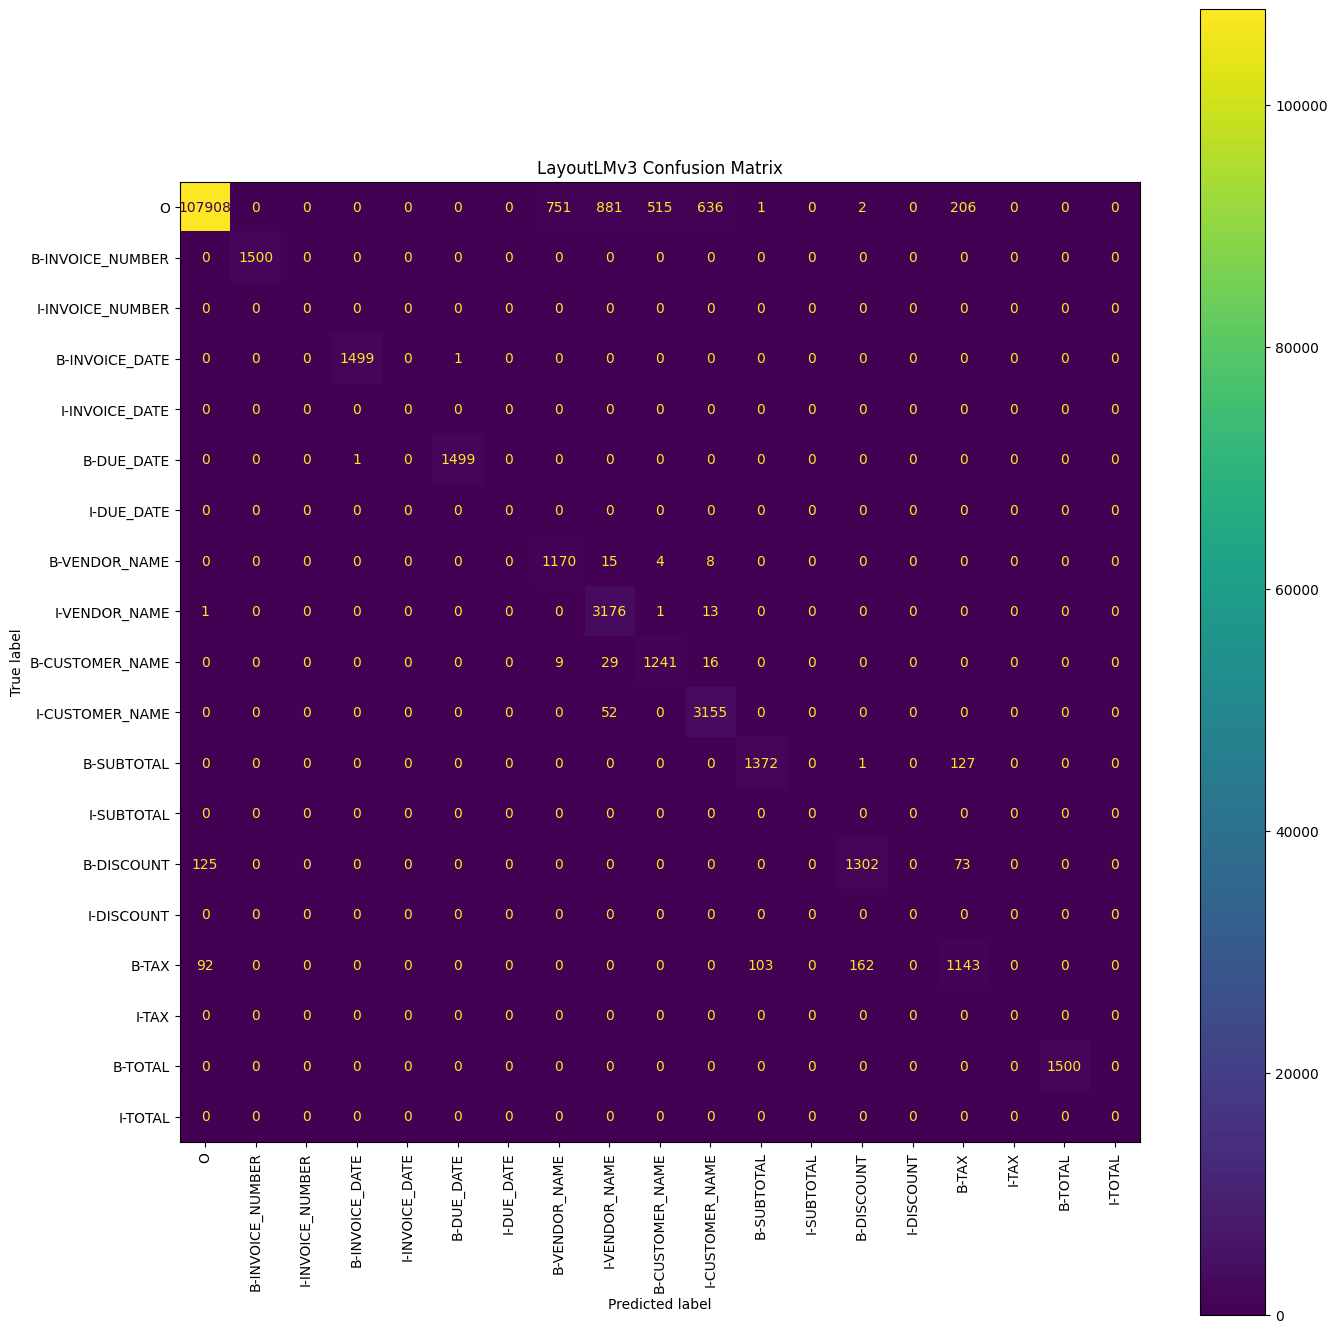

===== LAYOUTLMv3 TEST EVALUATION =====
Accuracy:  97.06%
Precision: 97.65%
Recall:    97.06%
F1 Score:  97.23%
Saved to: /content/drive/MyDrive/Invoice_Dataset/LayoutLMv3/test/evaluation/classification_metrics.json


In [ ]:
# Evaluate LayoutLMv3 using standard classification metrics.
import json
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
EVAL_DIR=BASE_DIR/"LayoutLMv3/test/evaluation"
EVAL_DIR.mkdir(parents=True,exist_ok=True)

y_true,y_pred=[],[]

for path in sorted(POST_TEST_DIR.glob("batch_*.pt")):
    batch=torch.load(path,map_location="cpu")

    for labels,preds in zip(batch["labels"],batch["predictions"]):
        mask=labels!=-100
        y_true.extend(labels[mask].tolist())
        y_pred.extend(preds[mask].tolist())

accuracy=accuracy_score(y_true,y_pred)
precision=precision_score(y_true,y_pred,average="weighted",zero_division=0)
recall=recall_score(y_true,y_pred,average="weighted",zero_division=0)
f1=f1_score(y_true,y_pred,average="weighted",zero_division=0)

print("===== LAYOUTLMv3 TEST EVALUATION =====")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true,y_pred,
    labels=list(range(len(LABEL_LIST))),
    target_names=LABEL_LIST,
    zero_division=0
))

cm=confusion_matrix(y_true,y_pred,labels=list(range(len(LABEL_LIST))))

fig,ax=plt.subplots(figsize=(14,14))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=LABEL_LIST
).plot(ax=ax,xticks_rotation=90)

plt.title("LayoutLMv3 Confusion Matrix")
plt.tight_layout()
plt.savefig(EVAL_DIR/"confusion_matrix.png",dpi=300,bbox_inches="tight")
plt.show()
metrics={
    "accuracy":f"{accuracy*100:.2f}%",
    "precision":f"{precision*100:.2f}%",
    "recall":f"{recall*100:.2f}%",
    "f1_score":f"{f1*100:.2f}%"
}

with open(EVAL_DIR/"classification_metrics.json","w") as f:
    json.dump(metrics,f,indent=4)

print("===== LAYOUTLMv3 TEST EVALUATION =====")
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")

print("Saved to:",EVAL_DIR/"classification_metrics.json")

In [ ]:
# LayoutLMv3 invoice-level evaluation using the same metrics as Donut.
import json
import re
import torch
from pathlib import Path
from decimal import Decimal
from transformers import LayoutLMv3TokenizerFast
BASE_DIR=Path("/content/drive/MyDrive/Invoice_Dataset")
JSON_DIR=BASE_DIR/"json"
PREP_DIR=BASE_DIR/"LayoutLMv3/test/prepared"
PRED_DIR=BASE_DIR/"LayoutLMv3/test/postprocessed_predictions"
MODEL_DIR=BASE_DIR/"LayoutLMv3/final_model"
EVAL_DIR=BASE_DIR/"LayoutLMv3/test/evaluation"
EVAL_DIR.mkdir(parents=True,exist_ok=True)
FIELDS=[
    "invoice_number",
    "invoice_date",
    "due_date",
    "vendor_name",
    "customer_name",
    "subtotal",
    "discount",
    "tax",
    "total"
]

NUMERIC={
    "subtotal",
    "discount",
    "tax",
    "total"
}

LABEL_LIST=[
    "O",
    "B-INVOICE_NUMBER","I-INVOICE_NUMBER",
    "B-INVOICE_DATE","I-INVOICE_DATE",
    "B-DUE_DATE","I-DUE_DATE",
    "B-VENDOR_NAME","I-VENDOR_NAME",
    "B-CUSTOMER_NAME","I-CUSTOMER_NAME",
    "B-SUBTOTAL","I-SUBTOTAL",
    "B-DISCOUNT","I-DISCOUNT",
    "B-TAX","I-TAX",
    "B-TOTAL","I-TOTAL"
]

id2label=dict(enumerate(LABEL_LIST))

tokenizer=LayoutLMv3TokenizerFast.from_pretrained(
    MODEL_DIR
)

print("Fast tokenizer:",tokenizer.is_fast)
prepared_test={}

for path in sorted(PREP_DIR.glob("batch_*.json")):
    with open(path,"r",encoding="utf-8") as f:
        prepared_test.update(json.load(f))

print("Prepared invoices:",len(prepared_test))
def norm(field,value):

    if value is None:
        text=""
    else:
        text=" ".join(
            str(value).strip().split()
        ).lower()

    if field in NUMERIC:

        text=re.sub(
            r"[^\d.\-]",
            "",
            text.replace(",","")
        )

        try:
            x=format(
                Decimal(text).normalize(),
                "f"
            )

            if "." in x:
                x=x.rstrip("0").rstrip(".")

            return x

        except:
            pass

    return text
def extract_fields(record,preds):

    max_length=len(preds)

    enc=tokenizer(
        record["words"],
        boxes=record["boxes"],
        padding="max_length",
        truncation=True,
        max_length=max_length
    )

    word_ids=enc.word_ids()

    word_labels={}

    for token_index,word_index in enumerate(word_ids):

        if (
            word_index is not None
            and word_index not in word_labels
            and token_index<len(preds)
        ):

            label_id=int(preds[token_index])

            word_labels[word_index]=id2label.get(
                label_id,
                "O"
            )

    result={}

    for field in FIELDS:

        target=field.upper()
        spans=[]
        current=[]

        for word_index,word in enumerate(
            record["words"]
        ):

            label=word_labels.get(
                word_index,
                "O"
            )

            if label==f"B-{target}":

                if current:
                    spans.append(current)

                current=[word]

            elif (
                label==f"I-{target}"
                and current
            ):
                current.append(word)

            elif current:
                spans.append(current)
                current=[]

        if current:
            spans.append(current)

        result[field]=(
            " ".join(spans[0])
            if spans
            else ""
        )

    return result
def distance(a,b):

    prev=list(range(len(b)+1))

    for i,x in enumerate(a,1):

        cur=[i]

        for j,y in enumerate(b,1):

            cur.append(
                min(
                    cur[-1]+1,
                    prev[j]+1,
                    prev[j-1]+(x!=y)
                )
            )

        prev=cur

    return prev[-1]


exact=0
field_ok=0
field_total=0
doc_ok=0

char_err=0
char_total=0

total=0


prediction_files=sorted(
    PRED_DIR.glob("batch_*.pt")
)

print("Prediction files:",len(prediction_files))


for path in prediction_files:

    batch=torch.load(
        path,
        map_location="cpu"
    )

    for i,invoice_id in enumerate(
        batch["invoice_ids"]
    ):

        if invoice_id not in prepared_test:
            raise KeyError(
                f"Missing prepared record: {invoice_id}"
            )

        pred=extract_fields(
            prepared_test[invoice_id],
            batch["predictions"][i]
        )

        with open(
            JSON_DIR/f"{invoice_id}.json",
            "r",
            encoding="utf-8"
        ) as f:
            gt_json=json.load(f)

        gt={
            field:gt_json.get(field,"")
            for field in FIELDS
        }

        exact+=all(
            str(pred[field]).strip()
            ==
            str(gt[field]).strip()
            for field in FIELDS
        )
        matches=[
            norm(field,pred[field])
            ==
            norm(field,gt[field])
            for field in FIELDS
        ]

        field_ok+=sum(matches)
        field_total+=len(FIELDS)
        doc_ok+=all(matches)
        pred_text="|".join(
            str(pred[field])
            for field in FIELDS
        )

        gt_text="|".join(
            str(gt[field])
            for field in FIELDS
        )

        char_err+=distance(
            pred_text,
            gt_text
        )

        char_total+=len(gt_text)

        total+=1
if total==0:
    raise ValueError(
        "No LayoutLMv3 Test predictions were evaluated."
    )
if total!=1500:
    raise ValueError(
        f"Expected 1500 Test invoices, evaluated {total}."
    )

exact_match=exact/total*100
field_accuracy=field_ok/field_total*100
document_accuracy=doc_ok/total*100
cer=char_err/char_total*100

invoice_metrics={
    "test_invoices":total,
    "exact_match":f"{exact_match:.2f}%",
    "field_accuracy":f"{field_accuracy:.2f}%",
    "document_accuracy":f"{document_accuracy:.2f}%",
    "cer":f"{cer:.2f}%",
    "correct_documents":f"{doc_ok}/{total}"
}
with open(
    EVAL_DIR/"invoice_metrics.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        invoice_metrics,
        f,
        indent=4,
        ensure_ascii=False
    )
print("\n===== LAYOUTLMv3 INVOICE METRICS =====")
print(f"Test Invoices:      {total}")
print(f"Exact Match:        {exact_match:.2f}%")
print(f"Field Accuracy:     {field_accuracy:.2f}%")
print(f"Document Accuracy:  {document_accuracy:.2f}%")
print(f"CER:                {cer:.2f}%")
print(f"Correct Documents:  {doc_ok}/{total}")

print(
    "Saved to:",
    EVAL_DIR/"invoice_metrics.json"
)

Fast tokenizer: True
Prepared invoices: 1500
Prediction files: 3

===== LAYOUTLMv3 INVOICE METRICS =====
Test Invoices:      1500
Exact Match:        0.33%
Field Accuracy:     92.10%
Document Accuracy:  54.87%
CER:                10.10%
Correct Documents:  823/1500
Saved to: /content/drive/MyDrive/Invoice_Dataset/LayoutLMv3/test/evaluation/invoice_metrics.json


In [ ]:
# Count field errors per Test invoice.

from collections import Counter

error_distribution=Counter()

for path in sorted(PRED_DIR.glob("batch_*.pt")):
    batch=torch.load(path,map_location="cpu")

    for i,invoice_id in enumerate(batch["invoice_ids"]):
        pred=extract_fields(prepared_test[invoice_id],batch["predictions"][i])

        with open(JSON_DIR/f"{invoice_id}.json",encoding="utf-8") as f:
            gt=json.load(f)

        errors=sum(
            norm(field,pred[field])!=norm(field,gt.get(field,""))
            for field in FIELDS
        )
        error_distribution[errors]+=1

print("===== ERRORS PER INVOICE =====")
for errors,count in sorted(error_distribution.items()):
    print(f"{errors} error(s): {count:4d} invoices ({count/1500*100:.2f}%)")

===== ERRORS PER INVOICE =====
0 error(s):  823 invoices (54.87%)
1 error(s):  325 invoices (21.67%)
2 error(s):  317 invoices (21.13%)
3 error(s):   32 invoices (2.13%)
4 error(s):    3 invoices (0.20%)


In [ ]:
# Install PaddleOCR in the current runtime.

%pip install -q -U paddlepaddle paddleocr

import paddle
from paddleocr import PaddleOCR

print("Paddle:", paddle.__version__)
print("PaddleOCR imported successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.9/47.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 759.5/759.5 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3

/usr/local/lib/python3.13/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Paddle: 3.3.1
PaddleOCR imported successfully


Saving invoice (2).png to invoice (2) (1).png
Image: invoice (2) (1).png
Size: (805, 843)


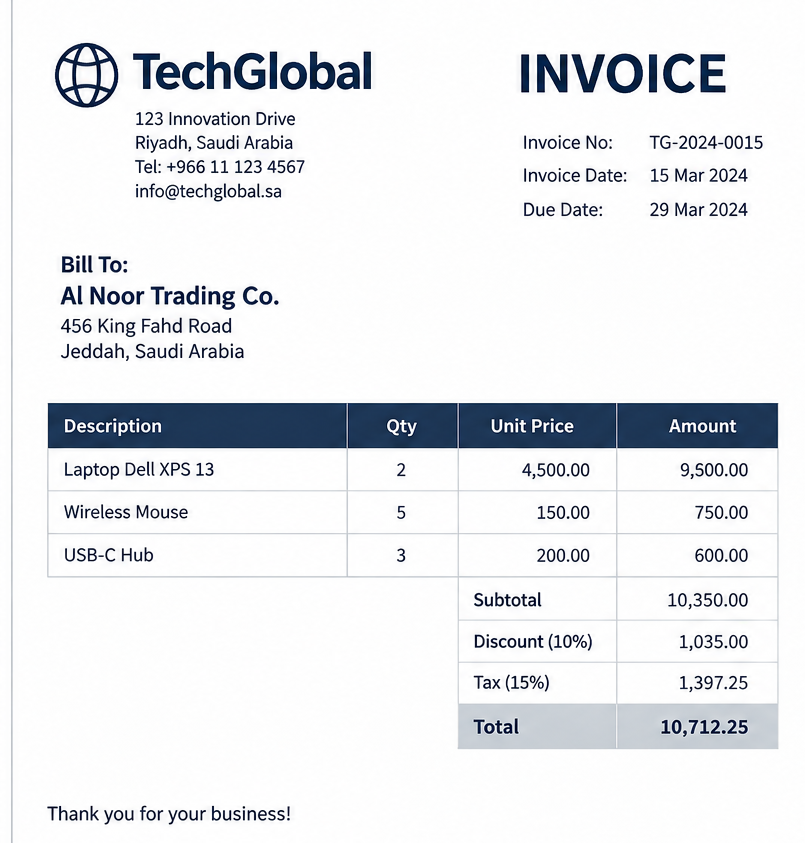

In [ ]:
# 1. Upload a new invoice image.

from google.colab import files
from pathlib import Path
from PIL import Image

uploaded=files.upload()
image_path=Path(next(iter(uploaded)))

image=Image.open(image_path)
print("Image:",image_path.name)
print("Size:",image.size)
display(image)

In [ ]:
# 2. Run PP-OCRv6

from paddleocr import PaddleOCR

ocr=PaddleOCR(
    lang="en",
    device="cpu",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    enable_mkldnn=False
)

result=ocr.predict(str(image_path))[0]

words,boxes=[],[]
w,h=image.size

for text,box in zip(result["rec_texts"],result["rec_boxes"]):
    parts=str(text).split()
    if not parts: continue
    x1,y1,x2,y2=map(float,box)
    total=sum(map(len,parts))+len(parts)-1
    cursor=0

    for word in parts:
        start=cursor/total
        end=(cursor+len(word))/total
        bx=[
            round((x1+(x2-x1)*start)/w*1000),
            round(y1/h*1000),
            round((x1+(x2-x1)*end)/w*1000),
            round(y2/h*1000)
        ]
        words.append(word)
        boxes.append([max(0,min(1000,x)) for x in bx])
        cursor+=len(word)+1

record={"words":words,"boxes":boxes,"boxes_1000":boxes}

print("OCR words:",len(words))
print(words[:30])

Creating model: ('PP-OCRv6_medium_det', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-OCRv6_medium_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_det`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Creating model: ('PP-OCRv6_medium_rec', None, None)
Using official model (PP-OCRv6_medium_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

OCR words: 77
['TechGlobal', 'INVOICE', '123', 'Innovation', 'Drive', 'Riyadh,', 'Saudi', 'Arabia', 'Invoice', 'No:', 'TG-2024-0015', 'Tel:', '+966', '11', '123', '4567', 'Invoice', 'Date:', '15', 'Mar', '2024', 'info@techglobal.sa', 'Due', 'Date:', '29', 'Mar', '2024', 'Bill', 'To:', 'Al']


In [ ]:
# 3. Extract invoice fields with the final LayoutLMv3 pipeline.

import torch,importlib.util
from pathlib import Path
from transformers import AutoProcessor,AutoModelForTokenClassification

BASE_DIR=Path("/content/drive/MyDrive/Invoice_Dataset")
MODEL_DIR=BASE_DIR/"LayoutLMv3/final_model"
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor=AutoProcessor.from_pretrained(MODEL_DIR,apply_ocr=False)
model=AutoModelForTokenClassification.from_pretrained(MODEL_DIR).to(device).eval()

id2label={int(k):v for k,v in model.config.id2label.items()}
label2id={v:k for k,v in id2label.items()}

enc=processor.tokenizer(
    record["words"],
    boxes=record["boxes"],
    padding="max_length",
    truncation=True,
    max_length=512,
    return_tensors="pt"
)

with torch.no_grad():
    logits=model(
        input_ids=enc["input_ids"].to(device),
        attention_mask=enc["attention_mask"].to(device),
        bbox=enc["bbox"].to(device)
    ).logits[0]

preds=logits.argmax(-1).cpu()
word_ids=enc.word_ids(batch_index=0)

mask=torch.full_like(preds,-100)
seen=set()
for i,wid in enumerate(word_ids):
    if wid is not None and wid not in seen:
        mask[i]=0
        seen.add(wid)

spec=importlib.util.spec_from_file_location("postprocessing",MODEL_DIR/"postprocessing.py")
postprocessing=importlib.util.module_from_spec(spec)
spec.loader.exec_module(postprocessing)

preds=postprocessing.correct_vendor_customer(
    preds,mask,enc["bbox"][0],record,label2id
)
if isinstance(preds,tuple):
    preds=preds[0]

word_labels={}
for i,wid in enumerate(word_ids):
    if wid is not None and wid not in word_labels:
        word_labels[wid]=id2label[int(preds[i])]

fields=["invoice_number","invoice_date","due_date","vendor_name","customer_name",
        "subtotal","discount","tax","total"]

output={}
for field in fields:
    target=field.upper()
    spans,current=[],[]

    for i,word in enumerate(record["words"]):
        label=word_labels.get(i,"O")

        if label==f"B-{target}":
            if current: spans.append(current)
            current=[word]
        elif label==f"I-{target}" and current:
            current.append(word)
        elif current:
            spans.append(current)
            current=[]

    if current: spans.append(current)
    output[field]=" ".join(spans[0]) if spans else ""

print("\n===== EXTRACTED INVOICE =====")
for field,value in output.items():
    print(f"{field:18}: {value}")

Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]


===== EXTRACTED INVOICE =====
invoice_number    : TG-2024-0015
invoice_date      : 
due_date          : 
vendor_name       : TechGlobal
customer_name     : 
subtotal          : 10,350.00
discount          : 1,035.00
tax               : 750.00
total             : 10,712.25


In [ ]:
# Debug predictions around important invoice anchors.

raw_preds=logits.argmax(-1).cpu()

raw_word_labels={}
final_word_labels={}

for i,wid in enumerate(word_ids):
    if wid is not None and wid not in raw_word_labels:
        raw_word_labels[wid]=id2label[int(raw_preds[i])]
        final_word_labels[wid]=id2label[int(preds[i])]

def show_context(anchor_words,window=5):
    words_lower=[str(w).lower().strip(":") for w in record["words"]]
    anchor=[w.lower() for w in anchor_words]

    for i in range(len(words_lower)-len(anchor)+1):
        if words_lower[i:i+len(anchor)]==anchor:
            start=max(0,i-window)
            end=min(len(record["words"]),i+len(anchor)+window)

            print(f"\n===== {' '.join(anchor_words)} =====")
            print(f"{'WORD':20} {'RAW':22} {'FINAL':22}")
            print("-"*66)

            for j in range(start,end):
                print(
                    f"{record['words'][j]:20} "
                    f"{raw_word_labels.get(j,'O'):22} "
                    f"{final_word_labels.get(j,'O'):22}"
                )

show_context(["Invoice","Date"])
show_context(["Due","Date"])
show_context(["Bill","To"])


===== Invoice Date =====
WORD                 RAW                    FINAL                 
------------------------------------------------------------------
Tel:                 O                      O                     
+966                 O                      O                     
11                   O                      O                     
123                  O                      O                     
4567                 O                      O                     
Invoice              O                      O                     
Date:                O                      O                     
15                   O                      O                     
Mar                  O                      O                     
2024                 O                      O                     
info@techglobal.sa   O                      O                     
Due                  O                      O                     

===== Due Date =====
WORD          

In [ ]:
# Check GT-to-OCR alignment coverage for every target field.

import json
from pathlib import Path
from collections import Counter,defaultdict

BASE_DIR=Path("/content/drive/MyDrive/Invoice_Dataset")
OCR_DIR=BASE_DIR/"OCR_PP-OCRv6"

FIELDS=[
    "invoice_number","invoice_date","due_date",
    "vendor_name","customer_name",
    "subtotal","discount","tax","total"
]

def check_alignment(split):
    counts={field:Counter() for field in FIELDS}
    examples=defaultdict(list)
    total=0

    for path in sorted((OCR_DIR/split).glob("batch_*.json")):
        with open(path,encoding="utf-8") as f:
            records=json.load(f)

        if isinstance(records,dict):
            records=records.values()

        for record in records:
            total+=1
            invoice_id=record.get("invoice_id","unknown")

            for field in FIELDS:
                info=record.get("alignments",{}).get(field,{})
                status=info.get("status","MISSING")
                counts[field][status]+=1

                if status!="ALIGNED" and len(examples[field])<5:
                    examples[field].append((invoice_id,status))

    print(f"\n===== {split.upper()} =====")
    print("Invoices:",total)

    for field in FIELDS:
        aligned=counts[field]["ALIGNED"]
        pct=aligned/total*100 if total else 0
        other=sum(v for k,v in counts[field].items() if k!="ALIGNED")

        print(
            f"{field:18} "
            f"Aligned: {aligned:4d}/{total} "
            f"({pct:6.2f}%) | "
            f"Not aligned: {other}"
        )

    return counts,examples,total

train_counts,train_examples,train_total=check_alignment("train")
val_counts,val_examples,val_total=check_alignment("validation")

print("\n===== COMBINED TRAIN + VALIDATION =====")
grand_total=train_total+val_total

for field in FIELDS:
    aligned=train_counts[field]["ALIGNED"]+val_counts[field]["ALIGNED"]
    pct=aligned/grand_total*100
    print(f"{field:18} {aligned:4d}/{grand_total} ({pct:6.2f}%)")


===== TRAIN =====
Invoices: 7000
invoice_number     Aligned: 7000/7000 (100.00%) | Not aligned: 0
invoice_date       Aligned: 7000/7000 (100.00%) | Not aligned: 0
due_date           Aligned: 7000/7000 (100.00%) | Not aligned: 0
vendor_name        Aligned: 7000/7000 (100.00%) | Not aligned: 0
customer_name      Aligned: 7000/7000 (100.00%) | Not aligned: 0
subtotal           Aligned: 7000/7000 (100.00%) | Not aligned: 0
discount           Aligned: 7000/7000 (100.00%) | Not aligned: 0
tax                Aligned: 7000/7000 (100.00%) | Not aligned: 0
total              Aligned: 7000/7000 (100.00%) | Not aligned: 0

===== VALIDATION =====
Invoices: 1500
invoice_number     Aligned: 1500/1500 (100.00%) | Not aligned: 0
invoice_date       Aligned: 1500/1500 (100.00%) | Not aligned: 0
due_date           Aligned: 1500/1500 (100.00%) | Not aligned: 0
vendor_name        Aligned: 1500/1500 (100.00%) | Not aligned: 0
customer_name      Aligned: 1500/1500 (100.00%) | Not aligned: 0
subtotal         

#<font face="Georgia" color="#D8B4FE" size="6.9">DOUNT Model</font>


##1.Data Preparation

###1.1 Data Paths & Split


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/Invoice_Dataset")
SPLIT_FILE = BASE_DIR / "Dataset_Update-v2" / "dataset_split_v2.json"

with open(SPLIT_FILE, "r") as f:
    split_ids = json.load(f)

train_ids = split_ids["train"]
val_ids = split_ids["validation"]
test_ids = split_ids["test"]

print(len(train_ids), len(val_ids), len(test_ids))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
7000 1500 1500


In [ ]:
# Define Donut dataset paths, output directory and fixed target schema.

IMAGE_DIR=BASE_DIR/"Dataset_Update-v2"/"images_update-v2"
JSON_DIR=BASE_DIR/"json"
DONUT_DIR=BASE_DIR/"DOUNT_Model"

DONUT_DIR.mkdir(parents=True,exist_ok=True)

FIELDS=[
    "invoice_number",
    "invoice_date",
    "due_date",
    "vendor_name",
    "customer_name",
    "subtotal",
    "discount",
    "tax",
    "total"
]

FIELD_ALIASES={
    "invoice_number":["Invoice Number","Invoice No","Invoice #","Inv No"],
    "invoice_date":["Invoice Date","Issue Date","Issued Date","Date"],
    "due_date":["Due Date","Payment Due","Pay By"],
    "vendor_name":["Vendor","Seller","Supplier","From"],
    "customer_name":["Customer","Bill To","Buyer","Client"],
    "subtotal":["Subtotal","Sub Total","Net Amount"],
    "discount":["Discount","Discount Amount","Disc."],
    "tax":["Tax","VAT","VAT Amount","Sales Tax"],
    "total":["Total","Grand Total","Total Due","Amount Payable"]
}

print("Images:",IMAGE_DIR)
print("JSON:",JSON_DIR)
print("Donut output:",DONUT_DIR)
print("Fields:",len(FIELDS))

Images: /content/drive/MyDrive/Invoice_Dataset/Dataset_Update-v2/images_update-v2
JSON: /content/drive/MyDrive/Invoice_Dataset/json
Donut output: /content/drive/MyDrive/Invoice_Dataset/DOUNT_Model
Fields: 9


###1.2 Load Donut Base Model & Processor


In [ ]:
# Installs  libraries for Donut

!pip install -q transformers datasets sentencepiece accelerate

In [ ]:
# Loads the Donut model and processor
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
MODEL_NAME = "naver-clova-ix/donut-base"
processor = DonutProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

Device: cuda
GPU: Tesla T4


###1.3 JSON to Target Sequence

In [ ]:
# Convert invoice JSON into a fixed Donut target sequence.
TASK_START_TOKEN="<s_invoice>"
TASK_END_TOKEN="</s_invoice>"
def clean_value(value):
    if value is None:
        return ""
    return " ".join(str(value).split())
def json_to_sequence(data):
    sequence=""
    for field in FIELDS:
        value=clean_value(data.get(field,""))
        sequence+=f"<s_{field}>{value}</s_{field}>"

    sequence+=TASK_END_TOKEN
    return sequence

###1.4 Special Tokens Setup

In [ ]:
# Reads all 7,000 training JSON files and Collects special tokens from training JSON files and saves the prepared Donut tokenizer/model.
TOKENIZER_DIR=DONUT_DIR/"tokenizer_setup"
special_tokens=[TASK_START_TOKEN,TASK_END_TOKEN]
for field in FIELDS:
    special_tokens.extend([
        f"<s_{field}>",
        f"</s_{field}>"
    ])
added_tokens=processor.tokenizer.add_special_tokens({
    "additional_special_tokens":special_tokens
})
model.decoder.resize_token_embeddings(len(processor.tokenizer))
model.config.decoder_start_token_id=processor.tokenizer.convert_tokens_to_ids(TASK_START_TOKEN)
model.config.eos_token_id=processor.tokenizer.convert_tokens_to_ids(TASK_END_TOKEN)
model.config.pad_token_id=processor.tokenizer.pad_token_id
model.config.vocab_size=len(processor.tokenizer)
TOKENIZER_DIR.mkdir(parents=True,exist_ok=True)
processor.save_pretrained(TOKENIZER_DIR)
model.save_pretrained(TOKENIZER_DIR)
with open(TOKENIZER_DIR/"special_tokens.json","w",encoding="utf-8") as f:
    json.dump(special_tokens,f,indent=2)
print("Special tokens:",len(special_tokens))
print("New tokens added:",added_tokens)
print("Tokenizer size:",len(processor.tokenizer))
print("Start token ID:",model.config.decoder_start_token_id)
print("End token ID:",model.config.eos_token_id)
print("Saved to:",TOKENIZER_DIR)

In [ ]:
# Check and cache target sequence lengths for all training invoices.
import json
from pathlib import Path
BASE_DIR=Path("/content/drive/MyDrive/Invoice_Dataset")
JSON_DIR=BASE_DIR/"json"
DONUT_DIR=BASE_DIR/"DOUNT_Model"
DONUT_DIR.mkdir(parents=True,exist_ok=True)
split_files=list(BASE_DIR.rglob("dataset_split_v2.json"))
if len(split_files)==0:
    raise FileNotFoundError("dataset_split_v2.json was not found inside Invoice_Dataset")
if len(split_files)>1:
    print("Multiple split files found:")
    for p in split_files:
        print(p)
    raise ValueError("More than one dataset_split_v2.json was found")
SPLIT_FILE=split_files[0]
LENGTH_FILE=DONUT_DIR/"train_target_lengths.json"
print("Split file:",SPLIT_FILE)
with open(SPLIT_FILE,"r",encoding="utf-8") as f:
    split_data=json.load(f)
train_ids=split_data["train"]
print("Train invoices:",len(train_ids))
if LENGTH_FILE.exists():
    with open(LENGTH_FILE,"r",encoding="utf-8") as f:
        length_data=json.load(f)
    lengths=length_data["lengths"]
    print("\nLoaded saved target lengths.")
    print("Invoices:",len(lengths))
    print("Minimum:",length_data["minimum"])
    print("Average:",length_data["average"])
    print("Maximum:",length_data["maximum"])
else:
    lengths=[]
    for i,invoice_id in enumerate(train_ids,1):
        with open(JSON_DIR/f"{invoice_id}.json","r",encoding="utf-8") as f:
            data=json.load(f)
        text=json_to_sequence(data)
        token_ids=processor.tokenizer(
            text,
            add_special_tokens=False,
            truncation=False
        ).input_ids
        lengths.append(len(token_ids))
        if i%500==0:
            print(f"Checked: {i}/{len(train_ids)}")
    length_data={
        "invoices":len(lengths),
        "minimum":min(lengths),
        "average":round(sum(lengths)/len(lengths),2),
        "maximum":max(lengths),
        "lengths":lengths
    }
    with open(LENGTH_FILE,"w",encoding="utf-8") as f:
        json.dump(length_data,f,indent=2)
    print("\nTarget length check complete.")
    print("Invoices:",len(lengths))
    print("Minimum:",length_data["minimum"])
    print("Average:",length_data["average"])
    print("Maximum:",length_data["maximum"])
    print("Saved to:",LENGTH_FILE)

###1.5 Dataset Preparation

In [ ]:
# Create Donut datasets using the fixed 9-field target schema.
import json
import torch
from PIL import Image
from torch.utils.data import Dataset
MAX_LENGTH=256
class InvoiceDonutDataset(Dataset):
    def __init__(self, invoice_ids, image_dir, json_dir, processor, max_length=256):
        self.invoice_ids=invoice_ids
        self.image_dir=image_dir
        self.json_dir=json_dir
        self.processor=processor
        self.max_length=max_length
    def __len__(self):
        return len(self.invoice_ids)
    def __getitem__(self,idx):
        invoice_id=self.invoice_ids[idx]
        image=Image.open(self.image_dir/f"{invoice_id}.png").convert("RGB")
        with open(self.json_dir/f"{invoice_id}.json","r",encoding="utf-8") as f:
            data=json.load(f)
        pixel_values=self.processor(
            image,
            return_tensors="pt"
        ).pixel_values.squeeze(0)
        target=json_to_sequence(data)
        labels=self.processor.tokenizer(
            target,
            add_special_tokens=False,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        ).input_ids.squeeze(0)
        labels[labels==self.processor.tokenizer.pad_token_id]=-100
        return {
            "pixel_values":pixel_values,
            "labels":labels,
            "invoice_id":invoice_id
        }

In [ ]:
# Create Train and Validation datasets.

train_dataset=InvoiceDonutDataset(
    invoice_ids=train_ids,
    image_dir=IMAGE_DIR,
    json_dir=JSON_DIR,
    processor=processor,
    max_length=MAX_LENGTH
)

val_dataset=InvoiceDonutDataset(
    invoice_ids=val_ids,
    image_dir=IMAGE_DIR,
    json_dir=JSON_DIR,
    processor=processor,
    max_length=MAX_LENGTH
)

print("Train dataset:",len(train_dataset))
print("Validation dataset:",len(val_dataset))

Train dataset: 7000
Validation dataset: 1500


In [ ]:
# Check missing or empty Ground Truth fields in Train and Validation

from collections import Counter

def check_missing_fields(invoice_ids,name):
    counts=Counter()

    for invoice_id in invoice_ids:
        with open(JSON_DIR/f"{invoice_id}.json","r",encoding="utf-8") as f:
            data=json.load(f)

        for field in FIELDS:
            value=data.get(field,None)

            if value is None or str(value).strip()=="":
                counts[field]+=1

    print(f"\n===== {name} =====")
    for field in FIELDS:
        print(f"{field:18}: {counts[field]} missing")

check_missing_fields(train_ids,"TRAIN")
check_missing_fields(val_ids,"VALIDATION")

##2. Model Training & Evaluation


###2.1 Model Configuration

In [ ]:
# Configure Donut model

import gc
import torch
from pathlib import Path
from transformers import DonutProcessor,VisionEncoderDecoderModel

BASE_DIR=Path("/content/drive/MyDrive/Invoice_Dataset")
DONUT_DIR=BASE_DIR/"DOUNT_Model"

MODEL_DIR=DONUT_DIR/"tokenizer_setup"
OUTPUT_DIR=DONUT_DIR/"donut_training_unseen_layouts"
FINAL_DIR=OUTPUT_DIR/"final_model"

OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

TASK_START_TOKEN="<s_invoice>"
TASK_END_TOKEN="</s_invoice>"
MAX_LENGTH=256

gc.collect()
torch.cuda.empty_cache()

processor=DonutProcessor.from_pretrained(MODEL_DIR)
processor.image_processor.size={"height":1280,"width":960}

model=VisionEncoderDecoderModel.from_pretrained(
    MODEL_DIR,
    low_cpu_mem_usage=True
)

start_id=processor.tokenizer.convert_tokens_to_ids(TASK_START_TOKEN)
end_id=processor.tokenizer.convert_tokens_to_ids(TASK_END_TOKEN)
pad_id=processor.tokenizer.pad_token_id

model.config.decoder_start_token_id=start_id
model.config.eos_token_id=end_id
model.config.pad_token_id=pad_id

model.decoder.config.pad_token_id=pad_id
model.decoder.config.eos_token_id=end_id

model.generation_config.decoder_start_token_id=start_id
model.generation_config.eos_token_id=end_id
model.generation_config.pad_token_id=pad_id
model.generation_config.max_length=MAX_LENGTH

model.config.use_cache=False
model.decoder.config.use_cache=False
model.gradient_checkpointing_enable()

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train_dataset.processor=processor
val_dataset.processor=processor

print("Device:",device)
print("Model directory:",MODEL_DIR)
print("Training directory:",OUTPUT_DIR)
print("Decoder start token ID:",start_id)
print("End token ID:",end_id)
print("Pad token ID:",pad_id)
print("Max length:",model.generation_config.max_length)
print("Image size:",processor.image_processor.size)
print("Train:",len(train_dataset))
print("Validation:",len(val_dataset))

Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

Device: cuda
Model directory: /content/drive/MyDrive/Invoice_Dataset/DOUNT_Model/tokenizer_setup
Training directory: /content/drive/MyDrive/Invoice_Dataset/DOUNT_Model/donut_training_unseen_layouts
Decoder start token ID: 57525
End token ID: 57526
Pad token ID: 1
Max length: 256
Image size: {'height': 1280, 'width': 960}
Train: 7000
Validation: 1500


###2.2 Train 7000 + Validation 1500

In [ ]:
# Train Donut on 7,000 invoices and validate on 1,500 invoices.

import gc
import torch
from transformers import Seq2SeqTrainer,Seq2SeqTrainingArguments
from transformers.trainer_utils import get_last_checkpoint

gc.collect()
torch.cuda.empty_cache()

def donut_collator(features):
    return {
        "pixel_values":torch.stack([f["pixel_values"] for f in features]),
        "labels":torch.stack([f["labels"] for f in features])
    }

args=Seq2SeqTrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=2,
    learning_rate=5e-5,
    fp16=torch.cuda.is_available(),
    eval_strategy="epoch",
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    logging_strategy="steps",
    logging_steps=50,
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    remove_unused_columns=False,
    report_to="none",
    disable_tqdm=False
)

trainer=Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=donut_collator
)

print("===== DONUT TRAINING =====")
print("Train:",len(train_dataset))
print("Validation:",len(val_dataset))
print("Epochs:",args.num_train_epochs)
print("Batch size:",args.per_device_train_batch_size)
print("Gradient accumulation:",args.gradient_accumulation_steps)
print("Effective batch size:",
      args.per_device_train_batch_size*args.gradient_accumulation_steps)
print("Learning rate:",args.learning_rate)
print("Max length:",MAX_LENGTH)
print("Checkpoint every:",args.save_steps,"steps")
print("Output:",OUTPUT_DIR)

last_checkpoint=get_last_checkpoint(str(OUTPUT_DIR))

if last_checkpoint:
    print("\nResuming from:",last_checkpoint)
    train_result=trainer.train(resume_from_checkpoint=last_checkpoint)
else:
    print("\nNo checkpoint found. Starting new training.")
    train_result=trainer.train()

trainer.save_metrics("train",train_result.metrics)
trainer.save_state()

print("\n===== VALIDATION =====")
val_metrics=trainer.evaluate(eval_dataset=val_dataset)

print("Validation completed")
print("Validation Loss:",val_metrics["eval_loss"])

trainer.save_metrics("validation",val_metrics)

FINAL_DIR.mkdir(parents=True,exist_ok=True)
trainer.save_model(str(FINAL_DIR))
processor.save_pretrained(str(FINAL_DIR))

print("\nTraining completed.")
print("Final model saved at:")
print(FINAL_DIR)

###2.3 Testing

In [ ]:
# Test on all 1,500
import json
import gc
import torch
from pathlib import Path
from PIL import Image
from transformers import DonutProcessor,VisionEncoderDecoderModel
BASE_DIR=Path("/content/drive/MyDrive/Invoice_Dataset")
MODEL_DIR=(
    BASE_DIR
    /"DOUNT_Model"
    /"donut_training_unseen_layouts"
    /"final_model"
)
IMAGE_DIR=(
    BASE_DIR
    /"Dataset_Update-v2"
    /"images_update-v2"
)
SPLIT_FILE=(
    BASE_DIR
    /"Dataset_Update-v2"
    /"dataset_split_v2.json"
)
OUTPUT_DIR=(
    BASE_DIR
    /"DOUNT_Model"
    /"Test_Results"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)
PREDICTIONS_FILE=OUTPUT_DIR/"test_predictions.json"
TASK_START_TOKEN="<s_invoice>"
TASK_END_TOKEN="</s_invoice>"
MAX_LENGTH=256
device=torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
processor=DonutProcessor.from_pretrained(
    MODEL_DIR
)
processor.image_processor.size={
    "height":1280,
    "width":960
}
model=VisionEncoderDecoderModel.from_pretrained(
    MODEL_DIR
).to(device)
model.eval()
start_id=processor.tokenizer.convert_tokens_to_ids(
    TASK_START_TOKEN
)
end_id=processor.tokenizer.convert_tokens_to_ids(
    TASK_END_TOKEN
)
pad_id=processor.tokenizer.pad_token_id
model.generation_config.decoder_start_token_id=start_id
model.generation_config.eos_token_id=end_id
model.generation_config.pad_token_id=pad_id
model.generation_config.max_length=MAX_LENGTH
with open(
    SPLIT_FILE,
    "r",
    encoding="utf-8"
) as f:
    test_ids=json.load(f)["test"]

if PREDICTIONS_FILE.exists():
    with open(
        PREDICTIONS_FILE,
        "r",
        encoding="utf-8"
    ) as f:
        predictions=json.load(f)
else:
    predictions={}
prompt_ids=processor.tokenizer(
    TASK_START_TOKEN,
    add_special_tokens=False,
    return_tensors="pt"
).input_ids.to(device)
print("===== DONUT TESTING =====")
print("Device:",device)
print("Total Test:",len(test_ids))
print("Already completed:",len(predictions))
print("Remaining:",len(test_ids)-len(predictions))
print("Model:",MODEL_DIR)
print("Max length:",MAX_LENGTH)
for i,invoice_id in enumerate(
    test_ids,
    1
):
    if invoice_id in predictions:
        continue

    image=Image.open(
        IMAGE_DIR/f"{invoice_id}.png"
    ).convert("RGB")

    pixel_values=processor(
        image,
        return_tensors="pt"
    ).pixel_values.to(device)

    with torch.inference_mode():
        outputs=model.generate(
            pixel_values,
            decoder_input_ids=prompt_ids,
            max_length=MAX_LENGTH,
            eos_token_id=end_id,
            pad_token_id=pad_id
        )
    prediction=processor.tokenizer.decode(
        outputs[0][1:],
        skip_special_tokens=False
    )
    predictions[invoice_id]=prediction

    if len(predictions)%25==0:
        with open(
            PREDICTIONS_FILE,
            "w",
            encoding="utf-8"
        ) as f:
            json.dump(
                predictions,
                f,
                indent=2,
                ensure_ascii=False
            )

        print(
            f"Saved: {len(predictions)}/{len(test_ids)}"
        )
with open(
    PREDICTIONS_FILE,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        predictions,
        f,
        indent=2,
        ensure_ascii=False
    )
print("\nTesting completed.")
print("Predictions:",len(predictions))
print("Saved at:")
print(PREDICTIONS_FILE)

Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

===== DONUT TESTING =====
Device: cuda
Total Test: 1500
Already completed: 0
Remaining: 1500
Model: /content/drive/MyDrive/Invoice_Dataset/DOUNT_Model/donut_training_unseen_layouts/final_model
Max length: 256
Saved: 25/1500
Saved: 50/1500
Saved: 75/1500
Saved: 100/1500
Saved: 125/1500
Saved: 150/1500
Saved: 175/1500
Saved: 200/1500
Saved: 225/1500
Saved: 250/1500
Saved: 275/1500
Saved: 300/1500
Saved: 325/1500
Saved: 350/1500
Saved: 375/1500
Saved: 400/1500
Saved: 425/1500
Saved: 450/1500
Saved: 475/1500
Saved: 500/1500
Saved: 525/1500
Saved: 550/1500
Saved: 575/1500
Saved: 600/1500
Saved: 625/1500
Saved: 650/1500
Saved: 675/1500
Saved: 700/1500
Saved: 725/1500
Saved: 750/1500
Saved: 775/1500
Saved: 800/1500
Saved: 825/1500
Saved: 850/1500
Saved: 875/1500
Saved: 900/1500
Saved: 925/1500
Saved: 950/1500
Saved: 975/1500
Saved: 1000/1500
Saved: 1025/1500
Saved: 1050/1500
Saved: 1075/1500
Saved: 1100/1500
Saved: 1125/1500
Saved: 1150/1500
Saved: 1175/1500
Saved: 1200/1500
Saved: 1225/1500


###2.4 Evaluation Metrics

In [ ]:

import json
import re
from pathlib import Path
from decimal import Decimal

BASE_DIR=Path("/content/drive/MyDrive/Invoice_Dataset")

JSON_DIR=BASE_DIR/"json"

PREDICTIONS_FILE=(
    BASE_DIR
    /"DOUNT_Model"
    /"Test_Results"
    /"test_predictions.json"
)

SPLIT_FILE=(
    BASE_DIR
    /"Dataset_Update-v2"
    /"dataset_split_v2.json"
)

EVAL_DIR=(
    BASE_DIR
    /"DOUNT_Model"
    /"Test_Results"
    /"evaluation"
)

EVAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIELDS=[
    "invoice_number",
    "invoice_date",
    "due_date",
    "vendor_name",
    "customer_name",
    "subtotal",
    "discount",
    "tax",
    "total"
]

NUMERIC={
    "subtotal",
    "discount",
    "tax",
    "total"
}

with open(
    PREDICTIONS_FILE,
    "r",
    encoding="utf-8"
) as f:
    predictions=json.load(f)
with open(
    SPLIT_FILE,
    "r",
    encoding="utf-8"
) as f:
    test_ids=json.load(f)["test"]


if len(predictions)!=len(test_ids):
    raise ValueError(
        f"Incomplete predictions: {len(predictions)}/{len(test_ids)}"
    )
def norm(field,value):

    if value is None:
        text=""
    else:
        text=" ".join(
            str(value).strip().split()
        ).lower()

    if field in NUMERIC:

        text=re.sub(
            r"[^\d.\-]",
            "",
            text.replace(",","")
        )

        try:
            x=format(
                Decimal(text).normalize(),
                "f"
            )

            if "." in x:
                x=x.rstrip("0").rstrip(".")

            return x

        except:
            pass

    return text
def extract_fields(sequence):

    result={}

    for field in FIELDS:

        match=re.search(
            rf"<s_{field}>(.*?)</s_{field}>",
            sequence,
            flags=re.DOTALL
        )

        result[field]=(
            match.group(1).strip()
            if match
            else ""
        )

    return result
def distance(a,b):

    prev=list(
        range(len(b)+1)
    )

    for i,x in enumerate(a,1):

        cur=[i]

        for j,y in enumerate(b,1):

            cur.append(
                min(
                    cur[-1]+1,
                    prev[j]+1,
                    prev[j-1]+(x!=y)
                )
            )

        prev=cur

    return prev[-1]


exact=0
field_ok=0
field_total=0
doc_ok=0

char_err=0
char_total=0

total=0


for invoice_id in test_ids:

    prediction_sequence=predictions[
        invoice_id
    ]

    pred=extract_fields(
        prediction_sequence
    )

    with open(
        JSON_DIR/f"{invoice_id}.json",
        "r",
        encoding="utf-8"
    ) as f:
        gt_json=json.load(f)

    gt={
        field:gt_json.get(field,"")
        for field in FIELDS
    }
    exact+=all(
        str(pred[field]).strip()
        ==
        str(gt[field]).strip()
        for field in FIELDS
    )
    matches=[
        norm(field,pred[field])
        ==
        norm(field,gt[field])
        for field in FIELDS
    ]
    field_ok+=sum(matches)
    field_total+=len(FIELDS)
    doc_ok+=all(matches)

    pred_text="|".join(
        str(pred[field])
        for field in FIELDS
    )

    gt_text="|".join(
        str(gt[field])
        for field in FIELDS
    )

    char_err+=distance(
        pred_text,
        gt_text
    )

    char_total+=len(
        gt_text
    )

    total+=1


exact_match=(
    exact
    /total
    *100
)

field_accuracy=(
    field_ok
    /field_total
    *100
)

document_accuracy=(
    doc_ok
    /total
    *100
)
cer=(
    char_err
    /char_total
    *100
)

invoice_metrics={
    "test_invoices":total,
    "exact_match":f"{exact_match:.2f}%",
    "field_accuracy":f"{field_accuracy:.2f}%",
    "document_accuracy":f"{document_accuracy:.2f}%",
    "cer":f"{cer:.2f}%",
    "correct_documents":f"{doc_ok}/{total}"
}

with open(
    EVAL_DIR/"invoice_metrics.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        invoice_metrics,
        f,
        indent=4,
        ensure_ascii=False
    )

print("===== DONUT INVOICE METRICS =====")
print(f"Test Invoices:      {total}")
print(f"Exact Match:        {exact_match:.2f}%")
print(f"Field Accuracy:     {field_accuracy:.2f}%")
print(f"Document Accuracy:  {document_accuracy:.2f}%")
print(f"CER:                {cer:.2f}%")
print(f"Correct Documents:  {doc_ok}/{total}")

print(
    "Saved to:",
    EVAL_DIR/"invoice_metrics.json"
)

===== DONUT INVOICE METRICS =====
Test Invoices:      1500
Exact Match:        88.87%
Field Accuracy:     98.70%
Document Accuracy:  88.87%
CER:                0.22%
Correct Documents:  1333/1500
Saved to: /content/drive/MyDrive/Invoice_Dataset/DOUNT_Model/Test_Results/evaluation/invoice_metrics.json


In [ ]:
# Rule-based validation

import json
import re
from datetime import datetime
from decimal import Decimal, InvalidOperation
from pathlib import Path

RULES_REPORT_FILE = EVAL_DIR / "rule_based_validation.json"

DATE_FORMATS = ["%Y-%m-%d", "%d/%m/%Y", "%m/%d/%Y", "%d-%m-%Y"]


def parse_date(value):
    """Try to parse a date string using several common formats."""
    if not value:
        return None
    for fmt in DATE_FORMATS:
        try:
            return datetime.strptime(value.strip(), fmt)
        except ValueError:
            continue
    return None


def to_number(value):
    """Try to convert a normalized numeric field to Decimal."""
    if value in (None, ""):
        return None
    try:
        return Decimal(value)
    except InvalidOperation:
        return None


def validate_invoice(pred_raw):
    """Run rule-based checks on one invoice's extracted (raw) fields."""
    issues = []


    for field in FIELDS:
        if not str(pred_raw.get(field, "")).strip():
            issues.append(f"missing_{field}")


    inv_num = pred_raw.get("invoice_number", "")
    if inv_num and not re.match(r"^[A-Za-z0-9\-\/]+$", inv_num.strip()):
        issues.append("invalid_invoice_number_format")


    inv_date = parse_date(pred_raw.get("invoice_date", ""))
    due_date = parse_date(pred_raw.get("due_date", ""))
    if pred_raw.get("invoice_date") and inv_date is None:
        issues.append("unparseable_invoice_date")
    if pred_raw.get("due_date") and due_date is None:
        issues.append("unparseable_due_date")


    if inv_date and due_date and due_date < inv_date:
        issues.append("due_date_before_invoice_date")


    numbers = {}
    for field in NUMERIC:
        n = to_number(norm(field, pred_raw.get(field, "")))
        numbers[field] = n
        if pred_raw.get(field) and n is None:
            issues.append(f"invalid_number_{field}")
        elif n is not None and n < 0:
            issues.append(f"negative_{field}")


    subtotal, discount, tax, total = (
        numbers.get("subtotal"),
        numbers.get("discount"),
        numbers.get("tax"),
        numbers.get("total"),
    )
    if None not in (subtotal, discount, tax, total):
        expected_total = subtotal - discount + tax
        if abs(expected_total - total) > Decimal("0.05"):
            issues.append("total_mismatch")

    return issues



report = {}
issue_counts = {}
invoices_with_issues = 0

for invoice_id in test_ids:
    prediction_sequence = predictions[invoice_id]
    pred_raw = extract_fields(prediction_sequence)

    issues = validate_invoice(pred_raw)

    if issues:
        invoices_with_issues += 1
        report[invoice_id] = issues
        for issue in issues:
            issue_counts[issue] = issue_counts.get(issue, 0) + 1

summary = {
    "total_invoices": len(test_ids),
    "invoices_with_issues": invoices_with_issues,
    "clean_invoices": len(test_ids) - invoices_with_issues,
    "issue_counts": issue_counts,
}

with open(RULES_REPORT_FILE, "w", encoding="utf-8") as f:
    json.dump(
        {"summary": summary, "details": report},
        f,
        indent=2,
        ensure_ascii=False,
    )

print("===== RULE-BASED VALIDATION =====")
print(f"Total invoices:       {summary['total_invoices']}")
print(f"Clean invoices:       {summary['clean_invoices']}")
print(f"Invoices with issues: {summary['invoices_with_issues']}")
print("\nIssue breakdown:")
for issue, count in sorted(issue_counts.items(), key=lambda x: -x[1]):
    print(f"  {issue:30}: {count}")
print("\nSaved to:", RULES_REPORT_FILE)

===== RULE-BASED VALIDATION =====
Total invoices:       1500
Clean invoices:       1463
Invoices with issues: 37

Issue breakdown:
  total_mismatch                : 33
  due_date_before_invoice_date  : 2
  missing_invoice_number        : 1
  missing_invoice_date          : 1
  unparseable_due_date          : 1

Saved to: /content/drive/MyDrive/Invoice_Dataset/DOUNT_Model/Test_Results/evaluation/rule_based_validation.json


In [ ]:
# Uploads a new invoice and extracts its data using the trained Donut model.

from google.colab import files
from PIL import Image
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel

MODEL_DIR="/content/drive/MyDrive/Invoice_Dataset/DOUNT Model/donut_training_unseen_layouts/final_model"
TASK_START_TOKEN="<s_invoice>"
MAX_LENGTH=512

uploaded=files.upload()
image_name=list(uploaded.keys())[0]

device="cuda" if torch.cuda.is_available() else "cpu"

processor=DonutProcessor.from_pretrained(MODEL_DIR)
processor.image_processor.size={"height":1280,"width":960}

model=VisionEncoderDecoderModel.from_pretrained(MODEL_DIR).to(device)
model.eval()

image=Image.open(image_name).convert("RGB")
pixel_values=processor(image,return_tensors="pt").pixel_values.to(device)

prompt_ids=processor.tokenizer(
    TASK_START_TOKEN,
    add_special_tokens=False,
    return_tensors="pt"
).input_ids.to(device)

with torch.inference_mode():
    output=model.generate(
        pixel_values,
        decoder_input_ids=prompt_ids,
        max_length=MAX_LENGTH,
        eos_token_id=processor.tokenizer.eos_token_id,
        pad_token_id=processor.tokenizer.pad_token_id
    )

prediction=processor.tokenizer.decode(
    output[0][1:],
    skip_special_tokens=False
)

print("\n===== EXTRACTED DATA =====")
print(prediction)

Saving invoice (2).png to invoice (2).png


Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]


===== EXTRACTED DATA =====
<s_invoice><s_invoice_date> 2025<s_invoice> 2025</s_invoice_date><s_due_date> 2025</s_due_date><s_vendor_name> 123 Innovation Drive</s_vendor_name><s_vendor_address> Riyadh, Saudi Arabia Tel: +966 11 123 4567 info@techglobal.sa</s_vendor_address><s_customer_name> INV-000015</s_invoice_id><s_invoice_type> TG-2024-0015</s_invoice_number></s>


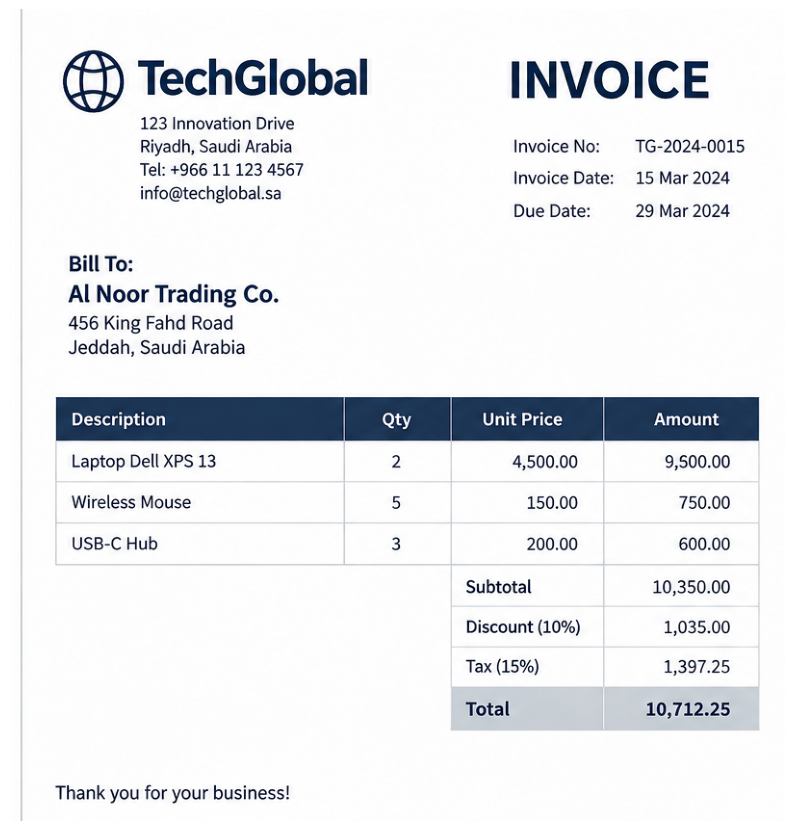

===== EXTRACTED DATA =====
{
  "invoice_date": "2025<s_invoice> 2025",
  "due_date": "2025",
  "vendor_name": "123 Innovation Drive",
  "vendor_address": "Riyadh, Saudi Arabia Tel: +966 11 123 4567 info@techglobal.sa"
}


In [ ]:
# Displays the invoice and converts the prediction into readable JSON.

import re,json
import matplotlib.pyplot as plt

plt.figure(figsize=(10,14))
plt.imshow(image)
plt.axis("off")
plt.show()

clean_prediction=prediction.replace(processor.tokenizer.eos_token,"")
clean_prediction=clean_prediction.replace(processor.tokenizer.pad_token,"")
clean_prediction=clean_prediction.replace("<s_invoice>","",1)

result=processor.token2json(clean_prediction)

print("===== EXTRACTED DATA =====")
print(json.dumps(result,indent=2,ensure_ascii=False))

#<font face="Georgia" color="#D8B4FE" size="6.9">A
</font>